# FCFF DCF Valuation — 해외기업(ADR) 전용판 v1

미국 노트북(FCFF_DCF_Valuation_v13.2)을 **준용**하여, 재무제표 통화 ≠ USD 인
해외기업(SONY·TSM 등)을 **환율(FX) 환산**으로 정확히 평가하는 전용 노트북입니다.

**구성**
- **PART 1** : 미국 노트북의 엔진(DCFModel)+패치(v13.1까지)를 그대로 적재 *(원본 동일)*
- **PART 1-F** : 해외 전용 모듈 — ① 강건 FX 엔진 ② 통화/국가 감지·매출통화 정합·FX Valuation·DB 저장
- **PART 2-F** : Control Panel + 해외 유니버스 빌더
- **PART 3-F** : 해외 단일 종목 테스트(환율 검증)
- **PART 4-F** : 해외 배치 + 랭킹 + 저장결과 조회

**핵심 원리** : 재무제표·매출예측을 *현지통화* 로 내부정합 DCF → 지분가치를 *FX 환산* →
**총액(USD) 기준 Upside** (= 지분가치_USD / 시가총액_USD − 1) 로 ADR 비율·주식수 불일치를 우회.

> ⚠ 실행 순서: PART 1 의 모든 셀을 위에서부터 실행한 뒤 PART 1-F → 2-F → 3-F → 4-F 순서로 진행하세요.

# ━━━━━━━━━━  PART 1 · 라이브러리 & 엔진 정의  ━━━━━━━━━━

**최초 1회만 실행**하면 됩니다. 경로·라이브러리·DB 연결·`DCFModel` 클래스·모든 패치(Excel/자본비용/TV/통화/클램프/해외FX)를 순서대로 정의합니다.

⚠ 이 파트의 셀들은 **위→아래 순서대로** 실행하세요(패치가 alias 로 누적 적용됨). 맨 마지막(4.13/4.14)까지 실행해야 v13.1 이 완성됩니다.

In [11]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root 자동 감지 : {root}")
            return root
    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "DATA")):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f"[PATH] root 후보 경로 : {candidate}")
            return candidate
    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다.\n"
        "_CANDIDATE_ROOTS 를 현재 환경에 맞게 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")

[PATH] root 자동 감지 : C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast
[확인] 프로젝트 루트 : C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast
[확인] DATA 경로    : C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA


In [12]:
# ── 표준 라이브러리 ──────────────────────────────────────────────
import gc, math, time, traceback, warnings
import requests
from datetime import datetime
from pathlib import Path
from typing import Optional, Dict, Any, List, Tuple

# ── 외부 라이브러리 ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

# ── 내부 모듈 ────────────────────────────────────────────────────
from DATA.config import get_db_info, get_engine
from DATA.us_target_ticker_list_2000 import ticker_list as US_TICKER_LIST
from DATA.universal_ts_forecast_function_v2 import (
    forecast_sarima, forecast_ets, forecast_theta,
    infer_freq_alias, seasonal_periods_from_freq, clear_memory,
)

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ══════════════════════════════════════════════════════════════════
#  설정 상수 — 여기만 수정하세요
# ══════════════════════════════════════════════════════════════════
FMP_API_KEY   = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"
FMP_BASE      = "https://financialmodelingprep.com/api/v3"
FMP_LIMIT     = 40          # 분기 수 (최대 조회)
FMP_SLEEP     = 0.35        # API 호출 간격 (초)

# DB 테이블
TABLE_SALES    = "us_revenue_forecast_data"   # Sales 예측 결과
TABLE_RE       = "us_rim_spread_data"         # Re_smooth
TABLE_RESULT   = "us_fcff_dcf_valuation"      # 저장 결과
DEFAULT_PORT   = 3307

# 모델 파라미터
FORECAST_HORIZON   = 8        # 예측 분기 수
MIN_HISTORY        = 20        # OPM 회귀 최소 분기 수
WINSORIZE_LIMITS   = (0.05, 0.95)
DISCOUNT_MODE      = "wacc"    # 'wacc' or 're'
GDP_GROWTH         = 0.04      # terminal growth 상한

# OLS fallback 기준
OLS_MIN_R2         = 0.30
OLS_MIN_SAMPLES    = 20

# (실행 제어 변수 — 측정일·배치범위·엑셀토글·클램프 — 는 PART 2 로 이동)

# ── DB 엔진 연결 ─────────────────────────────────────────────────
db_info = get_db_info()
engine  = get_engine(db_info)

print(f"[OK] Import 완료  |  대상 티커: {len(US_TICKER_LIST):,}개")
print(f"[설정] DISCOUNT_MODE={DISCOUNT_MODE}  FORECAST_HORIZON={FORECAST_HORIZON}  GDP_GROWTH={GDP_GROWTH}")


[OK] Import 완료  |  대상 티커: 2,000개
[설정] DISCOUNT_MODE=wacc  FORECAST_HORIZON=8  GDP_GROWTH=0.04


In [13]:
# ── DB 연결 함수 ────────────────────────────────────────────────
def get_conn():
    return pymysql.connect(
        host       = db_info["host"],
        port       = int(db_info.get("port", DEFAULT_PORT)),
        user       = db_info["user"],
        password   = db_info["password"],
        db         = db_info.get("database", "investar"),
        charset    = "utf8mb4",
        autocommit = False,
        cursorclass= pymysql.cursors.DictCursor,
    )

# ── 결과 테이블 생성 ─────────────────────────────────────────────
CREATE_SQL = """
CREATE TABLE IF NOT EXISTS `us_fcff_dcf_valuation` (
  `id`                BIGINT      NOT NULL AUTO_INCREMENT,
  `date`              DATE        NOT NULL COMMENT '예측 실행일',
  `ticker`            VARCHAR(20) NOT NULL,
  `quarter`           VARCHAR(10)          COMMENT 'e.g. 2026Q1',
  `sales_actual`      DOUBLE               COMMENT '과거 Sales',
  `sales_forecast`    DOUBLE               COMMENT '예측 Sales',
  `opm_forecast`      DOUBLE               COMMENT '예측 OPM',
  `ebit`              DOUBLE,
  `tax_rate`          DOUBLE,
  `nopat`             DOUBLE,
  `da`                DOUBLE,
  `capex`             DOUBLE,
  `nwc`               DOUBLE,
  `delta_nwc`         DOUBLE,
  `fcff`              DOUBLE,
  `roic`              DOUBLE,
  `reinvestment_rate` DOUBLE,
  `g_terminal`        DOUBLE,
  `discount_rate`     DOUBLE,
  `enterprise_value`  DOUBLE,
  `net_debt`          DOUBLE,
  `equity_value`      DOUBLE,
  `shares`            DOUBLE,
  `target_price`      DOUBLE,
  `current_price`     DOUBLE,
  `upside_pct`        DOUBLE,
  `created_at`        DATETIME    DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`, `quarter`),
  INDEX idx_ticker (`ticker`),
  INDEX idx_date   (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""

conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"테이블 준비 완료: {TABLE_RESULT}")
finally:
    conn.close()

# 연결 테스트
try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"연결 성공  host={db_info.get('host')}  port={db_info.get('port')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")


[11:41:15][DB] 테이블 준비 완료: us_fcff_dcf_valuation
[11:41:16][DB] 연결 성공  host=hystox74.synology.me  port=3307


In [14]:
# ═══════════════════════════════════════════════════════════════
#  DCFModel 클래스
# ═══════════════════════════════════════════════════════════════

class DCFModel:
    """
    Sales-driven FCFF DCF Valuation Model

    Parameters
    ----------
    ticker : str
    engine : SQLAlchemy engine  (Sales DB 조회용)
    fmp_api_key : str
    forecast_horizon : int      (예측 분기 수, default 12)
    min_history : int           (OPM 회귀 최소 관측치, default 16)
    discount_mode : str         'wacc' or 're'
    gdp_growth : float          terminal growth 상한 (default 0.04)
    verbose : bool              디버그 출력 여부
    """

    def __init__(
        self,
        ticker: str,
        engine,
        fmp_api_key: str = FMP_API_KEY,
        forecast_horizon: int = FORECAST_HORIZON,
        min_history: int = MIN_HISTORY,
        discount_mode: str = DISCOUNT_MODE,
        gdp_growth: float = GDP_GROWTH,
        verbose: bool = False,
    ):
        self.ticker           = ticker.upper()
        self.engine           = engine
        self.api_key          = fmp_api_key
        self.horizon          = forecast_horizon
        self.min_history      = min_history
        self.discount_mode    = discount_mode
        self.gdp_growth       = gdp_growth
        self.verbose          = verbose

        # 내부 저장소
        self._sales_actual:   Optional[pd.Series] = None
        self._sales_forecast: Optional[pd.Series] = None
        self._inc:            Optional[pd.DataFrame] = None
        self._bs:             Optional[pd.DataFrame] = None
        self._cf:             Optional[pd.DataFrame] = None
        self._fcff_history:   Optional[pd.Series] = None
        self.result_df:       Optional[pd.DataFrame] = None
        self.valuation:       Optional[Dict] = None

    # ─────────────────────────────────────────────────────────────
    # 1. 데이터 로드
    # ─────────────────────────────────────────────────────────────

    def load_sales(self) -> "DCFModel":
        """
        DB (us_revenue_forecast_data) 에서 Sales 로드.
        ★ cursor.execute → fetchall → pd.DataFrame 패턴 (pd.read_sql + pymysql 비호환 방지)
        ★ forecast_date 가 가장 최신인 행만 사용
        ★ forecast: model 우선순위 Ensemble → SARIMA → ETS → Theta
        """
        conn_local = get_conn()
        try:
            # ── actual: 각 date 의 가장 최신 forecast_date 행만 ────
            #   v12 변경: 같은 (ticker, date) 에 여러 forecast_date 의
            #   actual 행이 있을 때 (override 적용 전/후 등),
            #   비결정적 drop_duplicates 가 옛 값을 고를 위험 제거.
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT a.date, a.data_type, a.model, a.value "
                    f"FROM `{TABLE_SALES}` a "
                    f"INNER JOIN ( "
                    f"  SELECT date, MAX(forecast_date) AS max_fd "
                    f"  FROM `{TABLE_SALES}` "
                    f"  WHERE ticker=%s AND item='sale' AND data_type='actual' "
                    f"  GROUP BY date "
                    f") b ON a.date = b.date AND a.forecast_date = b.max_fd "
                    f"WHERE a.ticker=%s AND a.item='sale' AND a.data_type='actual' "
                    f"ORDER BY a.date",
                    (self.ticker, self.ticker)
                )
                actual_rows = cur.fetchall()

            # ── forecast: 가장 최신 forecast_date 의 행만 ──────────
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT MAX(forecast_date) AS max_fd "
                    f"FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='forecast'",
                    (self.ticker,)
                )
                row = cur.fetchone()
                max_fd = row["max_fd"] if row else None

            if max_fd is None:
                fc_rows = []
            else:
                with conn_local.cursor() as cur:
                    cur.execute(
                        f"SELECT date, data_type, model, value "
                        f"FROM `{TABLE_SALES}` "
                        f"WHERE ticker=%s AND item='sale' "
                        f"  AND data_type='forecast' "
                        f"  AND forecast_date=%s "
                        f"ORDER BY model, date",
                        (self.ticker, max_fd)
                    )
                    fc_rows = cur.fetchall()
        finally:
            conn_local.close()

        # ── actual 처리 ─────────────────────────────────────────────
        if not actual_rows:
            raise ValueError(f"[{self.ticker}] Sales actual 데이터 없음 — us_revenue_forecast_notebook 먼저 실행")

        act_df = pd.DataFrame(actual_rows)
        act_df["date"]  = pd.to_datetime(act_df["date"])
        act_df["value"] = pd.to_numeric(act_df["value"], errors="coerce")
        actual = (act_df.sort_values("date")
                        .drop_duplicates("date", keep="last")
                        .set_index("date")["value"])

        # ── forecast 처리 ──────────────────────────────────────────
        if not fc_rows:
            raise ValueError(
                f"[{self.ticker}] forecast Sales 없음 "
                f"(forecast_date={max_fd}) — us_revenue_forecast_notebook 먼저 실행"
            )

        fc_df = pd.DataFrame(fc_rows)
        fc_df["date"]  = pd.to_datetime(fc_df["date"])
        fc_df["value"] = pd.to_numeric(fc_df["value"], errors="coerce")

        if self.verbose:
            models_in_db = fc_df["model"].unique().tolist()
            log(self.ticker, f"forecast_date={max_fd}  models={models_in_db}")

        # 우선순위: Ensemble → SARIMA → ETS → Theta → 첫 번째 모델
        priority = ["Ensemble", "SARIMA", "ETS", "Theta"]
        available = fc_df["model"].unique().tolist()
        ordered   = [m for m in priority if m in available] +                     [m for m in available if m not in priority]

        forecast = pd.Series(dtype=float)
        used_model = None
        for model_name in ordered:
            fc = (fc_df[fc_df["model"] == model_name]
                  .sort_values("date")
                  .drop_duplicates("date", keep="last")
                  .set_index("date")["value"]
                  .dropna())
            if len(fc) >= self.horizon:
                forecast  = fc.iloc[:self.horizon]
                used_model = model_name
                break
            elif len(fc) > 0 and len(forecast) == 0:
                # 부족해도 일단 보관 (마지막 fallback)
                forecast   = fc
                used_model = model_name

        if forecast.empty:
            raise ValueError(
                f"[{self.ticker}] 예측 Sales 값이 모두 비어있음 "
                f"(forecast_date={max_fd})"
            )

        # horizon 부족 시 마지막 값으로 forward-fill
        if len(forecast) < self.horizon:
            extra_idx = pd.date_range(
                start=forecast.index[-1] + pd.offsets.QuarterEnd(1),
                periods=self.horizon - len(forecast),
                freq="QE"
            )
            fill_val  = float(forecast.iloc[-1])
            forecast  = pd.concat([
                forecast,
                pd.Series([fill_val] * len(extra_idx), index=extra_idx)
            ])
            if self.verbose:
                log(self.ticker, f"  forecast 부족({len(forecast)-len(extra_idx)}개) → 마지막값 forward-fill")

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:self.horizon]
        if self.verbose:
            log(self.ticker,
                f"Sales 로드 완료  actual={len(actual)}Q  "
                f"forecast={len(self._sales_forecast)}Q  "
                f"model={used_model}  forecast_date={max_fd}")
        return self

    def _fmp_get(self, endpoint: str, period: str = "quarter", limit: int = FMP_LIMIT) -> pd.DataFrame:
        """FMP API GET → DataFrame"""
        url = f"{FMP_BASE}/{endpoint}/{self.ticker}"
        for attempt in range(3):
            try:
                r = requests.get(url, params={"period": period, "limit": limit, "apikey": self.api_key}, timeout=20)
                if r.status_code == 429:
                    time.sleep(1.5 + attempt); continue
                r.raise_for_status()
                data = r.json()
                if isinstance(data, dict) and "Error Message" in data:
                    return pd.DataFrame()
                return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame()
            except Exception as e:
                if attempt == 2:
                    if self.verbose: log(self.ticker, f"FMP {endpoint} 실패: {e}")
                    return pd.DataFrame()
                time.sleep(FMP_SLEEP + attempt * 0.5)
        return pd.DataFrame()

    def _parse_date_col(self, df: pd.DataFrame) -> pd.DataFrame:
        """FMP date 컬럼 파싱 + 분기말 날짜로 통일 (acceptedDate 기반 look-ahead bias 보정)"""
        df = df.copy()
        df["report_date"] = pd.to_datetime(
            df.get("acceptedDate", df.get("fillingDate", pd.NaT)), errors="coerce"
        )
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        # look-ahead bias 보정: acceptedDate 있으면 report_date - 45일 → 회계분기말
        def _qend(row):
            if pd.notna(row.get("report_date")):
                return (row["report_date"] - pd.Timedelta(days=45)).to_period("Q").to_timestamp("Q")
            return row["date"].to_period("Q").to_timestamp("Q")
        df["date"] = df.apply(_qend, axis=1)
        df = df.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)
        return df

    def load_financials(self) -> "DCFModel":
        """FMP API → IS / BS / CF 분기 데이터 로드"""
        time.sleep(FMP_SLEEP)
        inc = self._fmp_get("income-statement")
        time.sleep(FMP_SLEEP)
        bs  = self._fmp_get("balance-sheet-statement")
        time.sleep(FMP_SLEEP)
        cf  = self._fmp_get("cash-flow-statement")

        if inc.empty or bs.empty or cf.empty:
            raise ValueError(f"[{self.ticker}] FMP 재무제표 로드 실패 (IS/BS/CF 중 하나 이상 비어있음)")

        self._inc = self._parse_date_col(inc)
        self._bs  = self._parse_date_col(bs)
        self._cf  = self._parse_date_col(cf)
        if self.verbose:
            log(self.ticker, f"IS={len(self._inc)}Q / BS={len(self._bs)}Q / CF={len(self._cf)}Q")

        # ── v8: FMP 필드 존재/품질 sanity check ───────────────────
        # v7 버그의 근본 원인: 필드명 오타 (currentAssets → totalCurrentAssets)가
        # silent하게 0으로 대체되어 γ가 크게 왜곡되었음. v8은 조기 경고로 방지.
        bs_critical = ["totalCurrentAssets", "totalCurrentLiabilities",
                       "cashAndCashEquivalents", "totalDebt"]
        for f in bs_critical:
            if f not in self._bs.columns:
                if self.verbose:
                    log(self.ticker, f"⚠️  BS에 필드 없음: {f}")
            elif pd.to_numeric(self._bs[f], errors="coerce").abs().sum() == 0:
                if self.verbose:
                    log(self.ticker, f"⚠️  BS 필드가 전부 0: {f}")
        return self

    # ─────────────────────────────────────────────────────────────
    # 2. 변수별 추정
    # ─────────────────────────────────────────────────────────────

    @staticmethod
    def _winsorize(s: pd.Series, limits=WINSORIZE_LIMITS) -> pd.Series:
        lo, hi = s.quantile(limits[0]), s.quantile(limits[1])
        return s.clip(lo, hi)

    @staticmethod
    def _ols_ratio(x: pd.Series, y: pd.Series) -> Tuple[float, float]:
        """y = slope*x 단순회귀. R² 반환"""
        mask = x.notna() & y.notna() & (x != 0)
        if mask.sum() < OLS_MIN_SAMPLES:
            return np.nan, -1.0
        slope, _, r, _, _ = stats.linregress(x[mask], y[mask])
        return slope, r ** 2

    def estimate_tax_rate(self) -> float:
        """실효세율 추정 (pretaxIncome > 0 분기만 사용, 범위 0~40%)"""
        inc = self._inc
        cols_needed = ["pretaxIncome", "incomeTaxExpense"]
        if not all(c in inc.columns for c in cols_needed):
            return 0.21  # 법정세율 fallback
        df = inc[cols_needed].apply(pd.to_numeric, errors="coerce")
        df = df[df["pretaxIncome"] > 0].dropna()
        if df.empty:
            return 0.21
        rates = (df["incomeTaxExpense"] / df["pretaxIncome"]).clip(0, 0.40)
        return float(rates.median())

    def estimate_opm(self, sales_series: pd.Series) -> pd.Series:
        """
        OPM 예측: SARIMA/ETS/Theta Ensemble
        fallback: best single → 최근 8분기 median → 전체 median
        과거 IS에서 OPM = operatingIncome / revenue 계산 후 예측
        """
        inc = self._inc
        if "operatingIncome" not in inc.columns or "revenue" not in inc.columns:
            fallback_opm = 0.10
            if self.verbose: log(self.ticker, "OPM: IS 컬럼 없음 → 10% fallback")
            return pd.Series([fallback_opm] * len(sales_series), index=sales_series.index)

        df = inc[["date","operatingIncome","revenue"]].copy()
        df["operatingIncome"] = pd.to_numeric(df["operatingIncome"], errors="coerce")
        df["revenue"]         = pd.to_numeric(df["revenue"], errors="coerce")
        df = df[(df["revenue"] > 0)].dropna().set_index("date").sort_index()
        df["opm"] = df["operatingIncome"] / df["revenue"]
        df["opm"] = self._winsorize(df["opm"])

        opm_series = df["opm"]
        if len(opm_series) < self.min_history:
            fallback = float(opm_series.median()) if not opm_series.empty else 0.10
            if self.verbose: log(self.ticker, f"OPM: 데이터 부족({len(opm_series)}) → median={fallback:.4f}")
            return pd.Series([fallback] * len(sales_series), index=sales_series.index)

        freq_alias = infer_freq_alias(opm_series.index)
        m = seasonal_periods_from_freq(freq_alias)

        forecasts = {}
        for name, fn in [("SARIMA", lambda y: forecast_sarima(y, self.horizon, seasonal_period=m)),
                         ("ETS",    lambda y: forecast_ets(y, self.horizon, m=m)),
                         ("Theta",  lambda y: forecast_theta(y, self.horizon, m=m))]:
            try:
                res = fn(opm_series)
                if "forecast" in res and "error" not in res:
                    forecasts[name] = np.asarray(res["forecast"])
            except Exception:
                pass

        if forecasts:
            ens = np.mean(list(forecasts.values()), axis=0)
            ens = np.clip(ens, -0.50, 0.80)  # OPM 범위 안정화
            return pd.Series(ens, index=sales_series.index)

        # Fallback: 최근 8분기 median → 전체 median
        fallback = float(opm_series.tail(8).median() if len(opm_series) >= 8
                         else opm_series.median())
        fallback = np.clip(fallback, -0.50, 0.80)
        if self.verbose: log(self.ticker, f"OPM: 예측 실패 → median fallback={fallback:.4f}")
        return pd.Series([fallback] * len(sales_series), index=sales_series.index)

    def estimate_ratio_coef(
        self, cf_col: str, ratio_name: str, take_abs: bool = False
    ) -> Tuple[float, str]:
        """
        D&A / CapEx / NWC 비율 계수 추정.
        OLS slope 우선 → R²<0.30 or 표본부족 or 음수 slope → median ratio fallback
        반환: (coef, method_used)
        """
        # Sales 매칭
        inc = self._inc[["date","revenue"]].copy()
        inc["revenue"] = pd.to_numeric(inc["revenue"], errors="coerce")

        # 데이터 소스 선택 (IS/BS/CF)
        if cf_col in self._cf.columns:
            src = self._cf[["date", cf_col]].copy()
        elif cf_col in self._inc.columns:
            src = self._inc[["date", cf_col]].copy()
        elif cf_col in self._bs.columns:
            src = self._bs[["date", cf_col]].copy()
        else:
            if self.verbose: log(self.ticker, f"{ratio_name}: 컬럼 없음 → 0 반환")
            return 0.0, "missing"

        src[cf_col] = pd.to_numeric(src[cf_col], errors="coerce")
        if take_abs:
            src[cf_col] = src[cf_col].abs()

        merged = inc.merge(src, on="date", how="inner").dropna()
        merged = merged[merged["revenue"] > 0]

        if merged.empty:
            return 0.0, "empty"

        x = merged["revenue"]
        y = merged[cf_col]

        slope, r2 = self._ols_ratio(x, y)

        use_ols = (
            not np.isnan(slope)
            and r2 >= OLS_MIN_R2
            and slope >= 0
            and len(merged) >= OLS_MIN_SAMPLES
        )

        if use_ols:
            if self.verbose: log(self.ticker, f"{ratio_name}: OLS slope={slope:.6f} R²={r2:.3f}")
            return float(slope), "ols"
        else:
            ratios = (y / x).replace([np.inf, -np.inf], np.nan).dropna()
            if ratios.empty:
                return 0.0, "ratio_empty"
            ratios = self._winsorize(ratios)
            med = float(ratios.median())
            if self.verbose: log(self.ticker, f"{ratio_name}: OLS 부적합(R²={r2:.3f}) → median ratio={med:.6f}")
            return max(med, 0.0), "median_ratio"

    # ─────────────────────────────────────────────────────────────
    # v8 변경: FMP 실제 필드명은 `totalCurrentAssets`. v7은 `currentAssets`로
    # 조회하여 KeyError 회피 로직(0으로 대체)에 의해 silent bug 발생.
    # → alias 매핑으로 정확 필드 우선 사용하고, 주요 필드 누락 시 경고 로그 출력.
    # 또한 마지막 실측 NWC(`_last_actual_nwc`)를 저장하여 compute_fcff의
    # ΔNWC 시드로 활용 (예측 1분기 FCFF 과대계상 방지).
    # ─────────────────────────────────────────────────────────────
    NWC_FIELD_ALIASES = {
        "totalCurrentAssets":      ["totalCurrentAssets", "currentAssets"],
        "cashAndCashEquivalents":  ["cashAndCashEquivalents", "cashAndShortTermInvestments"],
        "totalCurrentLiabilities": ["totalCurrentLiabilities"],
        "shortTermDebt":           ["shortTermDebt"],
    }

    def _compute_bs_nwc_series(self) -> pd.DataFrame:
        """BS에서 분기별 NWC 시계열 계산 (v8: alias 기반 정확 필드 매핑)."""
        bs = self._bs.copy()
        for std_name, aliases in self.NWC_FIELD_ALIASES.items():
            if std_name in bs.columns:
                continue
            matched = False
            for alias in aliases:
                if alias in bs.columns:
                    bs[std_name] = bs[alias]
                    matched = True
                    break
            if not matched:
                if self.verbose:
                    log(self.ticker, f"[NWC] 필드 없음 → 0 대체: {std_name}")
                bs[std_name] = 0.0
        for c in self.NWC_FIELD_ALIASES.keys():
            bs[c] = pd.to_numeric(bs[c], errors="coerce").fillna(0)

        bs["nwc"] = (
            (bs["totalCurrentAssets"] - bs["cashAndCashEquivalents"])
            - (bs["totalCurrentLiabilities"] - bs["shortTermDebt"])
        )
        return bs[["date", "nwc"]].sort_values("date").reset_index(drop=True)

    def estimate_nwc_coef(self) -> Tuple[float, str]:
        """
        NWC = (Total Current Assets - Cash) - (Total Current Liabilities - Short-term Debt)
        NWC/Sales 비율 OLS or median. 마지막 실측 NWC는 `_last_actual_nwc`에 저장.
        """
        nwc_df = self._compute_bs_nwc_series()

        # 마지막 실측 NWC 저장 (compute_fcff에서 ΔNWC 시드로 사용)
        self._last_actual_nwc = (float(nwc_df["nwc"].iloc[-1])
                                 if not nwc_df.empty else 0.0)

        inc = self._inc[["date", "revenue"]].copy()
        inc["revenue"] = pd.to_numeric(inc["revenue"], errors="coerce")
        merged = inc.merge(nwc_df, on="date", how="inner").dropna()
        merged = merged[merged["revenue"] > 0]

        if merged.empty:
            return 0.0, "empty"

        slope, r2 = self._ols_ratio(merged["revenue"], merged["nwc"])
        use_ols = (not np.isnan(slope) and r2 >= OLS_MIN_R2
                   and len(merged) >= OLS_MIN_SAMPLES)

        if use_ols:
            if self.verbose:
                log(self.ticker, f"NWC: OLS γ={slope:.4f} R²={r2:.3f}")
            return float(slope), "ols"
        else:
            ratios = (merged["nwc"] / merged["revenue"]).replace([np.inf, -np.inf], np.nan).dropna()
            if ratios.empty:
                return 0.0, "ratio_empty"
            gamma_med = float(self._winsorize(ratios).median())
            if self.verbose:
                log(self.ticker, f"NWC: OLS 부적합(R²={r2:.3f}) → median γ={gamma_med:.4f}")
            return gamma_med, "median_ratio"

    # ─────────────────────────────────────────────────────────────
    # 3. FCFF 계산
    # ─────────────────────────────────────────────────────────────

    def compute_fcff(self) -> "DCFModel":
        """Sales-driven FCFF = NOPAT + D&A - CapEx - ΔNWC"""
        sales_fc = self._sales_forecast
        tax      = self.estimate_tax_rate()
        opm_fc   = self.estimate_opm(sales_fc)

        alpha, _  = self.estimate_ratio_coef("depreciationAndAmortization", "D&A")
        beta, _   = self.estimate_ratio_coef("capitalExpenditure", "CapEx", take_abs=True)
        gamma, _  = self.estimate_nwc_coef()

        # ── v8: ΔNWC 시드값 설정 ───────────────────────────────────
        # v7은 prev_nwc=None으로 시작하여 첫 예측 분기의 ΔNWC가 0이 되었음
        # → 첫 분기 FCFF가 NOPAT+D&A-CapEx 만큼 과대계상되던 문제
        # v8: γ × 마지막 실제 매출 로 초기화하여 이론적 일관성 유지
        last_actual_sales = (float(self._sales_actual.iloc[-1])
                             if (self._sales_actual is not None
                                 and not self._sales_actual.empty)
                             else 0.0)
        prev_nwc = gamma * last_actual_sales

        # 실측 NWC와 괴리 체크 (γ 모델과 BS 실측값의 정합성 진단)
        if self.verbose and abs(last_actual_sales) > 0:
            actual_nwc = getattr(self, "_last_actual_nwc", None)
            if actual_nwc is not None and abs(prev_nwc) > 0:
                ratio_gap = abs(actual_nwc - prev_nwc) / max(abs(actual_nwc), 1)
                if ratio_gap > 0.5:
                    log(self.ticker,
                        f"[NWC seed] γ×sales={prev_nwc:,.0f} vs "
                        f"실측={actual_nwc:,.0f} 괴리 {ratio_gap:.1%}")

        rows = []
        for i, (dt, sales) in enumerate(sales_fc.items()):
            opm    = float(opm_fc.iloc[i])
            ebit   = sales * opm
            nopat  = ebit * (1 - tax)
            da     = alpha * sales
            capex  = beta  * sales
            nwc    = gamma * sales
            delta_nwc = nwc - prev_nwc
            prev_nwc = nwc

            fcff   = nopat + da - capex - delta_nwc
            # ROIC = NOPAT / (CapEx + ΔNWC)  (간략 추정)
            invested = capex + max(delta_nwc, 0)
            roic = nopat / invested if invested > 1e-6 else np.nan
            reinv = capex / nopat if nopat > 1e-6 else np.nan

            rows.append({
                "date":         dt,
                "quarter":      f"{dt.year}Q{dt.quarter}",
                "sales_forecast": sales,
                "opm_forecast": opm,
                "ebit":         ebit,
                "tax_rate":     tax,
                "nopat":        nopat,
                "da":           da,
                "capex":        capex,
                "nwc":          nwc,
                "delta_nwc":    delta_nwc,
                "fcff":         fcff,
                "roic":         roic,
                "reinvestment_rate": reinv,
            })

        self.result_df = pd.DataFrame(rows)

        # 역사적 FCFF (terminal growth CAGR 계산용)
        self._compute_historical_fcff(tax, alpha, beta, gamma)
        return self

    def _compute_historical_fcff(self, tax, alpha, beta, gamma):
        """과거 FCFF 시계열 계산 (terminal growth CAGR용)"""
        sales_act = self._sales_actual
        if sales_act is None or sales_act.empty:
            self._fcff_history = pd.Series(dtype=float)
            return

        inc = self._inc.set_index("date")
        rows = []
        # v8: 첫 분기 ΔNWC도 γ × 첫 sales 기준으로 초기화 (v7은 None이라 0이었음)
        first_sales = float(sales_act.iloc[0]) if not sales_act.empty else 0.0
        prev_nwc = gamma * first_sales
        for dt, sales in sales_act.items():
            opm_row = inc["operatingIncome"].get(dt, np.nan) if "operatingIncome" in inc.columns else np.nan
            rev_row = inc["revenue"].get(dt, np.nan) if "revenue" in inc.columns else np.nan
            opm = (float(opm_row) / float(rev_row)) if (pd.notna(opm_row) and pd.notna(rev_row) and float(rev_row) > 0) else np.nan
            if pd.isna(opm):
                prev_nwc = gamma * sales; continue
            ebit  = sales * opm
            nopat = ebit * (1 - tax)
            da    = alpha * sales
            capex = beta  * sales
            nwc   = gamma * sales
            dnwc  = nwc - prev_nwc
            prev_nwc = nwc
            rows.append({"date": dt, "fcff": nopat + da - capex - dnwc})

        if rows:
            df_h = pd.DataFrame(rows).set_index("date")["fcff"]
            self._fcff_history = df_h
        else:
            self._fcff_history = pd.Series(dtype=float)

    # ─────────────────────────────────────────────────────────────
    # 4. WACC 계산
    # ─────────────────────────────────────────────────────────────

    def _get_re_smooth(self) -> Optional[float]:
        """DB us_rim_spread_data 에서 최신 Re_smooth 조회"""
        sql = text(f"""
            SELECT value FROM `{TABLE_RE}`
            WHERE ticker=:t AND indicator='Re_smooth'
            ORDER BY date DESC LIMIT 1
        """)
        try:
            with self.engine.connect() as conn:
                row = conn.execute(sql, {"t": self.ticker}).fetchone()
            if row:
                return float(row[0])
        except Exception:
            pass
        return None

    def compute_wacc(self) -> float:
        """WACC = Re×E/V + Rd×(1-tax)×D/V"""
        tax = self.estimate_tax_rate()
        re  = self._get_re_smooth()
        if re is None:
            # fallback: CAPM 대략값 (rf 4.5% + β1.0 × ERP 5.5%)
            re = 0.045 + 1.0 * 0.055
            if self.verbose: log(self.ticker, f"Re_smooth 없음 → CAPM fallback Re={re:.4f}")

        if self.discount_mode == "re":
            if self.verbose: log(self.ticker, f"discount_mode=re → WACC={re:.4f}")
            return float(re)

        # 부채 비용
        bs  = self._bs
        inc = self._inc
        rd  = 0.05  # 기본값

        if "totalDebt" in bs.columns and "interestExpense" in inc.columns:
            latest_bs  = bs.sort_values("date").iloc[-1]
            total_debt = pd.to_numeric(latest_bs.get("totalDebt", 0), errors="coerce") or 0

            ie = pd.to_numeric(inc["interestExpense"], errors="coerce").abs()
            total_debt_avg = pd.to_numeric(bs["totalDebt"], errors="coerce")
            total_debt_avg = (total_debt_avg + total_debt_avg.shift(1)) / 2

            valid = (total_debt_avg > 0) & ie.notna()
            if valid.sum() >= 2:
                rd_series = (ie[valid] / total_debt_avg[valid]).clip(0, 0.15)
                rd = float(rd_series.median())

            # 시가총액 (최신)
            mkt_cap = 0.0
            try:
                r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                                  params={"apikey": self.api_key}, timeout=10)
                data = r.json()
                if isinstance(data, list) and data:
                    mkt_cap = float(data[0].get("marketCap", 0) or 0)
            except Exception:
                pass

            V = mkt_cap + total_debt
            if V > 1e6:
                we = mkt_cap / V
                wd = total_debt / V
                wacc = re * we + rd * (1 - tax) * wd
                wacc = float(np.clip(wacc, 0.04, 0.25))
                if self.verbose: log(self.ticker, f"WACC={wacc:.4f}  Re={re:.4f} Rd={rd:.4f} tax={tax:.4f}")
                return wacc

        if self.verbose: log(self.ticker, f"WACC 계산 불완전 → Re fallback={re:.4f}")
        return float(re)

    # ─────────────────────────────────────────────────────────────
    # 5. Terminal Growth
    # ─────────────────────────────────────────────────────────────

    def _compute_eva_spread(self, wacc: float) -> dict:
        """
        EVA spread = ROIC_TTM - WACC 계산
        ─────────────────────────────────────────────────────────────
        ROIC = NOPAT_TTM / Invested_Capital
        NOPAT_TTM  = trailing 4분기 operatingIncome × (1 - tax_rate)
                     (분기 계절성 제거를 위해 반드시 TTM 사용)
        IC         = totalStockholdersEquity + totalDebt - cash  [분기말]
        ─────────────────────────────────────────────────────────────
        반환 dict:
          roic        : float  TTM ROIC
          eva_spread  : float  ROIC - WACC
          ic          : float  Invested Capital (최신 분기)
          n_positive  : int    EVA > 0 유지 분기 수 (최근 20분기 기준)
          eva_series  : list   분기별 EVA spread 시계열
        """
        inc = self._inc.copy()
        bs  = self._bs.copy()

        # ── NOPAT TTM 계산 ─────────────────────────────────────────
        tax   = self.estimate_tax_rate()
        if "operatingIncome" not in inc.columns:
            return {"roic": np.nan, "eva_spread": np.nan,
                    "ic": np.nan, "n_positive": 0, "eva_series": []}

        inc["nopat_q"] = (
            pd.to_numeric(inc["operatingIncome"], errors="coerce") * (1 - tax)
        )
        inc = inc.set_index("date").sort_index()

        # ── Invested Capital (분기말 스냅샷) ──────────────────────
        for col in ["totalStockholdersEquity", "totalDebt", "cashAndCashEquivalents"]:
            bs[col] = pd.to_numeric(bs.get(col, 0), errors="coerce").fillna(0)
        bs["ic"] = (
            bs["totalStockholdersEquity"]
            + bs["totalDebt"]
            - bs["cashAndCashEquivalents"]
        )
        bs = bs.set_index("date")[["ic"]].sort_index()

        # ── 분기별 ROIC & EVA spread 시계열 ──────────────────────
        merged = bs.join(inc[["nopat_q"]], how="inner").dropna()
        if len(merged) < 4:
            return {"roic": np.nan, "eva_spread": np.nan,
                    "ic": np.nan, "n_positive": 0, "eva_series": []}

        eva_series = []
        dates      = sorted(merged.index)
        for i, dt in enumerate(dates):
            if i < 3:
                continue   # TTM 위해 최소 4개 분기 필요
            # TTM NOPAT = 해당 분기 포함 직전 4분기 합산
            nopat_ttm = float(merged["nopat_q"].iloc[i-3:i+1].sum())
            ic_snap   = float(merged["ic"].iloc[i])
            if ic_snap <= 0:
                continue
            roic_q = nopat_ttm / ic_snap
            eva_q  = roic_q - wacc
            eva_series.append({"date": dt, "roic": roic_q,
                               "eva_spread": eva_q, "ic": ic_snap})

        if not eva_series:
            return {"roic": np.nan, "eva_spread": np.nan,
                    "ic": np.nan, "n_positive": 0, "eva_series": []}

        latest       = eva_series[-1]
        recent_20    = eva_series[-20:]
        n_positive   = sum(1 for e in recent_20 if e["eva_spread"] > 0)

        if self.verbose:
            log(self.ticker,
                f"EVA: ROIC={latest['roic']:.2%}  WACC={wacc:.2%}  "
                f"spread={latest['eva_spread']:+.2%}  "
                f"n_pos(20Q)={n_positive}/20")
        return {
            "roic":       latest["roic"],
            "eva_spread": latest["eva_spread"],
            "ic":         latest["ic"],
            "n_positive": n_positive,
            "eva_series": eva_series,
        }

    def _moat_to_rho_and_years(self, eva: dict) -> tuple:
        """
        EVA spread → (ρ, Phase2 기간) 결정
        ─────────────────────────────────────────────────────────────
        학술 근거
          Mauboussin & Johnson (1997) FAJ
            "Competitive Advantage Period" 개념 — 초과수익 지속 기간
            탁월 기업 15~20년, 평균 기업 5~10년
          Damodaran (2002) "Investment Valuation" Ch.12
            extraordinary growth 기업 Phase2 최대 10~15년 실무 권고
          Chan, Karceski, Lakonishok (2003) JF
            S&P500 실증: 상위 10% 성장 기업 중 5년 유지 ~10%, 10년 ~2%
          Wiggins & Ruefli (2002) SMJ
            지속적 경쟁우위(SCA) 평균 지속 기간 약 10년
          Ohlson (1995) / Feltham-Ohlson
            RI(t) = ω·RI(t-1) + ε  →  ω ≡ ρ (지속성 계수)
            EVA spread ≈ Residual Income 의 근사값

        등급 기준 (EVA spread 수준 + 지속성):
          Wide moat  : spread > 15% AND 최근 20Q 중 15Q 이상 양수
                       ρ=0.90  Phase2=15년  (수렴 ~25년 — 학술 최대)
          Narrow moat: spread  8~15% AND 12Q+ 양수
                       ρ=0.83  Phase2=12년  (수렴 ~14년)
          Some moat  : spread  3~8%  AND  8Q+ 양수
                       ρ=0.75  Phase2= 8년  (수렴  ~9년)
          No moat    : spread < 3%  OR   < 8Q 양수
                       ρ=0.60  Phase2= 5년  (수렴  ~6년)
        ─────────────────────────────────────────────────────────────
        반환: (rho, n_phase2_years, moat_label)
        """
        if np.isnan(eva.get("eva_spread", np.nan)):
            # EVA 계산 불가 → 보수적 중간값
            return 0.75, 8, "Unknown (fallback)"

        spread    = eva["eva_spread"]
        n_pos     = eva["n_positive"]

        if spread > 0.15 and n_pos >= 15:
            rho, yrs, label = 0.90, 15, "Wide moat"
        elif spread > 0.08 and n_pos >= 12:
            rho, yrs, label = 0.83, 12, "Narrow moat"
        elif spread > 0.03 and n_pos >= 8:
            rho, yrs, label = 0.75,  8, "Some moat"
        else:
            rho, yrs, label = 0.60,  5, "No moat"

        if self.verbose:
            log(self.ticker,
                f"Moat: [{label}]  spread={spread:+.2%}  n_pos={n_pos}/20  "
                f"→ ρ={rho}  Phase2={yrs}yr")
        return rho, yrs, label

    def _estimate_phase2_growth(self, wacc: float) -> tuple:
        """
        Phase 2 AR(1) 성장 경로 생성
        ─────────────────────────────────────────────────────────────
        1) EVA spread 계산 → 해자 등급 판별
        2) 해자 등급 → (ρ, Phase2 기간) 결정
        3) AR(1): g(t) = g_term + (g(t-1) - g_term) × ρ

        근거:
          3-Stage 구조  — Damodaran (2002) "Investment Valuation"
                          Phase 구분 방식·기간 권고 인용
                          ※ Damodaran 원전의 Phase2 감속 함수는 선형 보간
                            (g_high → g_n 직선). 본 코드는 AR(1)으로 대체.
          AR(1) 감속    — Fama & French (1995) JF
                          수익성(ROE/ROIC)의 평균 회귀 실증 근거
                          수식 형태: Ohlson (1995) / Feltham-Ohlson 잉여이익
                          지속성 계수 ω와 ρ가 수학적으로 동치
          해자→기간 매핑 — Mauboussin & Johnson (1997) FAJ  CAP 프레임
                           Chan, Karceski, Lakonishok (2003) JF 실증
                           Wiggins & Ruefli (2002) 지속적 경쟁우위 연구
        ─────────────────────────────────────────────────────────────
        반환: (g_path, moat_label, rho, n_years)
          g_path     : list[float]  연간 성장률 (Phase2 기간만큼)
          moat_label : str
          rho        : float
          n_years    : int
        """
        G_TERM = self.gdp_growth

        # ── 현재 성장률 g_0 추정 ──────────────────────────────────
        h  = self._fcff_history
        g0 = None
        if h is not None and len(h.dropna()) >= 8:
            h_c = h.dropna()
            f0, fl = float(h_c.iloc[-8]), float(h_c.iloc[-1])
            if f0 > 0 and fl > 0:
                cagr_q = (fl / f0) ** (4.0 / 8) - 1
                g0 = float(np.clip((1 + cagr_q) ** 4 - 1, G_TERM, 0.80))
        if g0 is None:
            fcff_q = self.result_df["fcff"].values
            yr1 = float(np.sum(fcff_q[:4]))
            yr2 = float(np.sum(fcff_q[4:8])) if len(fcff_q) >= 8 else yr1
            g0  = float(np.clip(yr2 / yr1 - 1, G_TERM, 0.80)) if yr1 > 0 else 0.10

        # ── EVA → 해자 등급 → (ρ, 기간) ──────────────────────────
        eva  = self._compute_eva_spread(wacc)
        rho, n_years, moat_label = self._moat_to_rho_and_years(eva)

        # ── ρ OLS 추정으로 보정 (데이터 충분 시) ─────────────────
        if h is not None and len(h.dropna()) >= 12:
            h_c = h.dropna()
            annual_vals = [float(h_c.iloc[y:y+4].sum())
                           for y in range(0, len(h_c) - len(h_c) % 4, 4)]
            if len(annual_vals) >= 4:
                g_hist = [(annual_vals[i]/annual_vals[i-1] - 1)
                          for i in range(1, len(annual_vals))
                          if annual_vals[i-1] > 0 and annual_vals[i] > 0]
                if len(g_hist) >= 3:
                    yt = np.array([g - G_TERM for g in g_hist[1:]])
                    xt = np.array([g - G_TERM for g in g_hist[:-1]])
                    if np.dot(xt, xt) > 1e-10:
                        rho_ols = float(np.clip(
                            np.dot(xt, yt) / np.dot(xt, xt),
                            0.40, 0.92
                        ))
                        # EVA 기반 ρ와 OLS ρ의 가중 평균 (각 50%)
                        rho = float(np.clip(0.5 * rho + 0.5 * rho_ols, 0.40, 0.92))
                        if self.verbose:
                            log(self.ticker,
                                f"ρ 보정: EVA기반={rho:.3f}  OLS={rho_ols:.3f}  "
                                f"→ 혼합={rho:.3f}")

        # ── AR(1) 성장 경로 생성 ──────────────────────────────────
        g = g0
        g_path = []
        for _ in range(n_years):
            g = G_TERM + (g - G_TERM) * rho
            g_path.append(float(np.clip(g, G_TERM, 0.80)))

        if self.verbose:
            log(self.ticker,
                f"Phase2 [{moat_label}] ρ={rho:.3f} {n_years}년  "
                f"g0={g0:.1%} → {g_path[0]:.1%} ... {g_path[-1]:.1%}")

        # EVA 정보를 valuation 딕셔너리에 저장하기 위해 임시 보관
        self._eva_cache = {
            "eva_spread":  eva.get("eva_spread", np.nan),
            "roic":        eva.get("roic",        np.nan),
            "n_positive":  eva.get("n_positive",  0),
            "moat_label":  moat_label,
            "rho":         rho,
            "n_phase2":    n_years,
            "eva_series":  eva.get("eva_series",  []),
        }
        return g_path, moat_label, rho, n_years


    def compute_terminal_growth(self, reinvestment_rate: float, wacc: float) -> float:
        """
        Terminal growth rate (Phase 3 이후)
        g = min(GDP_growth, 0.5*FCFF_CAGR + 0.5*(ROIC*reinv))
        g ∈ [0, GDP_growth]
        ─ Phase 2 에서 이미 고성장→수렴을 처리했으므로
          여기서는 보수적 장기 성장률만 산출
        """
        fcff_cagr = 0.0
        h = self._fcff_history
        if h is not None and len(h) >= 4:
            h20 = h.dropna().tail(20)
            f0, fl = float(h20.iloc[0]), float(h20.iloc[-1])
            n = len(h20)
            if f0 > 0 and fl > 0 and n >= 4:
                fcff_cagr = (fl / f0) ** (4.0 / n) - 1.0
                fcff_cagr = float(np.clip(fcff_cagr, -0.10, 0.20))

        df_hist = self.result_df
        roic_vals = df_hist["roic"].dropna()
        roic_med  = float(roic_vals.median()) if not roic_vals.empty else 0.08
        g_roic    = roic_med * reinvestment_rate

        g = 0.5 * fcff_cagr + 0.5 * g_roic
        g = float(np.clip(g, 0.0, self.gdp_growth))

        if self.verbose:
            log(self.ticker,
                f"g_terminal={g:.4f}  FCFF_CAGR={fcff_cagr:.4f}  g_roic={g_roic:.4f}")
        return g

    # ─────────────────────────────────────────────────────────────
    # 6. Valuation — 3-Stage DCF
    # ─────────────────────────────────────────────────────────────

    def compute_valuation(self) -> "DCFModel":
        """
        3-Stage DCF Valuation
        ─────────────────────────────────────────────────────────────
        Phase 1 (Year 1-2) : DB 예측 FCFF → 분기 합산 연간화
        Phase 2 (Year 3-7) : 중간 성장 수렴 (_estimate_phase2_growth)
                             방법A(분석가) → B(CAGR감속) → C(ROIC fallback)
        Phase 3 (Year 8~)  : Terminal Value (g_terminal, 보수적)
        할인 기준           : 연간 WACC (연간 FCFF에 적용)
        ─────────────────────────────────────────────────────────────
        """
        wacc = self.compute_wacc()
        df   = self.result_df.copy()

        # ── reinvestment_rate median ──────────────────────────────
        pos = df[df["nopat"] > 0]["reinvestment_rate"].dropna()
        reinv_med = float(self._winsorize(pos).median()) if not pos.empty else 0.3

        # ── Phase 1: 분기 FCFF → 연간 합산 ────────────────────────
        fcff_q   = df["fcff"].values
        n_q      = len(fcff_q)
        ph1_annual = []
        for yr in range(0, n_q, 4):
            ph1_annual.append(float(np.sum(fcff_q[yr: yr + 4])))
        ph1_annual = np.array(ph1_annual)   # shape: (2,)  Year 1-2
        T_ph1 = len(ph1_annual)

        # ── Phase 2: 중간 성장 (Year 3-7) ─────────────────────────
        _ph2_result  = self._estimate_phase2_growth(wacc)
        ph2_growth, _moat_lbl, _rho, _n_ph2 = _ph2_result
        ph2_annual = []
        last_fcff  = float(ph1_annual[-1])
        for g_ph2 in ph2_growth:
            last_fcff = last_fcff * (1 + g_ph2)
            ph2_annual.append(last_fcff)
        ph2_annual = np.array(ph2_annual)   # shape: (5,)  Year 3-7

        # ── Phase 3: Terminal Value ────────────────────────────────
        g_terminal = self.compute_terminal_growth(reinv_med, wacc)
        # TV 분모 안정성
        if wacc - g_terminal < 0.01:
            g_terminal = wacc - 0.01

        fcff_last_annual = float(ph2_annual[-1])
        tv    = fcff_last_annual * (1 + g_terminal) / (wacc - g_terminal)

        # ── PV 계산 (연간 WACC, 연도별 할인) ──────────────────────
        all_annual = np.concatenate([ph1_annual, ph2_annual])
        T_total    = len(all_annual)

        pv_fcff = float(sum(
            all_annual[t] / (1 + wacc) ** (t + 1)
            for t in range(T_total)
        ))
        pv_tv = tv / (1 + wacc) ** T_total

        ev = pv_fcff + pv_tv

        # ── Net Debt ───────────────────────────────────────────────
        net_debt = 0.0
        if not self._bs.empty:
            latest = self._bs.sort_values("date").iloc[-1]
            td   = pd.to_numeric(latest.get("totalDebt", 0),   errors="coerce") or 0
            cash = pd.to_numeric(latest.get("cashAndCashEquivalents", 0), errors="coerce") or 0
            net_debt = float(td - cash)

        equity_val = ev - net_debt

        # ── Shares ─────────────────────────────────────────────────
        shares = np.nan
        if "weightedAverageShsOutDil" in self._inc.columns:
            s = pd.to_numeric(self._inc["weightedAverageShsOutDil"].iloc[-1], errors="coerce")
            if pd.notna(s) and s > 0:
                shares = float(s)
        if np.isnan(shares) and "weightedAverageShsOut" in self._inc.columns:
            s = pd.to_numeric(self._inc["weightedAverageShsOut"].iloc[-1], errors="coerce")
            if pd.notna(s) and s > 0:
                shares = float(s)

        target_price = equity_val / shares if (not np.isnan(shares) and shares > 0) else np.nan

        # ── 현재 주가 ──────────────────────────────────────────────
        current_price = np.nan
        try:
            r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                             params={"apikey": self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                current_price = float(data[0].get("price", np.nan) or np.nan)
        except Exception:
            pass

        upside = (
            ((target_price / current_price) - 1) * 100
            if (not np.isnan(target_price) and not np.isnan(current_price)
                and current_price > 0)
            else np.nan
        )

        tv_weight = pv_tv / ev * 100 if ev != 0 else np.nan

        self.valuation = {
            "ticker":             self.ticker,
            "wacc":               wacc,
            "g_terminal":         g_terminal,
            "reinvestment_rate":  reinv_med,
            "pv_fcff":            pv_fcff,
            "terminal_value":     tv,
            "pv_tv":              pv_tv,
            "tv_weight_pct":      tv_weight,
            "enterprise_value":   ev,
            "net_debt":           net_debt,
            "equity_value":       equity_val,
            "shares":             shares,
            "target_price":       target_price,
            "current_price":      current_price,
            "upside_pct":         upside,
            # 단계별 진단용
            "ph1_annual":         ph1_annual.tolist(),
            "ph2_annual":         ph2_annual.tolist(),
            "ph2_growth":         ph2_growth,
            "all_annual":         all_annual.tolist(),
            "t_total":            T_total,
            "fcff_last_annual":   fcff_last_annual,
            # 구버전 호환 키
            "annual_fcff":        all_annual.tolist(),
            # EVA / Moat 정보
            "moat_label":         getattr(self, "_eva_cache", {}).get("moat_label", "N/A"),
            "eva_spread":         getattr(self, "_eva_cache", {}).get("eva_spread", np.nan),
            "roic":               getattr(self, "_eva_cache", {}).get("roic", np.nan),
            "moat_rho":           getattr(self, "_eva_cache", {}).get("rho", np.nan),
            "n_phase2":           getattr(self, "_eva_cache", {}).get("n_phase2", 0),
            "eva_series":         getattr(self, "_eva_cache", {}).get("eva_series", []),
            "t_years":            T_total,
        }

        if self.verbose:
            log(self.ticker,
                f"3-Stage DCF  "
                f"Ph1={T_ph1}yr Ph2={len(ph2_annual)}yr TV  |  "
                f"EV=${ev/1e9:.2f}B  TP=${target_price:.2f}  "
                f"Upside={upside:.1f}%  TV비중={tv_weight:.1f}%")
        return self


    # ─────────────────────────────────────────────────────────────
    # 7. DB 저장
    # ─────────────────────────────────────────────────────────────

    def save_to_db(self, run_date: str = None) -> int:
        """result_df + valuation → us_fcff_dcf_valuation 저장"""
        if self.result_df is None or self.valuation is None:
            return 0
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v = self.valuation
        df = self.result_df.copy()

        rows = []
        for _, row in df.iterrows():
            rows.append({
                "date":             run_date,
                "ticker":           self.ticker,
                "quarter":          row.get("quarter"),
                "sales_forecast":   row.get("sales_forecast"),
                "opm_forecast":     row.get("opm_forecast"),
                "ebit":             row.get("ebit"),
                "tax_rate":         row.get("tax_rate"),
                "nopat":            row.get("nopat"),
                "da":               row.get("da"),
                "capex":            row.get("capex"),
                "nwc":              row.get("nwc"),
                "delta_nwc":        row.get("delta_nwc"),
                "fcff":             row.get("fcff"),
                "roic":             row.get("roic"),
                "reinvestment_rate":v["reinvestment_rate"],
                "g_terminal":       v["g_terminal"],
                "discount_rate":    v["wacc"],
                "enterprise_value": v["enterprise_value"],
                "net_debt":         v["net_debt"],
                "equity_value":     v["equity_value"],
                "shares":           v["shares"],
                "target_price":     v["target_price"],
                "current_price":    v["current_price"],
                "upside_pct":       v["upside_pct"],
            })

        save_df = pd.DataFrame(rows)
        # NaN → None 변환
        save_df = save_df.where(pd.notnull(save_df), None)

        sql = f"""
            INSERT INTO `{TABLE_RESULT}`
            (date, ticker, quarter, sales_forecast, opm_forecast, ebit, tax_rate,
             nopat, da, capex, nwc, delta_nwc, fcff, roic, reinvestment_rate,
             g_terminal, discount_rate, enterprise_value, net_debt, equity_value,
             shares, target_price, current_price, upside_pct)
            VALUES
            (%(date)s, %(ticker)s, %(quarter)s, %(sales_forecast)s, %(opm_forecast)s,
             %(ebit)s, %(tax_rate)s, %(nopat)s, %(da)s, %(capex)s, %(nwc)s,
             %(delta_nwc)s, %(fcff)s, %(roic)s, %(reinvestment_rate)s,
             %(g_terminal)s, %(discount_rate)s, %(enterprise_value)s, %(net_debt)s,
             %(equity_value)s, %(shares)s, %(target_price)s, %(current_price)s,
             %(upside_pct)s)
            ON DUPLICATE KEY UPDATE
                fcff=VALUES(fcff), target_price=VALUES(target_price),
                upside_pct=VALUES(upside_pct), enterprise_value=VALUES(enterprise_value)
        """
        conn = get_conn()
        try:
            with conn.cursor() as cur:
                cur.executemany(sql, save_df.to_dict("records"))
            conn.commit()
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()
        return len(rows)

    # ─────────────────────────────────────────────────────────────
    # 8. 시각화
    # ─────────────────────────────────────────────────────────────

    def plot(self) -> None:
        """과거 FCFF(실선) + 예측 FCFF(막대) 연속 시각화 + 밸류에이션 요약"""
        if self.result_df is None:
            print("[WARN] result_df 없음 — compute_fcff() 먼저 실행하세요")
            return

        df  = self.result_df.copy()
        v   = self.valuation or {}
        h   = self._fcff_history  # 과거 FCFF (pd.Series, index=date)

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f"{self.ticker}  FCFF DCF Valuation", fontsize=14, fontweight="bold")

        # ── ① 과거+예측 FCFF 연속 차트 ──────────────────────────────
        ax = axes[0, 0]

        # 과거 FCFF (최근 16분기)
        if h is not None and not h.empty:
            h_plot = h.dropna().tail(16).copy()
            h_labels = [f"{d.year}Q{d.quarter}" for d in h_plot.index]
            ax.bar(
                range(len(h_plot)),
                h_plot.values / 1e9,
                color=["#2980b9" if v_ >= 0 else "#c0392b" for v_ in h_plot.values],
                alpha=0.75,
                label="Historical FCFF",
                edgecolor="white",
            )
            # 구분선
            split_x = len(h_plot) - 0.5
            ax.axvline(split_x, color="gray", lw=1.2, ls="--", label="Forecast start")
            xtick_pos  = list(range(len(h_plot)))
            xtick_labs = h_labels
            offset = len(h_plot)
        else:
            split_x    = -0.5
            xtick_pos  = []
            xtick_labs = []
            offset     = 0

        # 예측 FCFF
        fc_colors = ["#27ae60" if f >= 0 else "#e74c3c" for f in df["fcff"]]
        ax.bar(
            range(offset, offset + len(df)),
            df["fcff"].values / 1e9,
            color=fc_colors,
            alpha=0.90,
            label="Forecast FCFF",
            edgecolor="white",
        )
        xtick_pos  += list(range(offset, offset + len(df)))
        xtick_labs += df["quarter"].tolist()

        ax.axhline(0, color="black", lw=0.8)
        ax.set_xticks(xtick_pos)
        ax.set_xticklabels(xtick_labs, rotation=45, ha="right", fontsize=7)
        ax.set_title("Historical & Forecast FCFF (B$)")
        ax.set_ylabel("USD Billion")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

        # ── ② 과거 Sales(실선) + 예측 Sales·EBIT(막대) ──────────────
        ax = axes[0, 1]
        act_sales = self._sales_actual
        if act_sales is not None and not act_sales.empty:
            act_plot   = act_sales.tail(16)
            act_labels = [f"{d.year}Q{d.quarter}" for d in act_plot.index]
            ax.plot(
                range(len(act_plot)),
                act_plot.values / 1e9,
                marker="o", ms=3, lw=1.5,
                color="#2980b9", label="Actual Sales", zorder=3,
            )
            ax.axvline(len(act_plot) - 0.5, color="gray", lw=1.2, ls="--")
            s_offset  = len(act_plot)
            s_xticks  = list(range(len(act_plot)))
            s_xlabels = act_labels
        else:
            s_offset  = 0
            s_xticks  = []
            s_xlabels = []

        ax.bar(
            range(s_offset, s_offset + len(df)),
            df["sales_forecast"].values / 1e9,
            alpha=0.45, label="Forecast Sales", color="#3498db",
        )
        ax.bar(
            range(s_offset, s_offset + len(df)),
            df["ebit"].values / 1e9,
            alpha=0.70, label="Forecast EBIT", color="#e67e22",
        )
        s_xticks  += list(range(s_offset, s_offset + len(df)))
        s_xlabels += df["quarter"].tolist()
        ax.set_xticks(s_xticks)
        ax.set_xticklabels(s_xlabels, rotation=45, ha="right", fontsize=7)
        ax.set_title("Actual Sales → Forecast Sales & EBIT (B$)")
        ax.set_ylabel("USD Billion")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

        # ── ③ 과거 OPM(실선) + 예측 OPM(점선) ──────────────────────
        ax = axes[1, 0]
        if self._inc is not None and "operatingIncome" in self._inc.columns:
            inc_tmp = self._inc.copy()
            inc_tmp["opm_hist"] = (
                pd.to_numeric(inc_tmp["operatingIncome"], errors="coerce")
                / pd.to_numeric(inc_tmp["revenue"], errors="coerce")
            )
            opm_hist = inc_tmp.set_index("date")["opm_hist"].dropna().tail(16)
            ax.plot(
                range(len(opm_hist)),
                opm_hist.values * 100,
                marker="o", ms=3, lw=1.5,
                color="purple", label="Historical OPM",
            )
            ax.axvline(len(opm_hist) - 0.5, color="gray", lw=1.2, ls="--")
            o_offset  = len(opm_hist)
            o_xticks  = list(range(len(opm_hist)))
            o_xlabels = [f"{d.year}Q{d.quarter}" for d in opm_hist.index]
        else:
            o_offset  = 0
            o_xticks  = []
            o_xlabels = []

        ax.plot(
            range(o_offset, o_offset + len(df)),
            df["opm_forecast"].values * 100,
            marker="s", ms=3, lw=1.5, ls="--",
            color="#8e44ad", label="Forecast OPM",
        )
        o_xticks  += list(range(o_offset, o_offset + len(df)))
        o_xlabels += df["quarter"].tolist()
        ax.set_xticks(o_xticks)
        ax.set_xticklabels(o_xlabels, rotation=45, ha="right", fontsize=7)
        ax.axhline(0, color="black", lw=0.8)
        ax.set_title("Historical & Forecast OPM (%)")
        ax.set_ylabel("%")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # ── ④ 밸류에이션 요약 ────────────────────────────────────────
        ax = axes[1, 1]
        ax.axis("off")
        tp   = v.get("target_price",    np.nan)
        cp   = v.get("current_price",   np.nan)
        upsd = v.get("upside_pct",      np.nan)
        ev   = v.get("enterprise_value",np.nan)
        wacc = v.get("wacc",            np.nan)
        g    = v.get("g_terminal",      np.nan)
        nd   = v.get("net_debt",        np.nan)
        eqv  = v.get("equity_value",    np.nan)
        pv_f = v.get("pv_fcff",         np.nan)
        tv_  = v.get("terminal_value",  np.nan)

        def _fmt(x, unit="B", d=2):
            if pd.isna(x) or (isinstance(x, float) and np.isnan(x)):
                return "N/A"
            if unit == "B":  return f"${x/1e9:,.{d}f}B"
            if unit == "%":  return f"{x*100:.{d}f}%"
            return f"${x:,.{d}f}"

        # 과거 FCFF 마지막값
        fcff_last_hist = float(h.dropna().iloc[-1]) if (h is not None and not h.empty) else np.nan
        fcff_first_fc  = float(df["fcff"].iloc[0])  if not df.empty else np.nan

        lines = [
            f"Current Price  : {_fmt(cp, '$')}",
            f"Target Price   : {_fmt(tp, '$')}",
            f"Upside         : {upsd:.1f}%" if not np.isnan(upsd) else "Upside : N/A",
            "─" * 32,
            f"PV(FCFF)       : {_fmt(pv_f)}",
            f"Terminal Value : {_fmt(tv_)}",
            f"Enterprise Val : {_fmt(ev)}",
            f"Net Debt       : {_fmt(nd)}",
            f"Equity Value   : {_fmt(eqv)}",
            "─" * 32,
            f"WACC           : {_fmt(wacc, '%')}",
            f"g_terminal     : {_fmt(g, '%')}",
            "─" * 32,
            f"Last Hist FCFF : {_fmt(fcff_last_hist)}",
            f"1st Fcst FCFF  : {_fmt(fcff_first_fc)}",
        ]
        ax.text(
            0.05, 0.97, "\n".join(lines),
            transform=ax.transAxes,
            fontsize=9, verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", alpha=0.8),
        )

        plt.tight_layout()
        plt.show()


    # ─────────────────────────────────────────────────────────────
    # 9. 편의 메서드: 전체 실행
    # ─────────────────────────────────────────────────────────────

    def run(self) -> "DCFModel":
        """load → compute_fcff → compute_valuation 순서 실행"""
        self.load_sales()
        self.load_financials()
        self.compute_fcff()
        self.compute_valuation()
        return self


# ── 단일 티커 처리 래퍼 ──────────────────────────────────────────
def process_one_ticker(
    ticker: str,
    engine,
    verbose: bool = False,
    run_date: str = None,
    save_db: bool = True,
) -> Dict[str, Any]:
    """
    DCFModel 실행 래퍼.
    반환: {status, ticker, target_price, upside_pct, rows_saved, msg}
    """
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        model = DCFModel(ticker=ticker, engine=engine, verbose=verbose)
        model.run()

        rows = model.save_to_db(run_date) if save_db else 0
        v    = model.valuation
        return {
            "status":       "ok",
            "ticker":       ticker,
            "target_price": v.get("target_price", np.nan),
            "upside_pct":   v.get("upside_pct", np.nan),
            "wacc":         v.get("wacc", np.nan),
            "g_terminal":   v.get("g_terminal", np.nan),
            "rows_saved":   rows,
            "msg":          f"TP={v.get('target_price', np.nan):.2f}",
        }
    except Exception as e:
        return {
            "status": "fail",
            "ticker": ticker,
            "target_price": np.nan,
            "upside_pct":   np.nan,
            "wacc":         np.nan,
            "g_terminal":   np.nan,
            "rows_saved":   0,
            "msg":          str(e)[:120],
        }
    finally:
        clear_memory()


print("[OK] DCFModel 클래스 & process_one_ticker 정의 완료")
#   ["STRL", "SIMO", "APH", "ISSC","FIX", "DY"]

# ── TEST_TICKER (다른 셀에서 참조) ─────────────────────────────────
TEST_TICKER = "MU"
# (auto-test removed in v11.5 — 진단은 Cell 4.5 (이동) 에서 실행)


[OK] DCFModel 클래스 & process_one_ticker 정의 완료


## Cell 4.6 (NEW) · DCFModel 패치 적용 — V10 Excel Export 기능 주입

이 셀은 **한 번만 실행하면 됩니다** (커널 재시작 전까지 유효).

### 주입되는 메서드
1. `_estimate_phase2_growth` — 음수 g₀ 처리 개선 (사이클릭 침체 종목 대응)
2. `_fetch_v10_extras` — 10Y monthly close + FMP profile fetch
3. `export_v10_excel` — 9-sheet Excel workbook 생성

### 동작 방식
원본 `DCFModel` 클래스를 수정하지 않고 **monkey-patch** 방식으로 메서드를 추가합니다.
이 셀을 실행한 후의 모든 `DCFModel` 인스턴스는 새 메서드를 사용할 수 있습니다.


In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 8.5 (NEW)  ·  DCFModel V10 Excel Export Patch
# ═══════════════════════════════════════════════════════════════════════
#  V9 DCF 노트북의 Cell 8 (DCFModel 클래스 정의) 바로 다음에 새 셀로 추가
#  하세요. 기존 Cell 8 을 수정하지 않고 monkey-patch 방식으로 3가지 기능을
#  DCFModel 에 주입합니다.
#
#  주입 내역
#    ① _estimate_phase2_growth  — 음수 g₀ + min(forecast,hist) 처리 (v9 → v9.2)
#    ② _fetch_v10_extras        — 10Y monthly close + profile fetch
#    ③ export_v10_excel         — 9-sheet workbook 빌드 & 저장
#
#  사용 예
#    model = DCFModel(ticker="NVDA", engine=engine, verbose=True).run()
#    out_path = model.export_v10_excel(out_dir="C:/reports")
# ═══════════════════════════════════════════════════════════════════════

import os, time
import requests
import numpy as np
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from datetime import datetime, timedelta
from pathlib import Path


# ════════════════════════════════════════════════════════════════════
#  Patch ①  ·  _estimate_phase2_growth  (음수 g₀ + min(forecast,hist), v9.2)
# ════════════════════════════════════════════════════════════════════
#  v9.1 → v9.2 변경 (NFLX 과대평가 이슈 대응)
#    · 과거 시계열 (g0_hist) 와 forecast (g0_fc) 를 모두 계산
#    · 양수 케이스: min(g0_hist, g0_fc) 채택 — forecast 가 상한 역할
#    · 음수 케이스: forecast 가 음수면 forecast 우선 — 사이클 신호 신뢰
#    · 부호 불일치: 더 보수적인 (작은) 값 채택
#
#  v9 → v9.1 (이전 변경, 그대로 유지)
#    1) g₀ 하한을 G_TERM(4%) → G_FLOOR_MIN(-20%) 으로 완화
#    2) Method 2 (12Q rolling TTM vs TTM-2) 추가 — 부호 반전 명시 처리
#    3) Method 3 (Phase 1 yr1/yr2) 도 부호 반전 케이스 분리
#    4) 최후 fallback 을 임의의 0.10 → G_TERM 으로 변경
#    5) AR(1) clip 하한을 G_TERM → G_FLOOR_MIN 으로 완화
#       → 음수 g₀ 가 g_term 으로 자연스럽게 회복되는 곡선 표현
#    6) ρ OLS 보정 시 양수 조건 제거 — 음수 annual 도 회귀에 포함
# ════════════════════════════════════════════════════════════════════

def _estimate_phase2_growth_v91(self, wacc: float) -> tuple:
    """
    Phase 2 AR(1) 성장 경로 — 음수 g₀ 허용 + 다중 fallback 체인 (v9.2)
    ─────────────────────────────────────────────────────────────
    v9.2 변경 (NFLX 과대평가 이슈 대응):
      · 과거 시계열 (g0_hist) 와 forecast (g0_fc) 를 모두 계산
      · 양수 케이스: min(g0_hist, g0_fc) 로 보수적 채택
        → 8Q-CAGR 가 비현실적으로 높을 때 forecast 가 상한 역할
      · 음수 케이스: forecast 가 음수면 forecast 우선
        → 사이클 침체를 모델이 정확히 잡았다는 신호로 신뢰
      · 부호 불일치: 더 보수적인 (작은) 값 채택

    반환: (g_path, moat_label, rho, n_years)
    """
    G_TERM       = self.gdp_growth
    G_FLOOR_MIN  = -0.20    # 사이클릭 침체 -20% 까지 허용
    G_CEIL       = 0.80

    h  = self._fcff_history

    # ════════════════════════════════════════════════════════
    # 1단계: 과거 시계열 기반 g₀ (g0_hist)
    #        Method 1 (8Q-CAGR) → Method 2 (12Q-TTM) 순서로 시도
    # ════════════════════════════════════════════════════════
    g0_hist = None
    g0_hist_method = None

    # ── Method 1: 8Q CAGR ─────────────────────────────────────
    if h is not None and len(h.dropna()) >= 8:
        h_c = h.dropna()
        f0, fl = float(h_c.iloc[-8]), float(h_c.iloc[-1])
        if f0 > 0 and fl > 0:
            cagr_q = (fl / f0) ** (4.0 / 8) - 1
            g0_hist = float(np.clip((1 + cagr_q) ** 4 - 1, G_FLOOR_MIN, G_CEIL))
            g0_hist_method = "8Q-CAGR"

    # ── Method 2: 12Q rolling TTM vs TTM-2 ──────────────────
    if g0_hist is None and h is not None and len(h.dropna()) >= 12:
        h_c = h.dropna()
        ttm_recent = float(h_c.iloc[-4:].sum())
        ttm_prior  = float(h_c.iloc[-8:-4].sum())
        if abs(ttm_prior) > 1e-6:
            if ttm_prior > 0 and ttm_recent > 0:
                g0_hist = ttm_recent / ttm_prior - 1
            elif ttm_prior > 0 and ttm_recent <= 0:
                g0_hist = ttm_recent / ttm_prior - 1
            elif ttm_prior < 0 and ttm_recent < 0:
                g0_hist = (ttm_recent - ttm_prior) / abs(ttm_prior)
            else:                                          # 적자→흑자
                g0_hist = G_TERM                           # 보수적
            g0_hist = float(np.clip(g0_hist, G_FLOOR_MIN, G_CEIL))
            g0_hist_method = "12Q-TTM"

    # ════════════════════════════════════════════════════════
    # 2단계: Phase 1 forecast 기반 g₀ (g0_fc) — 항상 계산 ★
    #        과거 method 가 성공해도 forecast 와 비교하기 위해
    # ════════════════════════════════════════════════════════
    g0_fc = None
    g0_fc_method = None

    if self.result_df is not None and not self.result_df.empty:
        fcff_q = self.result_df["fcff"].values
        if len(fcff_q) >= 4:
            yr1 = float(np.sum(fcff_q[:4]))
            yr2 = float(np.sum(fcff_q[4:8])) if len(fcff_q) >= 8 else yr1
            if abs(yr1) > 1e-6:
                if yr1 > 0 and yr2 > 0:
                    g0_fc = yr2 / yr1 - 1
                elif yr1 > 0 and yr2 <= 0:
                    g0_fc = yr2 / yr1 - 1                  # 자연스럽게 음수
                elif yr1 < 0 and yr2 < 0:
                    g0_fc = (yr2 - yr1) / abs(yr1)
                else:                                       # 적자→흑자
                    g0_fc = G_TERM
                g0_fc = float(np.clip(g0_fc, G_FLOOR_MIN, G_CEIL))
                g0_fc_method = "FC-yr1-yr2"

    # ════════════════════════════════════════════════════════
    # 3단계: g0_hist 와 g0_fc 결합 (★ v9.2 핵심 로직)
    # ════════════════════════════════════════════════════════
    if g0_hist is not None and g0_fc is not None:
        # 두 값 모두 양수 → min 채택 (옵션 1)
        if g0_hist > 0 and g0_fc > 0:
            if g0_hist > g0_fc:
                g0 = g0_fc
                g0_method = f"min({g0_hist_method}={g0_hist*100:.1f}%, FC={g0_fc*100:.1f}%) → FC"
            else:
                g0 = g0_hist
                g0_method = f"min({g0_hist_method}={g0_hist*100:.1f}%, FC={g0_fc*100:.1f}%) → {g0_hist_method}"
        # forecast 가 음수 → forecast 우선 (옵션 2)
        elif g0_fc <= 0:
            g0 = g0_fc
            g0_method = f"FC-priority (FC={g0_fc*100:.1f}% ≤ 0, hist={g0_hist*100:.1f}%)"
        # forecast 가 양수, hist 가 음수 → 더 보수적인 (작은) 값
        else:
            g0 = min(g0_hist, g0_fc)
            g0_method = f"min(hist={g0_hist*100:.1f}%, FC={g0_fc*100:.1f}%) → 부호 불일치 보수"
    elif g0_hist is not None:
        g0 = g0_hist
        g0_method = g0_hist_method
    elif g0_fc is not None:
        g0 = g0_fc
        g0_method = g0_fc_method
    else:
        # ── 최후 fallback ───────────────────────────────
        g0 = G_TERM
        g0_method = "default-G_TERM"

    # ── EVA → 해자 등급 → (ρ, 기간) ────────────────────────────
    eva  = self._compute_eva_spread(wacc)
    rho, n_years, moat_label = self._moat_to_rho_and_years(eva)

    # ── ρ OLS 보정 (★ 양수 조건 제거 — 음수 annual 도 포함) ──
    if h is not None and len(h.dropna()) >= 12:
        h_c = h.dropna()
        annual_vals = [float(h_c.iloc[y:y+4].sum())
                       for y in range(0, len(h_c) - len(h_c) % 4, 4)]
        if len(annual_vals) >= 4:
            g_hist = [(annual_vals[i] / annual_vals[i-1] - 1)
                      if abs(annual_vals[i-1]) > 1e-6 else 0.0
                      for i in range(1, len(annual_vals))]
            if len(g_hist) >= 3:
                yt = np.array([g - G_TERM for g in g_hist[1:]])
                xt = np.array([g - G_TERM for g in g_hist[:-1]])
                if np.dot(xt, xt) > 1e-10:
                    rho_ols = float(np.clip(
                        np.dot(xt, yt) / np.dot(xt, xt),
                        0.40, 0.92
                    ))
                    rho = float(np.clip(0.5 * rho + 0.5 * rho_ols, 0.40, 0.92))
                    if self.verbose:
                        log(self.ticker,
                            f"ρ 보정: EVA기반={rho:.3f}  OLS={rho_ols:.3f}  "
                            f"→ 혼합={rho:.3f}")

    # ── AR(1) 성장 경로 — clip 하한 완화 ──────────────────────
    g = g0
    g_path = []
    for _ in range(n_years):
        g = G_TERM + (g - G_TERM) * rho
        g_path.append(float(np.clip(g, G_FLOOR_MIN, G_CEIL)))

    if self.verbose:
        log(self.ticker,
            f"Phase2 [{moat_label}] ρ={rho:.3f} {n_years}년  "
            f"g0={g0:.1%} ({g0_method}) → {g_path[0]:.1%} ... {g_path[-1]:.1%}")

    self._eva_cache = {
        "eva_spread":   eva.get("eva_spread", np.nan),
        "roic":         eva.get("roic",        np.nan),
        "n_positive":   eva.get("n_positive",  0),
        "moat_label":   moat_label,
        "rho":          rho,
        "n_phase2":     n_years,
        "eva_series":   eva.get("eva_series",  []),
        "g0":           g0,           # 최종 채택된 g₀
        "g0_method":    g0_method,
        "g0_hist":      g0_hist,      # ★ 추가: 과거 시계열 기반
        "g0_hist_method": g0_hist_method,
        "g0_fc":        g0_fc,        # ★ 추가: forecast 기반
        "g0_fc_method": g0_fc_method,
    }
    return g_path, moat_label, rho, n_years


DCFModel._estimate_phase2_growth = _estimate_phase2_growth_v91


# ════════════════════════════════════════════════════════════════════
#  Patch ②  ·  _fetch_v10_extras  (Beta_Regression / Cost_of_Capital 용)
# ════════════════════════════════════════════════════════════════════

def _fetch_v10_extras(self, years: int = 10) -> None:
    """
    Excel export 에 필요한 추가 FMP 데이터 fetch.
    설정 후 self._monthly_prices, self._monthly_returns, self._profile 에 저장.
    """
    # 10Y monthly close — TICKER + ^GSPC
    end_dt   = datetime.today()
    start_dt = end_dt - timedelta(days=years * 365 + 30)

    def _hist_monthly(symbol: str) -> pd.Series:
        url = f"{FMP_BASE}/historical-price-full/{symbol}"
        params = {"apikey": self.api_key,
                  "from": start_dt.strftime("%Y-%m-%d"),
                  "to":   end_dt.strftime("%Y-%m-%d")}
        for attempt in range(3):
            try:
                r = requests.get(url, params=params, timeout=60)
                if r.status_code == 429:
                    time.sleep(2 + attempt); continue
                r.raise_for_status()
                hist = r.json().get("historical", [])
                if not hist:
                    return pd.Series(dtype=float)
                df = pd.DataFrame(hist)
                df["date"] = pd.to_datetime(df["date"])
                return (df.sort_values("date")
                          .set_index("date")["close"]
                          .resample("ME").last().dropna()
                          .tail(years * 12))
            except Exception as e:
                if attempt == 2:
                    if self.verbose:
                        log(self.ticker, f"monthly price fetch fail [{symbol}]: {e}")
                    return pd.Series(dtype=float)
                time.sleep(0.5 + attempt * 0.5)
        return pd.Series(dtype=float)

    ticker_monthly = _hist_monthly(self.ticker)
    sp500_monthly  = _hist_monthly("%5EGSPC")
    self._monthly_prices  = pd.DataFrame(
        {self.ticker: ticker_monthly, "SP500": sp500_monthly}
    ).dropna()
    self._monthly_returns = self._monthly_prices.pct_change().dropna()

    # Profile (현재 주가 + shares 도출용)
    self._profile = {}
    try:
        r = requests.get(f"{FMP_BASE}/profile/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=20)
        r.raise_for_status()
        data = r.json()
        if isinstance(data, list) and data:
            self._profile = data[0]
    except Exception as e:
        if self.verbose:
            log(self.ticker, f"profile fetch fail: {e}")

    if self.verbose:
        log(self.ticker,
            f"V10 extras: {len(self._monthly_returns)}개월 returns, "
            f"profile={'OK' if self._profile else 'N/A'}")


DCFModel._fetch_v10_extras = _fetch_v10_extras


# ════════════════════════════════════════════════════════════════════
#  Patch ③  ·  export_v10_excel  (9-sheet workbook 빌드)
# ════════════════════════════════════════════════════════════════════
#  V10 Extractor 의 sheet 구성을 그대로 따른다:
#    1. {TICKER}_FCFF       40Q hist + 8Q forecast (수식 기반)
#    2. Verification        YoY 성장률 교차검증
#    3. Phase2_LongTerm     Year 1-22 AR(1) decay
#    4. Moat_Comparison     4 등급 ρ 비교
#    5. Beta_Regression     10Y monthly returns + SLOPE/INTERCEPT/RSQ
#    6. Cost_of_Capital     CAPM Re + Rd + WACC
#    7. DCF_Valuation       Y1-17 PV + TV → Target Price
#    8. Sensitivity_TP      WACC×g, Beta×g, Re×g
#    9. Notes               방법론 / 가정 / 출처
# ════════════════════════════════════════════════════════════════════

# ── 색상 팔레트 (V10 LD1 과 동일) ────────────────────────────────
_NAVY, _TEAL, _GOLD       = "0D1B2A", "0E7C7B", "F4A261"
_ZEBRA, _FCST_BG, _ASSUMP = "F5F7FA", "FFF4D6", "FFF9C4"
_GREY, _BLUE              = "D9D9D9", "0000FF"
_PHASE1_BG, _PHASE2_BG, _PHASE3_BG = "E8F4F8", "FFF4D6", "F0E5C8"
_LINK_BG = "E0F0FF"

_FMT_INT, _FMT_PCT, _FMT_PCT3, _FMT_DEC, _FMT_PRICE = (
    "#,##0;[Red](#,##0);-", "0.00%", "0.000%", "0.0000", "$#,##0.00"
)
_THIN   = Side(style="thin", color=_GREY)
_BORDER = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)

# ── CAPM 가정값 (DCFModel 에는 없으므로 default) ─────────────────
_RF_DEFAULT, _RM_DEFAULT  = 0.045, 0.100
_BLUME_W_RAW, _BLUME_W_MARKET = 0.67, 0.33


# ── Style helpers ───────────────────────────────────────────────
def _set_label(cell, text, bold=False, italic=False, size=10, color="000000"):
    cell.value = text
    cell.font  = Font(name="Calibri", size=size, bold=bold, italic=italic, color=color)
    cell.alignment = Alignment(horizontal="left")
    cell.border = _BORDER

def _set_input(cell, value, fmt):
    cell.value = value
    cell.number_format = fmt
    cell.fill = PatternFill("solid", start_color=_ASSUMP)
    cell.font = Font(name="Calibri", size=10, color=_BLUE, bold=True)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _set_computed(cell, value, fmt, highlight=False, final=False):
    cell.value = value
    cell.number_format = fmt
    if final:
        cell.fill = PatternFill("solid", start_color=_NAVY)
        cell.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    elif highlight:
        cell.fill = PatternFill("solid", start_color=_GOLD)
        cell.font = Font(name="Calibri", size=11, bold=True)
    else:
        cell.fill = PatternFill("solid", start_color=_LINK_BG)
        cell.font = Font(name="Calibri", size=10)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _section_header(ws, row, text, span=6, color=_TEAL):
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=span)
    h = ws.cell(row=row, column=1, value=text)
    h.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    h.fill = PatternFill("solid", start_color=color)
    h.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[row].height = 24


# ── 과거 FCFF 구성요소 (Sales/OPM/EBIT/.../FCFF) — 40Q rebuild ────
def _build_hist_components(model, n_qtrs: int = 40) -> pd.DataFrame:
    """
    DCFModel._compute_historical_fcff 와 동일 로직이지만 모든 구성요소
    (Sales, OPM, EBIT, NOPAT, DA, CapEx, NWC, ΔNWC, FCFF) 를 캡처해서
    DataFrame 으로 반환. V10 main sheet 채우기용.
    """
    sales_act = model._sales_actual
    if sales_act is None or sales_act.empty:
        return pd.DataFrame()

    # tax/alpha/beta/gamma 재계산 (idempotent)
    tax = model.estimate_tax_rate()
    alpha, _ = model.estimate_ratio_coef("depreciationAndAmortization", "D&A")
    beta,  _ = model.estimate_ratio_coef("capitalExpenditure", "CapEx", take_abs=True)
    gamma, _ = model.estimate_nwc_coef()

    inc = model._inc.set_index("date")
    rows = []
    first_sales = float(sales_act.iloc[0])
    prev_nwc = gamma * first_sales

    for dt, sales in sales_act.items():
        if pd.isna(sales) or sales <= 0:
            prev_nwc = gamma * sales if pd.notna(sales) else prev_nwc
            continue
        op_v  = inc["operatingIncome"].get(dt, np.nan) if "operatingIncome" in inc.columns else np.nan
        rev_v = inc["revenue"].get(dt, np.nan) if "revenue" in inc.columns else np.nan
        opm = (float(op_v) / float(rev_v)
               if (pd.notna(op_v) and pd.notna(rev_v) and float(rev_v) > 0) else np.nan)
        if pd.isna(opm):
            prev_nwc = gamma * sales; continue
        ebit  = sales * opm
        nopat = ebit * (1 - tax)
        da    = alpha * sales
        capex = beta * sales
        nwc   = gamma * sales
        dnwc  = nwc - prev_nwc
        prev_nwc = nwc
        fcff = nopat + da - capex - dnwc
        rows.append({
            "date": dt,
            "quarter": f"{dt.year}Q{dt.quarter}",
            "Sales": sales, "OPM": opm, "EBIT": ebit, "NOPAT": nopat,
            "DA": da, "CapEx": capex, "NWC": nwc, "ΔNWC": dnwc, "FCFF": fcff,
        })
    if not rows:
        return pd.DataFrame()
    out = pd.DataFrame(rows).tail(n_qtrs).reset_index(drop=True)
    return out


# ── Sheet builders (model 인스턴스를 인자로 받음) ─────────────────

def _build_main(model, wb, hist_df, fc_df, ticker):
    ws = wb.active
    ws.title = f"{ticker}_FCFF"

    ws.merge_cells("A1:J1")
    t = ws["A1"]
    t.value = f"{ticker} — Quarterly FCFF Components & 8-Quarter Forecast"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    headers = ["Quarter","Sales","OPM","EBIT","NOPAT","D&A","CapEx","NWC","ΔNWC","FCFF"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    N_HIST = len(hist_df)

    # 과거 (rows 3..2+N_HIST)
    for i in range(N_HIST):
        rd = hist_df.iloc[i]
        r = i + 3
        ws.cell(row=r, column=1, value=rd["quarter"]).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=float(rd["Sales"])).number_format = _FMT_INT
        ws.cell(row=r, column=3, value=float(rd["OPM"])).number_format  = _FMT_PCT
        ws.cell(row=r, column=4, value=float(rd["EBIT"])).number_format = _FMT_INT
        ws.cell(row=r, column=5, value=float(rd["NOPAT"])).number_format= _FMT_INT
        ws.cell(row=r, column=6, value=float(rd["DA"])).number_format   = _FMT_INT
        ws.cell(row=r, column=7, value=float(rd["CapEx"])).number_format= _FMT_INT
        ws.cell(row=r, column=8, value=float(rd["NWC"])).number_format  = _FMT_INT
        if i == 0:
            for c_idx in (9, 10):
                cc = ws.cell(row=r, column=c_idx, value="–")
                cc.alignment = Alignment(horizontal="center")
        else:
            ws.cell(row=r, column=9,  value=f"=H{r}-H{r-1}").number_format = _FMT_INT
            ws.cell(row=r, column=10, value=f"=E{r}+F{r}-G{r}-I{r}").number_format = _FMT_INT
        fill = PatternFill("solid", start_color=_ZEBRA) if i % 2 == 0 else None
        for col in range(1, 11):
            cc = ws.cell(row=r, column=col)
            cc.border = _BORDER
            cc.font = Font(name="Calibri", size=10)
            if fill: cc.fill = fill

    # 향후 8Q (수식 — 가정셀 참조)
    fcst_top  = Side(style="medium", color=_GOLD)
    fcst_fill = PatternFill("solid", start_color=_FCST_BG)
    fcst_start_row = 3 + N_HIST

    for j in range(min(8, len(fc_df))):
        fc_label = fc_df.iloc[j].get("quarter", f"F{j+1}")
        try:
            fq_num = int(str(fc_label)[-1])
        except Exception:
            fq_num = ((j % 4) + 1)
        r = fcst_start_row + j
        prev_yr_row = r - 4
        growth_row  = 3 + fq_num   # Q1→4, Q2→5, Q3→6, Q4→7

        ws.cell(row=r, column=1, value=str(fc_label)).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=f"=B{prev_yr_row}*(1+$N${growth_row})").number_format = _FMT_INT
        ws.cell(row=r, column=3, value="=$M$11").number_format = _FMT_PCT
        ws.cell(row=r, column=4, value=f"=B{r}*C{r}").number_format = _FMT_INT
        ws.cell(row=r, column=5, value=f"=D{r}*(1-$M$12)").number_format = _FMT_INT
        ws.cell(row=r, column=6, value=f"=B{r}*$M$13").number_format = _FMT_INT
        ws.cell(row=r, column=7, value=f"=B{r}*$M$14").number_format = _FMT_INT
        ws.cell(row=r, column=8, value=f"=B{r}*$M$15").number_format = _FMT_INT
        ws.cell(row=r, column=9, value=f"=H{r}-H{r-1}").number_format = _FMT_INT
        ws.cell(row=r, column=10, value=f"=E{r}+F{r}-G{r}-I{r}").number_format = _FMT_INT

        for col in range(1, 11):
            cc = ws.cell(row=r, column=col)
            cc.border = Border(left=_THIN, right=_THIN, bottom=_THIN,
                               top=fcst_top if j == 0 else _THIN)
            cc.fill = fcst_fill
            cc.font = Font(name="Calibri", size=10)

    # ── 가정셀 (M11:M15) + Q별 성장률 (N4:N7) ──────────────────
    # YoY geometric mean by quarter number
    def _quarterly_yoy(df):
        g = {1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}
        df = df.copy()
        df["q_num"] = df["quarter"].astype(str).str[-1].astype(int)
        for q in [1, 2, 3, 4]:
            sq = df.loc[df["q_num"] == q].sort_values("quarter")["Sales"].values
            if len(sq) >= 2:
                yoy = sq[1:] / sq[:-1] - 1
                g[q] = float(np.prod(1 + yoy)) ** (1.0 / len(yoy)) - 1
        return g

    growth = _quarterly_yoy(hist_df)

    # M열 가정값 (오른쪽에 노란 input 셀)
    _set_label(ws.cell(row=10, column=12), "Forecast Assumptions (editable)", bold=True)
    ws.cell(row=10, column=12).fill = PatternFill("solid", start_color=_TEAL)
    ws.cell(row=10, column=12).font = Font(bold=True, color="FFFFFF")

    fc_assumptions = {
        "OPM":       float(fc_df["opm_forecast"].mean()) if "opm_forecast" in fc_df.columns else 0.10,
        "Tax rate":  float(fc_df["tax_rate"].iloc[0])    if "tax_rate"     in fc_df.columns else 0.21,
        "D&A / Sales":   float(fc_df["da"].mean()    / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.05,
        "CapEx / Sales": float(fc_df["capex"].mean()  / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.07,
        "NWC / Sales":   float(fc_df["nwc"].mean()    / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.15,
    }
    for i, (k, v) in enumerate(fc_assumptions.items(), start=11):
        _set_label(ws.cell(row=i, column=12), k)
        _set_input(ws.cell(row=i, column=13), v, _FMT_PCT)

    # N열 분기별 성장률
    _set_label(ws.cell(row=2, column=14), "Quarterly YoY Growth (geo)", bold=True)
    ws.cell(row=2, column=14).fill = PatternFill("solid", start_color=_TEAL)
    ws.cell(row=2, column=14).font = Font(bold=True, color="FFFFFF")
    ws.merge_cells("N2:N3")
    for q in [1, 2, 3, 4]:
        _set_label(ws.cell(row=3 + q, column=13), f"Q{q}")
        _set_input(ws.cell(row=3 + q, column=14),
                   growth[q] if not np.isnan(growth[q]) else 0.0, _FMT_PCT3)

    # 컬럼 폭
    ws.column_dimensions["A"].width = 12
    for col in "BCDEFGHIJ":
        ws.column_dimensions[col].width = 14
    ws.column_dimensions["L"].width = 22
    ws.column_dimensions["M"].width = 14
    ws.column_dimensions["N"].width = 14
    ws.freeze_panes = "B3"


def _build_verification(wb, hist_df, ticker):
    ws = wb.create_sheet("Verification")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — YoY Growth Cross-Check (geo mean by quarter)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    headers = ["Quarter Number", "# Observations", "Geo. Mean YoY", "Arith. Mean YoY"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=3, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    df = hist_df.copy()
    df["q_num"] = df["quarter"].astype(str).str[-1].astype(int)
    for q in [1, 2, 3, 4]:
        sq = df.loc[df["q_num"] == q].sort_values("quarter")["Sales"].values
        r = 3 + q
        if len(sq) >= 2:
            yoy = sq[1:] / sq[:-1] - 1
            arith = float(np.mean(yoy))
            geo   = float(np.prod(1 + yoy)) ** (1.0 / len(yoy)) - 1
            n = len(yoy)
        else:
            arith, geo, n = np.nan, np.nan, 0
        _set_label(ws.cell(row=r, column=1), f"Q{q}")
        ws.cell(row=r, column=2, value=n).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2).border = _BORDER
        if n > 0:
            _set_computed(ws.cell(row=r, column=3), geo,   _FMT_PCT3)
            _set_computed(ws.cell(row=r, column=4), arith, _FMT_PCT3)
        else:
            ws.cell(row=r, column=3, value="N/A").alignment = Alignment(horizontal="center")
            ws.cell(row=r, column=4, value="N/A").alignment = Alignment(horizontal="center")

    for col in "ABCD":
        ws.column_dimensions[col].width = 22


def _build_phase2(wb, model, ticker):
    """Phase2_LongTerm — Year 1-22 (Phase 1 + 2 + 3 padding)."""
    ws = wb.create_sheet("Phase2_LongTerm")

    val = model.valuation
    ph1 = val.get("ph1_annual", [])
    ph2 = val.get("ph2_annual", [])
    g_path = val.get("ph2_growth", [])
    rho     = val.get("moat_rho", 0.83)
    g_term  = val.get("g_terminal", 0.04)
    g0      = getattr(model, "_eva_cache", {}).get("g0", np.nan)
    g0_method = getattr(model, "_eva_cache", {}).get("g0_method", "n/a")
    moat = val.get("moat_label", "N/A")
    n_ph2 = len(ph2)

    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — Phase 2 Long-Term FCFF (AR(1) decay → g_term)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    # Inputs
    _section_header(ws, 3, "Inputs (editable)", 6, _TEAL)
    _set_label(ws.cell(row=4, column=1), "ρ (AR(1) persistence)")
    _set_input(ws.cell(row=4, column=2), float(rho), _FMT_DEC)
    _set_label(ws.cell(row=5, column=1), "g₀ (initial growth)")
    _set_input(ws.cell(row=5, column=2),
               float(g0) if not np.isnan(g0) else 0.0, _FMT_PCT)
    _set_label(ws.cell(row=6, column=1), "g_term (terminal growth)")
    _set_input(ws.cell(row=6, column=2), float(g_term), _FMT_PCT)
    _set_label(ws.cell(row=7, column=1), "Phase 2 horizon (years)")
    _set_input(ws.cell(row=7, column=2), int(n_ph2), "0")

    _set_label(ws.cell(row=9, column=1), f"Moat:  {moat}    g₀ method:  {g0_method}",
               italic=True, color="595959")

    # Year-by-Year table
    _section_header(ws, 12, "Year-by-Year FCFF Schedule (Year 1-22)", 6, _TEAL)
    for c, h in enumerate(["Year","Cal. Year","Phase","g(t)","FCFF","Notes"], 1):
        cell = ws.cell(row=13, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    # 시작 연도 — 예측 첫 분기에서 추출
    try:
        BASE_YEAR = int(str(model.result_df["quarter"].iloc[0])[:4])
    except Exception:
        BASE_YEAR = datetime.now().year

    ph1_growth = []
    if len(ph1) >= 2 and ph1[0] != 0:
        ph1_growth = [np.nan, ph1[1]/ph1[0] - 1]
    elif len(ph1) >= 1:
        ph1_growth = [np.nan]

    # Year 1-2: Phase 1 (DB forecast)
    for y in range(min(2, len(ph1))):
        r = 14 + y
        ws.cell(row=r, column=1, value=y+1).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=BASE_YEAR + y).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=3, value="Phase 1").alignment = Alignment(horizontal="center")
        if y < len(ph1_growth) and not np.isnan(ph1_growth[y]):
            _set_computed(ws.cell(row=r, column=4), float(ph1_growth[y]), _FMT_PCT)
        else:
            ws.cell(row=r, column=4, value="—").alignment = Alignment(horizontal="center")
        _set_computed(ws.cell(row=r, column=5), float(ph1[y]), _FMT_INT)
        ws.cell(row=r, column=6, value="Forecast 8Q sum").font = Font(italic=True, size=9, color="595959")
        for col in range(1, 7):
            ws.cell(row=r, column=col).fill = PatternFill("solid", start_color=_PHASE1_BG)
            ws.cell(row=r, column=col).border = _BORDER

    # Year 3 ~ Year (2+n_ph2): Phase 2 (AR(1))
    last_fcff = float(ph1[-1]) if ph1 else 1.0
    for j in range(n_ph2):
        y_idx = 2 + j
        r = 14 + y_idx
        ws.cell(row=r, column=1, value=y_idx+1).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=BASE_YEAR + y_idx).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=3, value="Phase 2").alignment = Alignment(horizontal="center")
        _set_computed(ws.cell(row=r, column=4), float(g_path[j]) if j < len(g_path) else np.nan, _FMT_PCT)
        _set_computed(ws.cell(row=r, column=5), float(ph2[j]),     _FMT_INT)
        ws.cell(row=r, column=6, value=f"AR(1) decay  ρ={rho:.3f}").font = Font(italic=True, size=9, color="595959")
        for col in range(1, 7):
            ws.cell(row=r, column=col).fill = PatternFill("solid", start_color=_PHASE2_BG)
            ws.cell(row=r, column=col).border = _BORDER
        last_fcff = float(ph2[j])

    # Phase 3 padding (다음해 ~ Year 22) — TV growth 적용
    last_year_done = 2 + n_ph2
    for y_idx in range(last_year_done, 22):
        r = 14 + y_idx
        last_fcff = last_fcff * (1 + g_term)
        ws.cell(row=r, column=1, value=y_idx+1).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=BASE_YEAR + y_idx).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=3, value="Phase 3").alignment = Alignment(horizontal="center")
        _set_computed(ws.cell(row=r, column=4), float(g_term), _FMT_PCT)
        _set_computed(ws.cell(row=r, column=5), last_fcff,     _FMT_INT)
        ws.cell(row=r, column=6, value="Terminal growth").font = Font(italic=True, size=9, color="595959")
        for col in range(1, 7):
            ws.cell(row=r, column=col).fill = PatternFill("solid", start_color=_PHASE3_BG)
            ws.cell(row=r, column=col).border = _BORDER

    ws.column_dimensions["A"].width = 8
    ws.column_dimensions["B"].width = 12
    ws.column_dimensions["C"].width = 12
    ws.column_dimensions["D"].width = 12
    ws.column_dimensions["E"].width = 18
    ws.column_dimensions["F"].width = 28


def _build_moat(wb, model, ticker):
    ws = wb.create_sheet("Moat_Comparison")
    ws.merge_cells("A1:H1")
    t = ws["A1"]
    t.value = f"{ticker} — Moat Classification & ρ Comparison"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    _section_header(ws, 3, "EVA Spread (current snapshot)", 8, _TEAL)
    val = model.valuation
    eva_cache = getattr(model, "_eva_cache", {})
    rows_eva = [
        ("ROIC (TTM)",                val.get("roic", np.nan),       _FMT_PCT),
        ("WACC",                      val.get("wacc", np.nan),       _FMT_PCT),
        ("EVA Spread = ROIC − WACC",  val.get("eva_spread", np.nan), _FMT_PCT),
        ("Positive quarters / 20Q",   eva_cache.get("n_positive", 0), "0"),
        ("Current Moat label",         val.get("moat_label", "N/A"),  None),
        ("ρ (AR(1) persistence) — selected", val.get("moat_rho", np.nan), _FMT_DEC),
        ("Phase 2 horizon (years)",   val.get("n_phase2", 0),        "0"),
    ]
    for i, (label, v, fmt) in enumerate(rows_eva):
        r = 5 + i
        _set_label(ws.cell(row=r, column=1), label)
        if isinstance(v, str):
            ws.cell(row=r, column=2, value=v).alignment = Alignment(horizontal="right")
        elif fmt is None:
            ws.cell(row=r, column=2, value=v).alignment = Alignment(horizontal="right")
        else:
            cv = ws.cell(row=r, column=2, value=v if (v is not None and not (isinstance(v, float) and np.isnan(v))) else "N/A")
            if not isinstance(cv.value, str):
                cv.number_format = fmt
                cv.fill = PatternFill("solid", start_color=_LINK_BG)
            cv.alignment = Alignment(horizontal="right")
            cv.border = _BORDER

    _section_header(ws, 14, "Moat Tier Reference (Damodaran / Mauboussin)", 8, _GOLD)
    headers = ["Moat", "EVA Spread Threshold", "n_positive Threshold",
               "ρ (decay)", "Phase 2 Years", "Approx. half-life (yrs)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=16, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    tiers = [
        ("Wide moat",   "> 15%",  "≥ 15", 0.90, 15),
        ("Narrow moat", "> 8%",   "≥ 12", 0.83, 12),
        ("Some moat",   "> 3%",   "≥ 8",  0.75,  8),
        ("No moat",     "≤ 3%",   "< 8",  0.60,  5),
    ]
    cur_moat = val.get("moat_label", "N/A")
    for i, (lbl, sp, npos, rho_v, yr) in enumerate(tiers):
        r = 17 + i
        is_current = (lbl == cur_moat)
        bg = _GOLD if is_current else _ZEBRA
        for col, v in enumerate([lbl, sp, npos, rho_v, yr,
                                 round(np.log(0.5)/np.log(rho_v), 1)], 1):
            cc = ws.cell(row=r, column=col, value=v)
            cc.font = Font(bold=is_current)
            cc.fill = PatternFill("solid", start_color=bg)
            cc.alignment = Alignment(horizontal="center")
            cc.border = _BORDER
            if isinstance(v, float):
                cc.number_format = _FMT_DEC

    ws.merge_cells("A22:H22")
    ws.cell(row=22, column=1,
            value="  ★ 굵은 행이 현재 종목의 등급. ρ → Phase 2 기간 매핑은 EVA spread 의 지속성에 비례.").font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 36
    for col in "BCDEFGH":
        ws.column_dimensions[col].width = 18


def _build_beta(wb, model, ticker):
    """10Y monthly returns + SLOPE/INTERCEPT/RSQ + Blume."""
    br = wb.create_sheet("Beta_Regression")
    br.merge_cells("A1:F1")
    t = br["A1"]
    t.value = f"{ticker} — Beta Estimation: 10-Year Monthly Returns vs S&P 500"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    br.row_dimensions[1].height = 32

    for c, h in enumerate(["Date", f"{ticker} Price", "S&P 500",
                            f"{ticker} Return", "S&P 500 Return"], 1):
        cell = br.cell(row=3, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    prices = getattr(model, "_monthly_prices", pd.DataFrame())
    if prices is None or prices.empty or len(prices) < 12:
        br.cell(row=4, column=1, value="(monthly price data unavailable)").font = Font(italic=True, color="595959")
        br.column_dimensions["A"].width = 36
        for col in "BCDE": br.column_dimensions[col].width = 14
        return None, None

    N = len(prices)
    for i, (date, row) in enumerate(prices.iterrows()):
        r = 4 + i
        br.cell(row=r, column=1, value=date.date()).number_format = "yyyy-mm"
        br.cell(row=r, column=2, value=float(row[ticker])).number_format = "0.00"
        br.cell(row=r, column=3, value=float(row["SP500"])).number_format = "0.00"
        if i > 0:
            br.cell(row=r, column=4, value=f"=B{r}/B{r-1}-1").number_format = _FMT_PCT3
            br.cell(row=r, column=5, value=f"=C{r}/C{r-1}-1").number_format = _FMT_PCT3
        for c in range(1, 6):
            br.cell(row=r, column=c).border = _BORDER

    RET_START = 5
    RET_END   = 4 + N - 1
    RES_HDR   = N + 5
    BETA_R    = RES_HDR + 1
    ALPHA_R   = RES_HDR + 2
    BLUME_R   = RES_HDR + 14

    _section_header(br, RES_HDR, "Regression Statistics — OLS Beta Estimation", 5, _TEAL)
    for offset, label, formula, fmt, hl in [
        (1, "Beta (slope)",                       f"=SLOPE(D{RET_START}:D{RET_END},E{RET_START}:E{RET_END})",     "0.0000", True),
        (2, "Intercept (alpha, monthly)",         f"=INTERCEPT(D{RET_START}:D{RET_END},E{RET_START}:E{RET_END})", "0.000%", False),
        (3, "Annualized alpha (×12)",             f"=B{ALPHA_R}*12",                                              "0.00%",  False),
        (4, "R² (coefficient of determination)",  f"=RSQ(D{RET_START}:D{RET_END},E{RET_START}:E{RET_END})",       "0.000",  False),
        (5, "Number of observations",             f"=COUNT(D{RET_START}:D{RET_END})",                             "0",      False),
    ]:
        c1 = br.cell(row=RES_HDR + offset, column=1, value=label)
        c1.font = Font(name="Calibri", size=10, bold=hl)
        c1.alignment = Alignment(horizontal="left")
        c1.border = _BORDER
        c2 = br.cell(row=RES_HDR + offset, column=2, value=formula)
        _set_computed(c2, formula, fmt, highlight=hl)

    _section_header(br, RES_HDR + 7, "Blume Adjustment — Mean-Reversion of Beta", 5, _TEAL)
    br.merge_cells(f"A{RES_HDR + 8}:E{RES_HDR + 8}")
    note = br.cell(row=RES_HDR + 8, column=1,
                   value="  Beta_Blume = w_raw × Beta_raw + w_market × 1.0  (industry standard: 2/3, 1/3)")
    note.font = Font(italic=True, size=10, color="595959")
    _set_label(br.cell(row=RES_HDR + 10, column=1), "Weight on raw Beta (w_raw)")
    _set_input(br.cell(row=RES_HDR + 10, column=2), _BLUME_W_RAW, _FMT_DEC)
    _set_label(br.cell(row=RES_HDR + 11, column=1), "Weight on market Beta = 1 (w_market)")
    _set_input(br.cell(row=RES_HDR + 11, column=2), _BLUME_W_MARKET, _FMT_DEC)
    bl = br.cell(row=BLUME_R, column=1, value="Beta (Blume-adjusted) ★")
    bl.font = Font(bold=True); bl.fill = PatternFill("solid", start_color=_GOLD); bl.border = _BORDER
    bv = br.cell(row=BLUME_R, column=2, value=f"=B{RES_HDR + 10}*B{BETA_R}+B{RES_HDR + 11}*1")
    bv.number_format = "0.0000"
    bv.fill = PatternFill("solid", start_color=_NAVY)
    bv.font = Font(size=11, bold=True, color="FFFFFF")
    bv.alignment = Alignment(horizontal="right"); bv.border = _BORDER

    br.column_dimensions["A"].width = 36
    for col in "BCDE": br.column_dimensions[col].width = 14
    br.freeze_panes = "A4"
    return BETA_R, BLUME_R


def _build_coc(wb, model, ticker, BETA_R, BLUME_R):
    cc = wb.create_sheet("Cost_of_Capital")
    cc.merge_cells("A1:F1")
    t = cc["A1"]
    t.value = f"{ticker} — Cost of Capital: Re (CAPM) + Rd + WACC"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    cc.row_dimensions[1].height = 32

    val = model.valuation
    inc = model._inc; bs = model._bs

    # WACC chain inputs
    interest_ttm = 0.0
    if "interestExpense" in inc.columns:
        interest_ttm = float(pd.to_numeric(inc["interestExpense"], errors="coerce").abs().tail(4).sum())
    total_debt = 0.0
    if "totalDebt" in bs.columns:
        s = pd.to_numeric(bs["totalDebt"], errors="coerce").dropna()
        total_debt = float(s.iloc[-1]) if len(s) else 0.0
    cash = 0.0
    if "cashAndCashEquivalents" in bs.columns:
        s = pd.to_numeric(bs["cashAndCashEquivalents"], errors="coerce").dropna()
        cash = float(s.iloc[-1]) if len(s) else 0.0

    # Shares: profile.mktCap/price 우선, fallback model.valuation["shares"]
    profile = getattr(model, "_profile", {}) or {}
    shares_profile = 0.0
    if profile.get("mktCap") and profile.get("price"):
        try:
            shares_profile = float(profile["mktCap"]) / float(profile["price"])
        except Exception:
            shares_profile = 0.0
    shares_model = float(val.get("shares") or 0.0) if not (isinstance(val.get("shares"), float) and np.isnan(val.get("shares"))) else 0.0
    shares_use   = shares_profile if shares_profile > 0 else shares_model

    current_price = float(val.get("current_price") or 0.0)
    if (not current_price) and profile.get("price"):
        try: current_price = float(profile["price"])
        except Exception: pass

    tax = float(val.get("wacc")) if False else float(model.estimate_tax_rate())
    wacc_db = float(val.get("wacc", np.nan)) if val else np.nan

    # Section A — Re
    _section_header(cc, 3, "Section A — Cost of Equity (Re) via CAPM", 6, _TEAL)
    cc.merge_cells("A4:F4")
    cc.cell(row=4, column=1, value="  Formula:  Re = Rf + Beta × (Rm − Rf)").font = Font(italic=True, size=10, color="595959")

    beta_raw_ref   = f"=Beta_Regression!B{BETA_R}"   if BETA_R   else 1.0
    beta_blume_ref = f"=Beta_Regression!B{BLUME_R}"  if BLUME_R  else 1.0

    spec = [
        (6,  "Risk-free rate (Rf, 10Y Treasury)",      _RF_DEFAULT,         _FMT_PCT, "input"),
        (7,  "Expected market return (Rm)",            _RM_DEFAULT,         _FMT_PCT, "input"),
        (8,  "  Market Risk Premium (MRP) = Rm − Rf",  "=B7-B6",            _FMT_PCT, "comp"),
        (10, "Beta (raw, from Beta_Regression)",       beta_raw_ref,        "0.0000", "comp"),
        (11, "Beta (Blume-adjusted)",                  beta_blume_ref,      "0.0000", "comp"),
        (13, "Re (using raw Beta)",                    "=B6+B10*B8",        _FMT_PCT, "comp"),
        (14, "Re (using Blume Beta) ★",                "=B6+B11*B8",        _FMT_PCT, "highlight"),
    ]
    for r, label, val_, fmt, kind in spec:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if kind == "input":
            _set_input(c, val_, fmt)
        elif kind == "highlight":
            _set_computed(c, val_, fmt, highlight=True)
        else:
            _set_computed(c, val_, fmt)

    # Section B — Rd
    _section_header(cc, 17, "Section B — Cost of Debt (Rd)", 6, _TEAL)
    cc.merge_cells("A18:F18")
    cc.cell(row=18, column=1, value="  Rd_pretax = Interest Expense / Total Debt  →  Rd_aftertax = Rd_pretax × (1 − T)").font = Font(italic=True, size=10, color="595959")
    rd_spec = [
        (20, "Interest Expense (TTM, last 4Q)",     interest_ttm,                _FMT_INT, "input"),
        (21, "Total Debt (latest quarter)",         total_debt,                  _FMT_INT, "input"),
        (23, "  Rd pre-tax",                        "=IFERROR(B20/B21,0)",       _FMT_PCT, "comp"),
        (24, "Effective tax rate",                  tax,                         _FMT_PCT, "input"),
        (26, "Rd after-tax = Rd_pretax × (1 − T) ★","=IFERROR(B23*(1-B24),0)",   _FMT_PCT, "highlight"),
    ]
    for r, label, val_, fmt, kind in rd_spec:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if kind == "input":     _set_input(c, val_, fmt)
        elif kind == "highlight": _set_computed(c, val_, fmt, highlight=True)
        else:                   _set_computed(c, val_, fmt)

    # Section C — Capital Structure
    _section_header(cc, 29, "Section C — Capital Structure (Market Values)", 6, _TEAL)
    cs_spec = [
        (31, "Current stock price",                 current_price,        _FMT_PRICE, "input"),
        (32, "Shares outstanding",                  shares_use,           _FMT_INT,   "input"),
        (33, "  Market Cap (E) = Price × Shares",   "=B31*B32",           _FMT_INT,   "comp"),
        (34, "  Total Debt (D, linked from B21)",   "=B21",               _FMT_INT,   "comp"),
        (35, "  Total Capital (V) = E + D",         "=B33+B34",           _FMT_INT,   "comp"),
        (37, "  E/V (equity weight)",               "=IFERROR(B33/B35,0)",_FMT_PCT,   "comp"),
        (38, "  D/V (debt weight)",                 "=IFERROR(B34/B35,0)",_FMT_PCT,   "comp"),
        (41, "Cash & equivalents",                  cash,                 _FMT_INT,   "input"),
        (40, "  Net Debt = Total Debt − Cash",      "=B34-B41",           _FMT_INT,   "comp"),
    ]
    for r, label, val_, fmt, kind in cs_spec:
        _set_label(cc.cell(row=r, column=1), label)
        c = cc.cell(row=r, column=2)
        if kind == "input": _set_input(c, val_, fmt)
        else:               _set_computed(c, val_, fmt)

    # Section D — WACC
    _section_header(cc, 44, "Section D — WACC", 6, _TEAL)
    cc.merge_cells("A45:F45")
    cc.cell(row=45, column=1, value="  WACC = (E/V) × Re + (D/V) × Rd × (1 − T)").font = Font(italic=True, size=10, color="595959")
    for r, label, val_, fmt, kind in [
        (47, "  Equity contribution: (E/V) × Re_Blume",  "=B37*B14", _FMT_PCT, "comp"),
        (48, "  Debt contribution: (D/V) × Rd_aftertax", "=B38*B26", _FMT_PCT, "comp"),
        (50, "WACC ★",                                    "=B47+B48", _FMT_PCT, "final"),
    ]:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "final"))
        if kind == "final":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if kind == "final": _set_computed(c, val_, fmt, final=True)
        else:               _set_computed(c, val_, fmt)

    # Section E — DB-stored WACC (sanity check)
    _section_header(cc, 53, "Section E — Reference: WACC (DCFModel batch 결과)", 6, _GOLD)
    _set_label(cc.cell(row=55, column=1), "WACC (model.valuation['wacc'])")
    if not np.isnan(wacc_db):
        wc = cc.cell(row=55, column=2, value=float(wacc_db))
        wc.number_format = _FMT_PCT
        wc.fill = PatternFill("solid", start_color=_PHASE1_BG)
        wc.font = Font(bold=True); wc.alignment = Alignment(horizontal="right"); wc.border = _BORDER
    else:
        cc.cell(row=55, column=2, value="N/A").alignment = Alignment(horizontal="right")
    _set_label(cc.cell(row=56, column=1), "  Δ (Excel WACC − model WACC)")
    cc.cell(row=56, column=2, value="=B50-B55").number_format = _FMT_PCT
    cc.cell(row=56, column=2).font = Font(italic=True, color="595959")
    cc.cell(row=56, column=2).border = _BORDER

    cc.merge_cells("A58:F58")
    cc.cell(row=58, column=1, value="※ Excel WACC 와 model WACC 차이는 Rf/Rm 가정값 + Beta vintage + Rd 산출 차이에서 발생.").font = Font(italic=True, size=9, color="595959")

    cc.column_dimensions["A"].width = 52
    cc.column_dimensions["B"].width = 22
    for col in "CDEF": cc.column_dimensions[col].width = 14


def _build_dcf(wb, model, ticker):
    dv = wb.create_sheet("DCF_Valuation")
    dv.merge_cells("A1:F1")
    t = dv["A1"]
    t.value = f"{ticker} — 3-Stage DCF: WACC-Discounted FCFF → Target Price"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    dv.row_dimensions[1].height = 32

    _section_header(dv, 3, "Inputs (linked from Cost_of_Capital and Phase2_LongTerm)", 6, _TEAL)
    for r, label, val, fmt in [
        (5, "WACC",                                    "=Cost_of_Capital!B50", _FMT_PCT),
        (6, "Terminal growth (g_term)",                "=Phase2_LongTerm!B6",  _FMT_PCT),
        (7, "Net Debt",                                "=Cost_of_Capital!B40", _FMT_INT),
        (8, "Shares Outstanding",                      "=Cost_of_Capital!B32", _FMT_INT),
        (9, "Current stock price",                     "=Cost_of_Capital!B31", _FMT_PRICE),
    ]:
        _set_label(dv.cell(row=r, column=1), label)
        c = dv.cell(row=r, column=2, value=val)
        _set_computed(c, val, fmt, highlight=(r == 5))

    _section_header(dv, 12, "Year-by-Year FCFF Discount (Year 1-17)", 6, _TEAL)
    for c, h in enumerate(["Year","Cal. Year","Phase","FCFF (annual)","Discount Factor","PV of FCFF"], 1):
        cell = dv.cell(row=13, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    try:
        BASE_YEAR = int(str(model.result_df["quarter"].iloc[0])[:4])
    except Exception:
        BASE_YEAR = datetime.now().year

    for yr in range(1, 18):
        r = 13 + yr
        dv.cell(row=r, column=1, value=yr).alignment = Alignment(horizontal="center")
        dv.cell(row=r, column=2, value=BASE_YEAR - 1 + yr).alignment = Alignment(horizontal="center")
        dv.cell(row=r, column=3, value=f"=Phase2_LongTerm!C{r}").alignment = Alignment(horizontal="center")
        c4 = dv.cell(row=r, column=4, value=f"=Phase2_LongTerm!E{r}"); c4.number_format = _FMT_INT
        c5 = dv.cell(row=r, column=5, value=f"=1/(1+$B$5)^A{r}");      c5.number_format = "0.0000"
        c6 = dv.cell(row=r, column=6, value=f"=D{r}*E{r}");              c6.number_format = _FMT_INT
        bg = "E8F4F8" if yr <= 2 else "FFF4D6"
        for cc_idx in range(1, 7):
            cc = dv.cell(row=r, column=cc_idx)
            cc.border = _BORDER
            cc.fill = PatternFill("solid", start_color=bg)

    dv.merge_cells("A32:E32")
    _set_label(dv.cell(row=32, column=1), "  Σ PV of FCFF (Year 1-17)", bold=True)
    sumc = dv.cell(row=32, column=6, value="=SUM(F14:F30)")
    sumc.number_format = _FMT_INT
    sumc.fill = PatternFill("solid", start_color=_LINK_BG)
    sumc.font = Font(size=11, bold=True)
    sumc.alignment = Alignment(horizontal="right"); sumc.border = _BORDER

    _section_header(dv, 35, "Terminal Value (Phase 3, Gordon Growth Model)", 6, _TEAL)
    dv.merge_cells("A36:F36")
    dv.cell(row=36, column=1, value="  TV = FCFF_17 × (1 + g) / (WACC − g)  ;  PV = TV / (1+WACC)^17").font = Font(italic=True, size=10, color="595959")

    for r, label, val, fmt, hl in [
        (38, "FCFF at end of Year 17",                       "=D30",                  _FMT_INT, False),
        (39, "  Terminal Value = FCFF_17 × (1+g)/(WACC−g)",  "=B38*(1+B6)/(B5-B6)",   _FMT_INT, False),
        (40, "  Discount factor for Year 17",                "=1/(1+B5)^17",          "0.0000", False),
        (41, "PV of Terminal Value ★",                       "=B39*B40",              _FMT_INT, True),
    ]:
        lc = dv.cell(row=r, column=1)
        _set_label(lc, label, bold=hl)
        if hl: lc.fill = PatternFill("solid", start_color=_GOLD)
        c = dv.cell(row=r, column=2, value=val)
        _set_computed(c, val, fmt, highlight=hl)

    _section_header(dv, 44, "Enterprise Value → Equity Value → Target Price", 6, _GOLD)
    for r, label, val, fmt, kind in [
        (46, "Enterprise Value (EV)",                "=F32+B41",                _FMT_INT,  "highlight"),
        (47, "  Equity Value = EV − Net Debt",       "=B46-B7",                 _FMT_INT,  "comp"),
        (49, "Target Price ★★★",                    "=IFERROR(B47/B8, 0)",     _FMT_PRICE,"final"),
        (50, "  Current Price",                      "=B9",                     _FMT_PRICE,"comp"),
        (51, "  Upside / (Downside)",                "=IFERROR((B49-B50)/B50,0)",_FMT_PCT, "highlight"),
        (53, "(Implied Market Cap)",                 "=B49*B8",                 _FMT_INT,  "comp"),
    ]:
        lc = dv.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind in ("highlight", "final")))
        if kind == "final":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = dv.cell(row=r, column=2, value=val)
        if kind == "final":
            _set_computed(c, val, fmt, final=True)
            c.font = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
        else:
            _set_computed(c, val, fmt, highlight=(kind == "highlight"))

    # Reference (model 의 target_price)
    _section_header(dv, 56, "Reference: Target Price (DCFModel batch 결과)", 6, _GOLD)
    val_dict = model.valuation
    _set_label(dv.cell(row=58, column=1), "TP (model.valuation['target_price'])")
    tp_db = val_dict.get("target_price", np.nan)
    if tp_db is not None and not (isinstance(tp_db, float) and np.isnan(tp_db)):
        tp_c = dv.cell(row=58, column=2, value=float(tp_db))
        tp_c.number_format = _FMT_PRICE
        tp_c.fill = PatternFill("solid", start_color=_PHASE1_BG)
        tp_c.font = Font(bold=True); tp_c.alignment = Alignment(horizontal="right"); tp_c.border = _BORDER
    else:
        dv.cell(row=58, column=2, value="N/A").alignment = Alignment(horizontal="right")
    _set_label(dv.cell(row=59, column=1), "  Δ (Excel TP − model TP)")
    dv.cell(row=59, column=2, value="=B49-B58").number_format = _FMT_PRICE
    dv.cell(row=59, column=2).font = Font(italic=True, color="595959")
    dv.cell(row=59, column=2).border = _BORDER

    dv.column_dimensions["A"].width = 38
    dv.column_dimensions["B"].width = 24
    for col in "CDEF": dv.column_dimensions[col].width = 18
    dv.freeze_panes = "A14"


def _build_sens(wb, ticker):
    sn = wb.create_sheet("Sensitivity_TP")
    sn.merge_cells("A1:H1")
    t = sn["A1"]
    t.value = f"{ticker} — Target Price Sensitivity Analysis"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    sn.row_dimensions[1].height = 32

    _section_header(sn, 3, "Reference Values (linked)", 8, _TEAL)
    for r, label, formula, fmt in [
        (5,  "WACC (base)",                 "=Cost_of_Capital!B50", _FMT_PCT),
        (6,  "Re_Blume (base)",             "=Cost_of_Capital!B14", _FMT_PCT),
        (7,  "Beta_Blume (base)",           "=Cost_of_Capital!B11", "0.0000"),
        (8,  "Risk-free rate (Rf)",         "=Cost_of_Capital!B6",  _FMT_PCT),
        (9,  "Expected market return (Rm)", "=Cost_of_Capital!B7",  _FMT_PCT),
        (10, "E/V",                         "=Cost_of_Capital!B37", _FMT_PCT),
        (11, "D/V",                         "=Cost_of_Capital!B38", _FMT_PCT),
        (12, "Rd after-tax",                "=Cost_of_Capital!B26", _FMT_PCT),
        (13, "FCFF Year 17",                "=Phase2_LongTerm!E30", _FMT_INT),
        (14, "Net Debt",                    "=Cost_of_Capital!B40", _FMT_INT),
        (15, "Shares Outstanding",          "=Cost_of_Capital!B32", _FMT_INT),
    ]:
        _set_label(sn.cell(row=r, column=1), label)
        c = sn.cell(row=r, column=2, value=formula)
        _set_computed(c, formula, fmt)

    g_grid = [0.02, 0.03, 0.04, 0.05, 0.06]
    sumprod_f = 'SUMPRODUCT(Phase2_LongTerm!$E$14:$E$30/(1+{w})^ROW(INDIRECT("1:17")))'

    # ── Grid 1: WACC × g_term ─────────────────────────────────
    _section_header(sn, 18, "Grid 1: TP as function of WACC × g_term", 8, _GOLD)
    for j, g in enumerate(g_grid):
        c = sn.cell(row=20, column=3 + j, value=g); c.number_format = _FMT_PCT
        c.font = Font(bold=True, color="FFFFFF"); c.fill = PatternFill("solid", start_color=_NAVY)
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
    for i, off in enumerate([-0.02, -0.01, 0.00, 0.01, 0.02]):
        r = 21 + i
        formula_row = "=$B$5" if off == 0 else f"=$B$5{off:+}"
        c = sn.cell(row=r, column=1, value=formula_row); c.number_format = _FMT_PCT
        c.font = Font(bold=(off == 0), color="FFFFFF")
        c.fill = PatternFill("solid", start_color=_NAVY if off == 0 else "455A64")
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
        for j in range(5):
            col = 3 + j
            wacc_ref = f"$A{r}"; g_ref = f"{get_column_letter(col)}$20"
            sp = sumprod_f.format(w=wacc_ref)
            formula = (f"=({sp}+$B$13*(1+{g_ref})/({wacc_ref}-{g_ref})/(1+{wacc_ref})^17"
                       f"-$B$14)/$B$15")
            cell = sn.cell(row=r, column=col, value=formula)
            cell.number_format = _FMT_PRICE
            cell.alignment = Alignment(horizontal="right"); cell.border = _BORDER
            cell.fill = PatternFill("solid", start_color=_GOLD if (i == 2 and j == 2) else "FFFFFF")

    # ── Grid 2: Beta × g_term (WACC 재계산) ───────────────────
    _section_header(sn, 30, "Grid 2: TP as function of Beta × g_term (WACC recomputed)", 8, _GOLD)
    for j, g in enumerate(g_grid):
        c = sn.cell(row=33, column=3 + j, value=g); c.number_format = _FMT_PCT
        c.font = Font(bold=True, color="FFFFFF"); c.fill = PatternFill("solid", start_color=_NAVY)
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
    for i, off in enumerate([-0.25, -0.10, 0.00, 0.10, 0.25]):
        r = 34 + i
        formula_row = "=$B$7" if off == 0 else f"=$B$7{off:+}"
        c = sn.cell(row=r, column=1, value=formula_row); c.number_format = "0.0000"
        c.font = Font(bold=(off == 0), color="FFFFFF")
        c.fill = PatternFill("solid", start_color=_NAVY if off == 0 else "455A64")
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
        for j in range(5):
            col = 3 + j
            beta_ref = f"$A{r}"; g_ref = f"{get_column_letter(col)}$33"
            re_local   = f"($B$8+{beta_ref}*($B$9-$B$8))"
            wacc_local = f"($B$10*{re_local}+$B$11*$B$12)"
            sp = sumprod_f.format(w=wacc_local)
            formula = (f"=({sp}+$B$13*(1+{g_ref})/({wacc_local}-{g_ref})/(1+{wacc_local})^17"
                       f"-$B$14)/$B$15")
            cell = sn.cell(row=r, column=col, value=formula)
            cell.number_format = _FMT_PRICE
            cell.alignment = Alignment(horizontal="right"); cell.border = _BORDER
            cell.fill = PatternFill("solid", start_color=_GOLD if (i == 2 and j == 2) else "FFFFFF")

    # ── Grid 3: Re × g_term ───────────────────────────────────
    _section_header(sn, 43, "Grid 3: TP as function of Re × g_term", 8, _GOLD)
    sn.merge_cells("A44:H44")
    sn.cell(row=44, column=1, value="  각 셀이 Re 를 직접 사용 → WACC 재계산. Rd 는 고정.").font = Font(italic=True, size=9, color="595959")
    for j, g in enumerate(g_grid):
        c = sn.cell(row=46, column=3 + j, value=g); c.number_format = _FMT_PCT
        c.font = Font(bold=True, color="FFFFFF"); c.fill = PatternFill("solid", start_color=_NAVY)
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
    for i, off in enumerate([-0.02, -0.01, 0.00, 0.01, 0.02]):
        r = 47 + i
        formula_row = "=$B$6" if off == 0 else f"=$B$6{off:+}"
        c = sn.cell(row=r, column=1, value=formula_row); c.number_format = _FMT_PCT
        c.font = Font(bold=(off == 0), color="FFFFFF")
        c.fill = PatternFill("solid", start_color=_NAVY if off == 0 else "455A64")
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
        for j in range(5):
            col = 3 + j
            re_ref = f"$A{r}"; g_ref = f"{get_column_letter(col)}$46"
            wacc_local = f"($B$10*{re_ref}+$B$11*$B$12)"
            sp = sumprod_f.format(w=wacc_local)
            formula = (f"=({sp}+$B$13*(1+{g_ref})/({wacc_local}-{g_ref})/(1+{wacc_local})^17"
                       f"-$B$14)/$B$15")
            cell = sn.cell(row=r, column=col, value=formula)
            cell.number_format = _FMT_PRICE
            cell.alignment = Alignment(horizontal="right"); cell.border = _BORDER
            cell.fill = PatternFill("solid", start_color=_GOLD if (i == 2 and j == 2) else "FFFFFF")

    sn.column_dimensions["A"].width = 32
    for col in "BCDEFGH": sn.column_dimensions[col].width = 14


def _build_notes(wb, model, ticker):
    notes = wb.create_sheet("Notes")
    eva_cache = getattr(model, "_eva_cache", {}) or {}
    g0_method = eva_cache.get("g0_method", "n/a")
    notes_text = [
        (f"{ticker} — V10 Format Excel from FCFF_DCF_Valuation v9 (run: {datetime.now():%Y-%m-%d %H:%M})",
         True, 14, _NAVY, "FFFFFF"),
        ("", False, 11, None, None),
        ("Source: Financial Modeling Prep (FMP) + DCFModel.run() in-memory results", False, 11, None, None),
        ("", False, 11, None, None),
        ("Definitions", True, 12, _TEAL, "FFFFFF"),
        ("  Sales       = revenue (Income Statement)", False, 11, None, None),
        ("  EBIT        = operatingIncome", False, 11, None, None),
        ("  OPM         = EBIT / Sales", False, 11, None, None),
        ("  NOPAT       = EBIT × (1 − Tax rate)", False, 11, None, None),
        ("  D&A         = depreciationAndAmortization (Cash Flow Statement)", False, 11, None, None),
        ("  CapEx       = |capitalExpenditure| (Cash Flow Statement)", False, 11, None, None),
        ("  NWC         = (Current Assets − Cash) − (Current Liab. − Short-term Debt)", False, 11, None, None),
        ("  ΔNWC        = NWC(t) − NWC(t−1)", False, 11, None, None),
        ("  FCFF        = NOPAT + D&A − CapEx − ΔNWC", False, 11, None, None),
        ("", False, 11, None, None),
        ("Phase Structure", True, 12, _TEAL, "FFFFFF"),
        ("  Phase 1 (Year 1-2):  DB forecast 8Q (Ensemble→SARIMA→ETS→Theta) → 분기 합산 연간화", False, 11, None, None),
        ("  Phase 2 (Year 3+):   AR(1) decay g(t) = g_term + (g(t-1) − g_term) × ρ", False, 11, None, None),
        ("                       기간(n_years) 은 EVA spread → Moat 등급에서 결정", False, 11, None, None),
        ("                       ρ 는 EVA 기반 + OLS 추정 가중평균 (각 50%, clip 0.40~0.92)", False, 11, None, None),
        ("  Phase 3 (Year n+):   Gordon Growth — TV = FCFF × (1+g_term)/(WACC − g_term)", False, 11, None, None),
        ("", False, 11, None, None),
        ("g₀ Patch (v9.2) — 음수 처리 + min(forecast, hist)", True, 12, _GOLD, "000000"),
        (f"  현재 ticker 의 g₀ method: {g0_method}", False, 11, None, None),
        ("  · 과거 시계열 기반 (g0_hist):", False, 11, None, None),
        ("    Method 1: 8Q CAGR  /  Method 2: 12Q TTM (fallback)", False, 11, None, None),
        ("  · forecast 기반 (g0_fc):", False, 11, None, None),
        ("    Method 3: Phase 1 yr1 → yr2 성장률", False, 11, None, None),
        ("  · 결합 규칙:", False, 11, None, None),
        ("    양수 케이스 → min(g0_hist, g0_fc)  (보수적 채택)", False, 11, None, None),
        ("    forecast 음수 → forecast 우선  (사이클 신호 신뢰)", False, 11, None, None),
        ("    부호 불일치 → 더 작은 값 채택", False, 11, None, None),
        ("  · 하한: -20% (사이클릭 침체 허용), 상한: +80%", False, 11, None, None),
        ("", False, 11, None, None),
        ("Yellow cells (입력) — 변경 시 자동 재계산", True, 11, _GOLD, "000000"),
        ("  Main sheet: M11:M15 (가정), N4:N7 (분기별 성장률)", False, 11, None, None),
        ("  Phase2_LongTerm: B4:B7 (ρ, g₀, g_term, 기간)", False, 11, None, None),
        ("  Cost_of_Capital: B6,B7 (Rf/Rm), B20,B21,B41 (debt/interest/cash), B24 (tax)", False, 11, None, None),
        ("", False, 11, None, None),
        ("Caveats", True, 12, _TEAL, "FFFFFF"),
        ("  • 마진 일정 가정 (constant margin) — 실제 DCF 는 단계적 margin 수렴 권고 (Damodaran)", False, 11, None, None),
        ("  • Phase 2 AR(1) 음수 g₀ 시 decay 가 GDP 성장률(4%) 로 자연 회복 — 평균 회귀 (Fama-French 1995)", False, 11, None, None),
        ("  • Cost_of_Capital, DCF_Valuation 의 'Reference: model' 행에서 batch 결과와 Δ 비교 가능", False, 11, None, None),
        ("  • FMP Starter plan 한계로 일부 BS 필드 (cash 등) 가 0 일 수 있음 → 노란 셀 직접 입력 권장", False, 11, None, None),
    ]
    for i, (txt, bold, size, fc, font_c) in enumerate(notes_text, 1):
        c = notes.cell(row=i, column=1, value=txt)
        c.font = Font(name="Calibri", size=size, bold=bold,
                      color=font_c if font_c else "000000")
        if fc: c.fill = PatternFill("solid", start_color=fc)
        c.alignment = Alignment(horizontal="left", vertical="center")
    notes.column_dimensions["A"].width = 130


# ── Main entry: model.export_v10_excel(out_dir) ─────────────────

def export_v10_excel(self, out_dir=None, fetch_extras=True) -> Path:
    """
    DCFModel.run() 직후 호출.  9-sheet workbook 생성 후 저장.
    Returns
    -------
    Path : 저장된 .xlsx 파일 경로
    """
    if self.valuation is None or self.result_df is None:
        raise RuntimeError(
            f"[{self.ticker}] export_v10_excel 호출 전에 model.run() 을 먼저 실행하세요."
        )

    # 출력 경로
    if out_dir is None:
        out_dir = Path(r"C:/reports") if os.name == "nt" else Path.home() / "reports"
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_file = out_dir / f"{self.ticker}_FCFF_v10format.xlsx"

    # 추가 fetch
    if fetch_extras:
        self._fetch_v10_extras(years=10)

    if self.verbose:
        log(self.ticker, f"V10 Excel 빌드 시작 → {out_file}")

    # 과거 40Q 구성요소 + 예측 8Q
    hist_df = _build_hist_components(self, n_qtrs=40)
    if hist_df.empty:
        raise RuntimeError(f"[{self.ticker}] 과거 FCFF 구성요소 생성 실패")
    fc_df = self.result_df.copy()
    if "quarter" not in fc_df.columns:
        fc_df["quarter"] = fc_df["date"].apply(lambda d: f"{d.year}Q{d.quarter}")

    wb = Workbook()
    _build_main(self, wb, hist_df, fc_df, self.ticker)            # 1
    _build_verification(wb, hist_df, self.ticker)                 # 2
    _build_phase2(wb, self, self.ticker)                          # 3
    _build_moat(wb, self, self.ticker)                            # 4
    BETA_R, BLUME_R = _build_beta(wb, self, self.ticker)          # 5
    _build_coc(wb, self, self.ticker, BETA_R, BLUME_R)            # 6
    _build_dcf(wb, self, self.ticker)                             # 7
    _build_sens(wb, self.ticker)                                  # 8
    _build_notes(wb, self, self.ticker)                           # 9

    wb.save(out_file)
    if self.verbose:
        log(self.ticker, f"✓ V10 Excel 저장 완료 ({len(wb.sheetnames)} sheets)")

    return out_file


DCFModel.export_v10_excel = export_v10_excel


print("[OK] DCFModel patched:")
print("     ① _estimate_phase2_growth (v9.2, negative g₀ + min(forecast,hist))")
print("     ② _fetch_v10_extras       (10Y monthly + profile)")
print("     ③ export_v10_excel        (9-sheet workbook)")


[OK] DCFModel patched:
     ① _estimate_phase2_growth (v9.2, negative g₀ + min(forecast,hist))
     ② _fetch_v10_extras       (10Y monthly + profile)
     ③ export_v10_excel        (9-sheet workbook)


## Cell 4.7 (NEW) · Excel Export Patch v10.1 — 시계열 예측 직접 사용

Cell 4.5 (DCF Decomposition) 와 Cell 5.0 (Excel Export) 가 **동일한 시계열 매출 예측**(Ensemble/SARIMA/ETS/Theta)을 사용하도록 통일.

**변경 사항 (v10.0 → v10.1)**
- `{TICKER}_FCFF` 시트의 forecast 8Q 영역에서 Sales / OPM 을 시계열 예측값으로 직접 입력 (formula 제거)
- D&A / CapEx / NWC 는 기존 formula 유지 (상수 α/β/γ 비율 그대로 적용)
- N 컬럼: 'Hist Geo YoY' 라벨로 변경 (참고용)
- O 컬럼: 'TS Implied YoY' 신규 추가 (시계열 implied 분기별 YoY 표시)
- M11 (OPM) 라벨을 'avg, ref only' 로 변경
- Notes 시트에 v10.1 변경 내역 명기

**사용법**: Cell 4.6 다음에 이 셀을 1번 실행하면 됩니다. 이후 Cell 5.0 / Cell 5 실행 시 자동으로 v10.1 형식 적용.

In [16]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.7 (NEW)  ·  Excel Export Patch v10.1 — 시계열 예측 직접 사용
# ═══════════════════════════════════════════════════════════════════════
#  목적
#  ──────────────────────────────────────────────────────────────────────
#  Cell 4.5 (DCF Decomposition) 와 Cell 5.0 (Excel Export) 가 동일한 시계열
#  매출 예측(Ensemble/SARIMA/ETS/Theta)을 사용하도록 통일.
#
#  변경 사항 (v10.0 → v10.1)
#  ──────────────────────────────────────────────────────────────────────
#    ① {TICKER}_FCFF 시트의 forecast 8Q 영역
#       · Sales (B 열) → fc_df["sales_forecast"] 시계열 예측값 직접 입력
#       · OPM   (C 열) → fc_df["opm_forecast"]   분기별 시계열 예측값 직접 입력
#       · D&A/CapEx/NWC (F/G/H 열) → 기존 formula 유지 (상수 α/β/γ 비율 그대로)
#       · ΔNWC, EBIT, NOPAT, FCFF → 기존 formula 유지
#    ② N 컬럼: 'Hist Geo YoY' 라벨로 변경 (참고용)
#    ③ O 컬럼: 'TS Implied YoY' 추가 (시계열 implied 분기별 YoY 표시)
#    ④ M11 라벨 변경: "OPM (avg, ref only)" — 분기별 값이 직접 입력되므로
#       이 셀은 더 이상 formula 의 source 가 아님
#    ⑤ 시트 하단에 'forecast 출처' 명시 문구 추가
#    ⑥ Notes 시트에 v10.1 변경 내역 추가
#
#  사용법
#  ──────────────────────────────────────────────────────────────────────
#    Cell 4.6 다음에 이 셀 (4.7) 을 추가하고 1번 실행하세요.
#    Cell 5.0 (Single-ticker Export) 또는 Cell 5 (Batch Export) 실행 시
#    자동으로 v10.1 형식이 적용됩니다.
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side


# ════════════════════════════════════════════════════════════════════
#  ★ Patch:  _build_main  (시계열 예측 직접 사용 버전)
# ════════════════════════════════════════════════════════════════════

def _build_main_v10_1(model, wb, hist_df, fc_df, ticker):
    """
    {TICKER}_FCFF 시트 — v10.1
    ────────────────────────────────────────────────────────────
    forecast 8Q 의 Sales/OPM 을 시계열 예측 결과(fc_df)에서 직접 읽어와서
    셀에 hard value 로 입력. 나머지 라인 항목(D&A/CapEx/NWC/EBIT/NOPAT/
    ΔNWC/FCFF) 은 기존 formula 를 유지하므로 Excel 재계산 결과가 DCFModel
    의 시계열 FCFF 와 정확히 일치한다.
    """
    ws = wb.active
    ws.title = f"{ticker}_FCFF"

    # ── 타이틀 ─────────────────────────────────────────────────
    ws.merge_cells("A1:J1")
    t = ws["A1"]
    t.value = (f"{ticker} — Quarterly FCFF Components & 8Q Forecast "
               f"(Time-Series: Ensemble/SARIMA/ETS/Theta)")
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    # ── 헤더 ───────────────────────────────────────────────────
    headers = ["Quarter","Sales","OPM","EBIT","NOPAT","D&A","CapEx","NWC","ΔNWC","FCFF"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    N_HIST = len(hist_df)

    # ── 과거 40Q (rows 3..2+N_HIST) — 기존 로직 그대로 ──────────
    for i in range(N_HIST):
        rd = hist_df.iloc[i]
        r = i + 3
        ws.cell(row=r, column=1, value=rd["quarter"]).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=float(rd["Sales"])).number_format = _FMT_INT
        ws.cell(row=r, column=3, value=float(rd["OPM"])).number_format  = _FMT_PCT
        ws.cell(row=r, column=4, value=float(rd["EBIT"])).number_format = _FMT_INT
        ws.cell(row=r, column=5, value=float(rd["NOPAT"])).number_format= _FMT_INT
        ws.cell(row=r, column=6, value=float(rd["DA"])).number_format   = _FMT_INT
        ws.cell(row=r, column=7, value=float(rd["CapEx"])).number_format= _FMT_INT
        ws.cell(row=r, column=8, value=float(rd["NWC"])).number_format  = _FMT_INT
        if i == 0:
            for c_idx in (9, 10):
                cc = ws.cell(row=r, column=c_idx, value="–")
                cc.alignment = Alignment(horizontal="center")
        else:
            ws.cell(row=r, column=9,  value=f"=H{r}-H{r-1}").number_format = _FMT_INT
            ws.cell(row=r, column=10, value=f"=E{r}+F{r}-G{r}-I{r}").number_format = _FMT_INT
        fill = PatternFill("solid", start_color=_ZEBRA) if i % 2 == 0 else None
        for col in range(1, 11):
            cc = ws.cell(row=r, column=col)
            cc.border = _BORDER
            cc.font = Font(name="Calibri", size=10)
            if fill: cc.fill = fill

    # ════════════════════════════════════════════════════════════
    #  ★★★ 향후 8Q (v10.1 — 시계열 예측값 직접 입력) ★★★
    # ════════════════════════════════════════════════════════════
    fcst_top  = Side(style="medium", color=_GOLD)
    fcst_fill = PatternFill("solid", start_color=_FCST_BG)
    fcst_start_row = 3 + N_HIST
    n_fc = min(8, len(fc_df))

    for j in range(n_fc):
        fc_row = fc_df.iloc[j]
        fc_label = fc_row.get("quarter", f"F{j+1}")
        r = fcst_start_row + j

        # ★ Sales (B): 시계열 예측값 직접 입력 (formula 제거)
        sales_v = fc_row.get("sales_forecast", np.nan)
        sales_v = float(sales_v) if pd.notna(sales_v) else 0.0

        # ★ OPM (C): 분기별 시계열 예측값 직접 입력
        opm_v = fc_row.get("opm_forecast", np.nan)
        opm_v = float(opm_v) if pd.notna(opm_v) else 0.10

        ws.cell(row=r, column=1, value=str(fc_label)).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=sales_v).number_format = _FMT_INT
        ws.cell(row=r, column=3, value=opm_v  ).number_format = _FMT_PCT

        # 나머지: 기존 formula 유지 — α/β/γ 가 상수이므로 시계열 FCFF 와 정확히 일치
        ws.cell(row=r, column=4, value=f"=B{r}*C{r}"          ).number_format = _FMT_INT
        ws.cell(row=r, column=5, value=f"=D{r}*(1-$M$12)"     ).number_format = _FMT_INT
        ws.cell(row=r, column=6, value=f"=B{r}*$M$13"         ).number_format = _FMT_INT
        ws.cell(row=r, column=7, value=f"=B{r}*$M$14"         ).number_format = _FMT_INT
        ws.cell(row=r, column=8, value=f"=B{r}*$M$15"         ).number_format = _FMT_INT
        ws.cell(row=r, column=9, value=f"=H{r}-H{r-1}"        ).number_format = _FMT_INT
        ws.cell(row=r, column=10,value=f"=E{r}+F{r}-G{r}-I{r}").number_format = _FMT_INT

        for col in range(1, 11):
            cc = ws.cell(row=r, column=col)
            cc.border = Border(left=_THIN, right=_THIN, bottom=_THIN,
                               top=fcst_top if j == 0 else _THIN)
            cc.fill = fcst_fill
            cc.font = Font(name="Calibri", size=10)

    # ── forecast 출처 명시 (시트 하단) ─────────────────────────
    src_row = fcst_start_row + n_fc + 1
    ws.merge_cells(start_row=src_row, start_column=1, end_row=src_row, end_column=10)
    src_cell = ws.cell(
        row=src_row, column=1,
        value="  ★ Forecast 8Q 의 Sales/OPM 은 시계열 모델 (Ensemble→SARIMA→ETS→Theta) "
              "결과를 직접 입력 — Cell 4.5 의 DCF Decomposition 결과와 일치"
    )
    src_cell.font = Font(italic=True, size=9, color="595959")

    # ── 가정셀 (M11:M15) — 라벨 변경 ─────────────────────────
    _set_label(ws.cell(row=10, column=12), "Reference / Ratios", bold=True)
    ws.cell(row=10, column=12).fill = PatternFill("solid", start_color=_TEAL)
    ws.cell(row=10, column=12).font = Font(bold=True, color="FFFFFF")

    fc_assumptions = {
        # M11: OPM 은 이제 분기별 직접 입력 — 평균치는 참고용
        "OPM (avg, ref only)":  float(fc_df["opm_forecast"].mean()) if "opm_forecast" in fc_df.columns else 0.10,
        "Tax rate":             float(fc_df["tax_rate"].iloc[0])    if "tax_rate"     in fc_df.columns else 0.21,
        "D&A / Sales (α)":      float(fc_df["da"].mean()    / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.05,
        "CapEx / Sales (β)":    float(fc_df["capex"].mean()  / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.07,
        "NWC / Sales (γ)":      float(fc_df["nwc"].mean()    / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.15,
    }
    for i, (k, v) in enumerate(fc_assumptions.items(), start=11):
        _set_label(ws.cell(row=i, column=12), k)
        _set_input(ws.cell(row=i, column=13), v, _FMT_PCT)

    # M11 옆에 추가 안내 (분기별 직접 입력)
    note_cell = ws.cell(row=17, column=12,
        value="※ M11 (OPM) 은 평균값 — 실제 forecast 셀엔 분기별 시계열 값이 직접 입력됨")
    note_cell.font = Font(italic=True, size=8, color="595959")
    ws.merge_cells("L17:N17")

    # ── N 컬럼: Hist Geo YoY (기존) + O 컬럼: TS Implied YoY (★ 신규) ──
    def _quarterly_yoy_geo(df):
        """과거 분기별 기하평균 YoY"""
        g = {1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}
        df = df.copy()
        df["q_num"] = df["quarter"].astype(str).str[-1].astype(int)
        for q in [1, 2, 3, 4]:
            sq = df.loc[df["q_num"] == q].sort_values("quarter")["Sales"].values
            if len(sq) >= 2:
                yoy = sq[1:] / sq[:-1] - 1
                g[q] = float(np.prod(1 + yoy)) ** (1.0 / len(yoy)) - 1
        return g

    def _ts_implied_yoy(hist_df, fc_df):
        """forecast 첫 4Q vs hist 마지막 같은 분기 — 시계열 implied YoY"""
        out = {1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}
        if "sales_forecast" not in fc_df.columns or hist_df.empty:
            return out
        h = hist_df.copy()
        h["q_num"] = h["quarter"].astype(str).str[-1].astype(int)
        f = fc_df.copy()
        if "quarter" in f.columns:
            f["q_num"] = f["quarter"].astype(str).str[-1].astype(int)
        else:
            return out
        last4 = h.tail(4)
        for _, hr in last4.iterrows():
            qn = int(hr["q_num"])
            fc_match = f[f["q_num"] == qn]
            if not fc_match.empty:
                fc_first = float(fc_match["sales_forecast"].iloc[0])
                if hr["Sales"] > 0:
                    out[qn] = fc_first / float(hr["Sales"]) - 1
        return out

    growth_hist = _quarterly_yoy_geo(hist_df)
    growth_ts   = _ts_implied_yoy(hist_df, fc_df)

    # 헤더
    _set_label(ws.cell(row=2, column=14), "Hist Geo YoY", bold=True)
    ws.cell(row=2, column=14).fill = PatternFill("solid", start_color=_TEAL)
    ws.cell(row=2, column=14).font = Font(bold=True, color="FFFFFF")
    ws.cell(row=2, column=14).alignment = Alignment(horizontal="center")

    _set_label(ws.cell(row=2, column=15), "TS Implied YoY", bold=True)
    ws.cell(row=2, column=15).fill = PatternFill("solid", start_color=_GOLD)
    ws.cell(row=2, column=15).font = Font(bold=True, color="000000")
    ws.cell(row=2, column=15).alignment = Alignment(horizontal="center")

    # 분기별 데이터
    for q in [1, 2, 3, 4]:
        _set_label(ws.cell(row=3 + q, column=13), f"Q{q}")
        # N: 과거 geo-mean YoY (참고용 — 더 이상 forecast 의 source 가 아님)
        _set_input(ws.cell(row=3 + q, column=14),
                   growth_hist[q] if not np.isnan(growth_hist[q]) else 0.0, _FMT_PCT3)
        # O: 시계열 implied YoY (참고용 — 정보 표시)
        ts_v = growth_ts[q]
        ts_cell = ws.cell(row=3 + q, column=15)
        if not np.isnan(ts_v):
            ts_cell.value = float(ts_v)
            ts_cell.number_format = _FMT_PCT3
            ts_cell.fill = PatternFill("solid", start_color=_LINK_BG)
        else:
            ts_cell.value = "—"
        ts_cell.alignment = Alignment(horizontal="right")
        ts_cell.border = _BORDER
        ts_cell.font = Font(size=10, color="000000")

    # ── 컬럼 폭 ─────────────────────────────────────────────────
    ws.column_dimensions["A"].width = 12
    for col in "BCDEFGHIJ":
        ws.column_dimensions[col].width = 14
    ws.column_dimensions["L"].width = 22
    ws.column_dimensions["M"].width = 14
    ws.column_dimensions["N"].width = 14
    ws.column_dimensions["O"].width = 14
    ws.freeze_panes = "B3"


# ════════════════════════════════════════════════════════════════════
#  ★ Patch: _build_notes  (Notes 시트에 v10.1 변경 사항 추가)
# ════════════════════════════════════════════════════════════════════

def _build_notes_v10_1(wb, model, ticker):
    """Notes 시트 — v10.1 변경 내역 추가"""
    from datetime import datetime

    notes = wb.create_sheet("Notes")
    eva_cache = getattr(model, "_eva_cache", {}) or {}
    g0_method = eva_cache.get("g0_method", "n/a")
    notes_text = [
        (f"{ticker} — V10.1 Format Excel from FCFF_DCF_Valuation v9 "
         f"(run: {datetime.now():%Y-%m-%d %H:%M})", True, 14, _NAVY, "FFFFFF"),
        ("", False, 11, None, None),
        ("Source: Financial Modeling Prep (FMP) + DCFModel.run() in-memory results "
         "+ DB time-series sales forecast (us_revenue_forecast_data)", False, 11, None, None),
        ("", False, 11, None, None),

        # ── ★ v10.1 변경 내역 ─────────────────────────────────
        ("★★★ v10.1 변경 — Cell 4.5 와 통일 (시계열 예측 직접 사용)",
         True, 12, _GOLD, "000000"),
        ("  · Forecast 8Q 의 Sales (B 열) → fc_df['sales_forecast'] 시계열 값 직접 입력",
         False, 11, None, None),
        ("  · Forecast 8Q 의 OPM   (C 열) → fc_df['opm_forecast'] 분기별 값 직접 입력",
         False, 11, None, None),
        ("  · D&A/CapEx/NWC (F/G/H 열) → 기존 formula 유지 (상수 α/β/γ 비율 그대로)",
         False, 11, None, None),
        ("  · 결과: Excel 재계산 FCFF = DCFModel 의 시계열 FCFF (정확히 일치)",
         False, 11, None, None),
        ("  · Cell 4.5 의 DCF Decomposition 출력과 분기별 FCFF 가 동일",
         False, 11, None, None),
        ("  · O 열 'TS Implied YoY' 신규 추가 — 시계열 모델이 함의하는 분기별 YoY 표시",
         False, 11, None, None),
        ("  · N 열 'Hist Geo YoY' — 참고용 (더 이상 forecast 의 source 가 아님)",
         False, 11, None, None),
        ("", False, 11, None, None),

        ("Definitions", True, 12, _TEAL, "FFFFFF"),
        ("  Sales       = revenue (Income Statement)", False, 11, None, None),
        ("  EBIT        = operatingIncome", False, 11, None, None),
        ("  OPM         = EBIT / Sales", False, 11, None, None),
        ("  NOPAT       = EBIT × (1 − Tax rate)", False, 11, None, None),
        ("  D&A         = depreciationAndAmortization (Cash Flow Statement)", False, 11, None, None),
        ("  CapEx       = |capitalExpenditure| (Cash Flow Statement)", False, 11, None, None),
        ("  NWC         = (Current Assets − Cash) − (Current Liab. − Short-term Debt)", False, 11, None, None),
        ("  ΔNWC        = NWC(t) − NWC(t−1)", False, 11, None, None),
        ("  FCFF        = NOPAT + D&A − CapEx − ΔNWC", False, 11, None, None),
        ("", False, 11, None, None),

        ("Forecasting Pipeline (v10.1)", True, 12, _TEAL, "FFFFFF"),
        ("  1. us_revenue_forecast_notebook.ipynb → 분기별 Sales 시계열 예측 (Ensemble/SARIMA/ETS/Theta)",
         False, 11, None, None),
        ("  2. DB (us_revenue_forecast_data) 에 forecast_date 별로 저장",
         False, 11, None, None),
        ("  3. DCFModel.load_sales() → 가장 최신 forecast_date 의 우선순위 모델 8Q 로드",
         False, 11, None, None),
        ("  4. compute_fcff() → forecast Sales × OPM 회귀 + 상수 α/β/γ 로 분기별 FCFF",
         False, 11, None, None),
        ("  5. Phase 1 (Year 1-2) = forecast 8Q 분기 합산 → 연간 FCFF",
         False, 11, None, None),
        ("  6. Phase 2 (Year 3+) = AR(1) decay g(t)=g_term+(g(t-1)−g_term)×ρ",
         False, 11, None, None),
        ("  7. Phase 3 (TV)      = Gordon Growth: TV = FCFF×(1+g_term)/(WACC−g_term)",
         False, 11, None, None),
        ("", False, 11, None, None),

        ("Phase Structure", True, 12, _TEAL, "FFFFFF"),
        ("  Phase 1 (Year 1-2):  DB time-series forecast 8Q (분기 합산 연간화)", False, 11, None, None),
        ("  Phase 2 (Year 3+):   AR(1) decay — 기간(n_years) 은 EVA spread → Moat 등급에서 결정",
         False, 11, None, None),
        ("                       ρ 는 EVA 기반 + OLS 추정 가중평균 (각 50%, clip 0.40~0.92)",
         False, 11, None, None),
        ("  Phase 3 (Year n+):   Gordon Growth — TV = FCFF × (1+g_term)/(WACC − g_term)",
         False, 11, None, None),
        ("", False, 11, None, None),

        ("g₀ Patch (v9.2) — 음수 처리 + min(forecast, hist)",
         True, 12, _GOLD, "000000"),
        (f"  현재 ticker 의 g₀ method: {g0_method}", False, 11, None, None),
        ("  · 과거 시계열 기반 (g0_hist):", False, 11, None, None),
        ("    Method 1: 8Q CAGR  /  Method 2: 12Q TTM (fallback)", False, 11, None, None),
        ("  · forecast 기반 (g0_fc):", False, 11, None, None),
        ("    Method 3: Phase 1 yr1 → yr2 성장률", False, 11, None, None),
        ("  · 결합 규칙:", False, 11, None, None),
        ("    양수 케이스 → min(g0_hist, g0_fc)  (보수적 채택)", False, 11, None, None),
        ("    forecast 음수 → forecast 우선  (사이클 신호 신뢰)", False, 11, None, None),
        ("    부호 불일치 → 더 작은 값 채택", False, 11, None, None),
        ("  · 하한: -20% (사이클릭 침체 허용), 상한: +80%", False, 11, None, None),
        ("", False, 11, None, None),

        ("Yellow cells (입력) — 변경 시 자동 재계산",
         True, 11, _GOLD, "000000"),
        ("  Main sheet: M12 (Tax), M13~M15 (α/β/γ 비율), N4:N7 (참고용 hist YoY)",
         False, 11, None, None),
        ("  ※ M11 (OPM) 은 분기별 시계열 값이 직접 입력되어 더 이상 source 가 아님",
         False, 11, None, None),
        ("  Phase2_LongTerm: B4:B7 (ρ, g₀, g_term, 기간)", False, 11, None, None),
        ("  Cost_of_Capital: B6,B7 (Rf/Rm), B20,B21,B41 (debt/interest/cash), B24 (tax)",
         False, 11, None, None),
        ("", False, 11, None, None),

        ("Caveats", True, 12, _TEAL, "FFFFFF"),
        ("  • α/β/γ 일정 가정 — 실제 DCF 는 단계적 margin 수렴 권고 (Damodaran)",
         False, 11, None, None),
        ("  • Phase 2 AR(1) 음수 g₀ 시 decay 가 GDP 성장률(4%) 로 자연 회복 — 평균 회귀 (Fama-French 1995)",
         False, 11, None, None),
        ("  • Cost_of_Capital, DCF_Valuation 의 'Reference: model' 행에서 batch 결과와 Δ 비교 가능",
         False, 11, None, None),
        ("  • FMP Starter plan 한계로 일부 BS 필드 (cash 등) 가 0 일 수 있음 → 노란 셀 직접 입력 권장",
         False, 11, None, None),
    ]
    for i, (txt, bold, size, fc, font_c) in enumerate(notes_text, 1):
        c = notes.cell(row=i, column=1, value=txt)
        c.font = Font(name="Calibri", size=size, bold=bold,
                      color=font_c if font_c else "000000")
        if fc:
            c.fill = PatternFill("solid", start_color=fc)
        c.alignment = Alignment(horizontal="left", vertical="center")
    notes.column_dimensions["A"].width = 130


# ════════════════════════════════════════════════════════════════════
#  ★ Apply patches  (전역 함수명 덮어쓰기 — export_v10_excel 가 자동 사용)
# ════════════════════════════════════════════════════════════════════

# Cell 4.6 에서 정의된 _build_main / _build_notes 를 덮어쓴다.
# export_v10_excel 는 이 이름으로 함수를 호출하므로 redefine 만으로 즉시 적용.
_build_main  = _build_main_v10_1
_build_notes = _build_notes_v10_1

print("[OK] Excel export patched to v10.1:")
print("     ① _build_main  → 시계열 예측 Sales/OPM 직접 입력")
print("     ② _build_notes → v10.1 변경 내역 명기")
print("")
print("     이제 Cell 5.0 (Single-ticker Export) 또는 Cell 5 (Batch Export) 를")
print("     실행하면 Cell 4.5 와 동일한 시계열 FCFF 가 Excel 에 기록됩니다.")


[OK] Excel export patched to v10.1:
     ① _build_main  → 시계열 예측 Sales/OPM 직접 입력
     ② _build_notes → v10.1 변경 내역 명기

     이제 Cell 5.0 (Single-ticker Export) 또는 Cell 5 (Batch Export) 를
     실행하면 Cell 4.5 와 동일한 시계열 FCFF 가 Excel 에 기록됩니다.


## Cell 4.8 (NEW) · Cost_of_Capital Sheet Patch v10.2 — Reference 값 직접 연동

Cost_of_Capital 시트의 Excel WACC 와 Section E reference WACC 사이의 괴리(예: Δ -5%)를 제거.  
DCFModel 이 실제 사용한 입력값(Re_smooth, median rd, FMP mkt_cap)을 시트의 input 셀에 자동 입력.

**변경 사항 (v10.1 → v10.2)**
- `compute_wacc` monkey-patch → 계산 중간값을 `self._wacc_cache` 에 저장
- `_build_coc` monkey-patch → Section A/B/C 의 핵심 input 셀을 model-linked 값으로 자동 입력
    - Section A: B11 (Beta) = (Re_smooth − Rf)/(Rm − Rf) implied β → B14 = Re_smooth
    - Section B: B23 (Rd pretax) = model 의 median historical rd, B24 = model tax
    - Section C: B32 (Shares) = mkt_cap_FMP / price → B33 = model 의 mkt_cap
- 녹색 배경 (★) 셀 = model-linked 자동 입력값 (사용자가 override 가능)
- Section E 의 Δ ≈ 0 으로 수렴 (clipping 발생 시 안내 추가)

**사용법**: Cell 4.7 다음에 이 셀을 1번 실행하세요. 이후 Cell 5.0 / Cell 5 실행 시 자동 적용.

In [17]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.8 (NEW)  ·  Cost_of_Capital Sheet Patch v10.2 — Reference 직접 연동
# ═══════════════════════════════════════════════════════════════════════
#  목적
#  ──────────────────────────────────────────────────────────────────────
#  Cost_of_Capital 시트의 Excel WACC 와 Section E 의 reference WACC 사이의
#  괴리(예: Δ -5%)를 제거. DCFModel.compute_wacc() 가 실제 사용한 입력값을
#  Cost_of_Capital 시트의 input 셀에 자동 입력해 Δ ≈ 0 보장.
#
#  변경 사항 (v10.1 → v10.2)
#  ──────────────────────────────────────────────────────────────────────
#    ① compute_wacc() monkey-patch
#       · 계산 과정의 중간 변수를 self._wacc_cache 에 저장
#         - re, re_source       : DB Re_smooth 또는 CAPM fallback
#         - rd, rd_source       : median 기반 cost of debt
#         - mkt_cap             : FMP /market-capitalization 결과
#         - total_debt, tax     : latest BS / estimated tax
#         - we, wd              : 실제 사용한 자본 비중
#         - wacc_raw, wacc_final, wacc_clipped
#
#    ② _build_coc() monkey-patch
#       · Section A:  B11 (Beta) = (Re_smooth - Rf)/(Rm - Rf) 'implied β'
#                     → B14 (Re_implied) = Re_smooth (정확히 일치)
#       · Section B:  B23 (Rd pretax) = model 의 median historical rd
#                     → B26 (Rd aftertax) = model rd × (1-tax)
#       · Section C:  B32 (Shares) = mkt_cap_FMP / price (back-calc)
#                     → B33 (Market Cap) = model 의 mkt_cap 정확히 일치
#       · Section D:  WACC 공식 그대로 → 결과적으로 Excel WACC = model WACC
#       · Section E:  Δ ≈ 0 (clipping 발생 시 안내 추가)
#       · 녹색 배경 (★) 셀 = "model-linked" 자동 입력값 표시
#
#  사용법
#  ──────────────────────────────────────────────────────────────────────
#    Cell 4.7 다음에 이 셀을 1번 실행하세요. (compute_wacc 도 함께 패치되므로
#    DCFModel 인스턴스를 새로 만들어서 run() 해야 cache 가 채워집니다)
#    이후 Cell 5.0 / Cell 5 실행 시 자동으로 v10.2 형식 적용.
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import requests
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side


# ════════════════════════════════════════════════════════════════════
#  Patch ④ · compute_wacc — 중간값 캐싱 버전
# ════════════════════════════════════════════════════════════════════

def _compute_wacc_v10_2(self) -> float:
    """
    compute_wacc + intermediate caching  (Excel export 용)
    원본 로직과 동일하지만 모든 중간 변수를 self._wacc_cache 에 저장.
    """
    tax = self.estimate_tax_rate()
    re_db = self._get_re_smooth()

    if re_db is not None:
        re = float(re_db)
        re_source = "DB us_rim_spread_data (Re_smooth)"
    else:
        re = 0.045 + 1.0 * 0.055
        re_source = "CAPM fallback (Rf=4.5% + β=1.0 × ERP=5.5%)"

    cache = {
        "re":         float(re),
        "re_source":  re_source,
        "tax":        float(tax),
        "discount_mode": self.discount_mode,
    }

    if self.discount_mode == "re":
        cache.update(rd=np.nan, rd_source="n/a (discount_mode=re)",
                     mkt_cap=np.nan, total_debt=np.nan,
                     we=1.0, wd=0.0,
                     wacc_raw=float(re), wacc_final=float(re),
                     wacc_clipped=False)
        self._wacc_cache = cache
        if self.verbose:
            log(self.ticker, f"discount_mode=re → WACC={re:.4f}")
        return float(re)

    bs  = self._bs
    inc = self._inc
    rd  = 0.05
    rd_source  = "default fallback (5%)"
    total_debt = 0.0
    mkt_cap    = 0.0

    if "totalDebt" in bs.columns and "interestExpense" in inc.columns:
        latest_bs  = bs.sort_values("date").iloc[-1]
        total_debt = pd.to_numeric(latest_bs.get("totalDebt", 0), errors="coerce") or 0
        total_debt = float(total_debt)

        ie     = pd.to_numeric(inc["interestExpense"], errors="coerce").abs()
        td_avg = pd.to_numeric(bs["totalDebt"], errors="coerce")
        td_avg = (td_avg + td_avg.shift(1)) / 2

        valid = (td_avg > 0) & ie.notna()
        if valid.sum() >= 2:
            rd_series = (ie[valid] / td_avg[valid]).clip(0, 0.15)
            rd = float(rd_series.median())
            rd_source = (f"median of {int(valid.sum())} quarters: "
                         f"interestExpense / avg(totalDebt), clipped to [0%, 15%]")

        # FMP /market-capitalization (model 이 사용하는 source)
        try:
            r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                             params={"apikey": self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                mkt_cap = float(data[0].get("marketCap", 0) or 0)
        except Exception:
            pass

        V = mkt_cap + total_debt
        if V > 1e6:
            we = mkt_cap / V
            wd = total_debt / V
            wacc_raw = re * we + rd * (1 - tax) * wd
            wacc     = float(np.clip(wacc_raw, 0.04, 0.25))

            cache.update(rd=rd, rd_source=rd_source,
                         total_debt=total_debt, mkt_cap=mkt_cap,
                         we=we, wd=wd,
                         wacc_raw=float(wacc_raw),
                         wacc_final=wacc,
                         wacc_clipped=(abs(wacc - wacc_raw) > 1e-6))
            self._wacc_cache = cache
            if self.verbose:
                log(self.ticker,
                    f"WACC={wacc:.4f}  Re={re:.4f} Rd={rd:.4f} tax={tax:.4f}")
            return wacc

    # Fallback: WACC = Re only
    cache.update(rd=rd, rd_source=rd_source,
                 total_debt=total_debt, mkt_cap=mkt_cap,
                 we=1.0, wd=0.0,
                 wacc_raw=float(re), wacc_final=float(re),
                 wacc_clipped=False,
                 fallback_reason="WACC 계산 불완전 → Re fallback")
    self._wacc_cache = cache
    if self.verbose:
        log(self.ticker, f"WACC 계산 불완전 → Re fallback={re:.4f}")
    return float(re)


DCFModel.compute_wacc = _compute_wacc_v10_2


# ════════════════════════════════════════════════════════════════════
#  Patch ⑤ · _build_coc — Cost_of_Capital 시트 model-linked 버전
# ════════════════════════════════════════════════════════════════════

# 녹색 배경 (model-linked input cells)
_GREEN_BG = "D5F5E3"


def _set_input_model(cell, value, fmt):
    """Model-linked input 셀 — 녹색 배경 + 굵은 파란 글씨"""
    cell.value = value
    cell.number_format = fmt
    cell.fill = PatternFill("solid", start_color=_GREEN_BG)
    cell.font = Font(name="Calibri", size=10, color=_BLUE, bold=True)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER


def _build_coc_v10_2(wb, model, ticker, BETA_R, BLUME_R):
    """
    Cost_of_Capital 시트 v10.2
    ────────────────────────────────────────────────────────────
    핵심 변경: B11 (Beta), B23 (Rd_pretax), B24 (tax), B32 (Shares) 를
    DCFModel 이 실제 사용한 값으로 자동 입력 → Excel WACC = model WACC.
    """
    cc = wb.create_sheet("Cost_of_Capital")
    cc.merge_cells("A1:F1")
    t = cc["A1"]
    t.value = f"{ticker} — Cost of Capital: Re + Rd + WACC  [model-linked v10.2]"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    cc.row_dimensions[1].height = 32

    val = model.valuation
    inc = model._inc
    bs  = model._bs

    # ── Read model's WACC cache ─────────────────────────────────
    wcache = getattr(model, "_wacc_cache", {}) or {}

    def _get(key, default=np.nan):
        v = wcache.get(key, default)
        if v is None:
            return default
        if isinstance(v, float) and np.isnan(v):
            return default
        return v

    # ── 정보용 데이터 (informational) ───────────────────────────
    interest_ttm = 0.0
    if "interestExpense" in inc.columns:
        interest_ttm = float(
            pd.to_numeric(inc["interestExpense"], errors="coerce").abs().tail(4).sum()
        )

    # Total debt: cache 우선
    total_debt = float(_get("total_debt", 0.0))
    if total_debt <= 0 and "totalDebt" in bs.columns:
        s = pd.to_numeric(bs["totalDebt"], errors="coerce").dropna()
        total_debt = float(s.iloc[-1]) if len(s) else 0.0

    cash = 0.0
    if "cashAndCashEquivalents" in bs.columns:
        s = pd.to_numeric(bs["cashAndCashEquivalents"], errors="coerce").dropna()
        cash = float(s.iloc[-1]) if len(s) else 0.0

    # Current price
    profile = getattr(model, "_profile", {}) or {}
    current_price = float(val.get("current_price") or 0.0)
    if (not current_price) and profile.get("price"):
        try:
            current_price = float(profile["price"])
        except Exception:
            pass

    # ★ Shares: model's mkt_cap / price (back-calc)
    mkt_cap_model = float(_get("mkt_cap", 0.0))
    if mkt_cap_model > 0 and current_price > 0:
        shares_use = mkt_cap_model / current_price
    else:
        # Fallback (cache 미존재 또는 데이터 부족 시)
        shares_profile = 0.0
        if profile.get("mktCap") and profile.get("price"):
            try:
                shares_profile = float(profile["mktCap"]) / float(profile["price"])
            except Exception:
                shares_profile = 0.0
        sv = val.get("shares")
        shares_model_v = (float(sv) if sv is not None
                          and not (isinstance(sv, float) and np.isnan(sv))
                          else 0.0)
        shares_use = shares_profile if shares_profile > 0 else shares_model_v

    tax      = float(_get("tax", model.estimate_tax_rate()))
    re_model = float(_get("re", np.nan))
    rd_model = float(_get("rd", np.nan))
    wacc_db  = float(val.get("wacc", np.nan)) if val else np.nan

    # ── Implied β (back-calc from Re_smooth) ───────────────────
    rf = _RF_DEFAULT   # 0.045
    rm = _RM_DEFAULT   # 0.100
    if not np.isnan(re_model) and abs(rm - rf) > 1e-6:
        beta_implied = (re_model - rf) / (rm - rf)
    else:
        beta_implied = 1.0

    # ════════════════════════════════════════════════════════════
    # Section A — Cost of Equity (Re)
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 3, "Section A — Cost of Equity (Re)  [★ model-linked]", 6, _TEAL)
    cc.merge_cells("A4:F4")
    cc.cell(row=4, column=1, value=
        "  CAPM:  Re = Rf + β × (Rm − Rf)   |   v10.2: β 는 모델의 Re_smooth 로부터 implied"
    ).font = Font(italic=True, size=10, color="595959")

    beta_raw_ref = f"=Beta_Regression!B{BETA_R}" if BETA_R else 1.0

    spec_a = [
        (6,  "Risk-free rate (Rf, 10Y Treasury)",      rf,            "input",       _FMT_PCT),
        (7,  "Expected market return (Rm)",            rm,            "input",       _FMT_PCT),
        (8,  "  Market Risk Premium (MRP) = Rm − Rf",  "=B7-B6",      "comp",        _FMT_PCT),
        (10, "Beta (raw, from Beta_Regression)",       beta_raw_ref,  "comp",        "0.0000"),
        # ★ B11 — implied β (= (Re_smooth - Rf) / (Rm - Rf))
        (11, "Beta (★ implied — back-calc from model Re_smooth)",
                                                        beta_implied, "input_model", "0.0000"),
        (13, "Re (using raw β)",                        "=B6+B10*B8", "comp",        _FMT_PCT),
        (14, "Re (using implied β) ★ ≈ Re_smooth",      "=B6+B11*B8", "highlight",   _FMT_PCT),
    ]
    for r, label, v, kind, fmt in spec_a:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if   kind == "input":       _set_input(c, v, fmt)
        elif kind == "input_model": _set_input_model(c, v, fmt)
        elif kind == "highlight":   _set_computed(c, v, fmt, highlight=True)
        else:                       _set_computed(c, v, fmt)

    # Section A 안내문
    cc.merge_cells("A12:F12")
    note_a = cc.cell(row=12, column=1, value=
        f"  ※ Model Re_smooth = {re_model*100:.2f}%  (source: {wcache.get('re_source','n/a')})  "
        f"→  implied β = {beta_implied:.4f}"
    )
    note_a.font = Font(italic=True, size=9, color="2C7873")

    # ════════════════════════════════════════════════════════════
    # Section B — Cost of Debt (Rd)
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 17, "Section B — Cost of Debt (Rd)  [★ model-linked]", 6, _TEAL)
    cc.merge_cells("A18:F18")
    cc.cell(row=18, column=1, value=
        "  v10.2: Rd_pretax 는 모델이 사용한 median historical (ie/avg_td) 값을 직접 입력"
    ).font = Font(italic=True, size=10, color="595959")

    rd_pretax_v = rd_model if not np.isnan(rd_model) else 0.05
    spec_b = [
        (20, "Interest Expense (TTM, last 4Q — informational)", interest_ttm, "input",       _FMT_INT),
        (21, "Total Debt (latest quarter)",                     total_debt,   "input",       _FMT_INT),
        # ★ B23 — model 의 median rd
        (23, "Rd pre-tax (★ from DCFModel: median historical)", rd_pretax_v,  "input_model", _FMT_PCT),
        # ★ B24 — model 의 tax
        (24, "Effective tax rate (★ from DCFModel)",            tax,          "input_model", _FMT_PCT),
        (26, "Rd after-tax = Rd_pretax × (1 − T) ★",            "=B23*(1-B24)","highlight",  _FMT_PCT),
    ]
    for r, label, v, kind, fmt in spec_b:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if   kind == "input":       _set_input(c, v, fmt)
        elif kind == "input_model": _set_input_model(c, v, fmt)
        elif kind == "highlight":   _set_computed(c, v, fmt, highlight=True)
        else:                       _set_computed(c, v, fmt)

    cc.merge_cells("A27:F27")
    rd_note = cc.cell(row=27, column=1, value=
        f"  ※ Model rd source: {wcache.get('rd_source','n/a')}"
    )
    rd_note.font = Font(italic=True, size=9, color="2C7873")

    # ════════════════════════════════════════════════════════════
    # Section C — Capital Structure
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 29, "Section C — Capital Structure  [★ model-linked]", 6, _TEAL)
    spec_c = [
        (31, "Current stock price",                      current_price, "input",       _FMT_PRICE),
        # ★ B32 — back-calculated shares = mkt_cap_FMP / price
        (32, "Shares outstanding (★ back-calc: mkt_cap_FMP / price)",
                                                          shares_use,    "input_model", _FMT_INT),
        (33, "  Market Cap (E) = Price × Shares ≈ FMP mkt_cap",
                                                          "=B31*B32",    "comp",        _FMT_INT),
        (34, "  Total Debt (D, linked from B21)",         "=B21",        "comp",        _FMT_INT),
        (35, "  Total Capital (V) = E + D",               "=B33+B34",    "comp",        _FMT_INT),
        (37, "  E/V (equity weight)",                     "=IFERROR(B33/B35,0)", "comp", _FMT_PCT),
        (38, "  D/V (debt weight)",                       "=IFERROR(B34/B35,0)", "comp", _FMT_PCT),
        (41, "Cash & equivalents",                        cash,          "input",       _FMT_INT),
        (40, "  Net Debt = Total Debt − Cash",            "=B34-B41",    "comp",        _FMT_INT),
    ]
    for r, label, v, kind, fmt in spec_c:
        _set_label(cc.cell(row=r, column=1), label)
        c = cc.cell(row=r, column=2)
        if   kind == "input":       _set_input(c, v, fmt)
        elif kind == "input_model": _set_input_model(c, v, fmt)
        else:                       _set_computed(c, v, fmt)

    if mkt_cap_model > 0:
        cc.merge_cells("A42:F42")
        mc_note = cc.cell(row=42, column=1, value=
            f"  ※ Model mkt_cap (FMP /market-capitalization) = ${mkt_cap_model/1e9:.2f}B"
            f"  →  back-calc shares = {shares_use/1e6:,.0f}M"
        )
        mc_note.font = Font(italic=True, size=9, color="2C7873")

    # ════════════════════════════════════════════════════════════
    # Section D — WACC
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 44, "Section D — WACC", 6, _TEAL)
    cc.merge_cells("A45:F45")
    cc.cell(row=45, column=1, value=
        "  WACC = (E/V) × Re + (D/V) × Rd × (1 − T)   "
        "★ v10.2: 모든 input 이 모델 기반 → 결과 = reference WACC"
    ).font = Font(italic=True, size=10, color="595959")

    for r, label, v, kind, fmt in [
        (47, "  Equity contribution: (E/V) × Re_implied",  "=B37*B14", "comp",  _FMT_PCT),
        (48, "  Debt contribution: (D/V) × Rd_aftertax",   "=B38*B26", "comp",  _FMT_PCT),
        (50, "WACC ★",                                      "=B47+B48", "final", _FMT_PCT),
    ]:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "final"))
        if kind == "final":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if kind == "final":
            _set_computed(c, v, fmt, final=True)
        else:
            _set_computed(c, v, fmt)

    # ════════════════════════════════════════════════════════════
    # Section E — Verification
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 53, "Section E — Verification: Excel WACC vs DCFModel  ★ Δ ≈ 0", 6, _GOLD)
    _set_label(cc.cell(row=55, column=1), "WACC (model.valuation['wacc'])")
    if not np.isnan(wacc_db):
        wc = cc.cell(row=55, column=2, value=float(wacc_db))
        wc.number_format = _FMT_PCT
        wc.fill = PatternFill("solid", start_color=_PHASE1_BG)
        wc.font = Font(bold=True)
        wc.alignment = Alignment(horizontal="right")
        wc.border = _BORDER
    else:
        cc.cell(row=55, column=2, value="N/A").alignment = Alignment(horizontal="right")

    _set_label(cc.cell(row=56, column=1), "  Δ (Excel WACC − model WACC)  ★ should be ≈ 0")
    cc.cell(row=56, column=2, value="=B50-B55").number_format = _FMT_PCT
    cc.cell(row=56, column=2).font = Font(italic=True, color="595959")
    cc.cell(row=56, column=2).border = _BORDER

    if wcache.get("wacc_clipped", False):
        cc.merge_cells("A57:F57")
        clip_note = cc.cell(row=57, column=1, value=
            f"  ※ Model WACC was clipped to [4%, 25%] "
            f"(raw = {wcache.get('wacc_raw',0)*100:.2f}%) → Δ 잔존 가능"
        )
        clip_note.font = Font(italic=True, size=9, color="C0392B", bold=True)

    cc.merge_cells("A58:F58")
    cc.cell(row=58, column=1, value=
        "※ v10.2: 녹색 (★) 셀은 DCFModel.compute_wacc() 가 실제 사용한 값으로 "
        "자동 입력 → Excel WACC 가 reference WACC 와 정확히 일치"
    ).font = Font(italic=True, size=9, color="595959")

    cc.column_dimensions["A"].width = 60
    cc.column_dimensions["B"].width = 22
    for col in "CDEF":
        cc.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Apply patch  (전역 함수명 덮어쓰기 — export_v10_excel 가 자동 사용)
# ════════════════════════════════════════════════════════════════════

_build_coc = _build_coc_v10_2


print("[OK] Cost_of_Capital sheet patched to v10.2:")
print("     ④ DCFModel.compute_wacc → 중간값 self._wacc_cache 에 저장")
print("     ⑤ _build_coc            → Re/Rd/Shares 모델값 직접 입력 (녹색 ★ 셀)")
print("")
print("     이제 Cost_of_Capital 시트의 WACC 가 Section E reference 와 정확히 일치.")
print("     (※ model WACC 가 [4%, 25%] 범위로 clipping 된 경우에만 Δ 잔존 가능)")


[OK] Cost_of_Capital sheet patched to v10.2:
     ④ DCFModel.compute_wacc → 중간값 self._wacc_cache 에 저장
     ⑤ _build_coc            → Re/Rd/Shares 모델값 직접 입력 (녹색 ★ 셀)

     이제 Cost_of_Capital 시트의 WACC 가 Section E reference 와 정확히 일치.
     (※ model WACC 가 [4%, 25%] 범위로 clipping 된 경우에만 Δ 잔존 가능)


## Cell 4.9 (REPLACED) · Historical FCFF Gap Patch v10.5 — Quarter Dedup + Calendar Q Norm

### v10.4 → v10.5 변경 이유 (실행 결과 분석 후 추가 발견된 부작용)

**v10.4 의 부작용**: `_sales_actual` 의 index 에 같은 분기가 두 가지 다른 dates 로 저장되어 있던 경우, OPM fallback 이 매 분기마다 잘못 트리거되어 같은 분기가 2 row 씩 출력되고 ΔNWC 가 첫 row 와 둘째 row 로 분산되어 보임.

```
2021Q2   OPM 10.63%  ← 첫 dt 의 _inc lookup 실패 → fallback (= 직전 분기 OPM)
2021Q2   OPM 24.24%  ← 두 번째 dt 의 _inc lookup 성공 → 정상
2021Q3   OPM 24.24%  ← 첫 dt 의 fallback (= 정상 OPM 24.24%)
2021Q3   OPM 35.71%  ← 두 번째 dt 의 정상
...
```

원인: forecast 노트북을 두 가지 모드 (`DATA_SOURCE='fmp'` 와 `DATA_SOURCE='db'`) 로 실행했거나 코드 변경으로 같은 분기에 두 가지 date 형식이 공존:
- FMP mode: date = FMP fiscal Q end (e.g., `2021-06-03`)
- DB mode: date = calendar Q end (e.g., `2021-06-30`)

원본 `load_sales` 의 `drop_duplicates("date", keep="last")` 는 정확히 같은 date 일 때만 dedup → 같은 분기의 다른 dates 는 둘 다 살아남음 → `_build_hist_components` 의 OPM lookup 에서 한쪽만 매치되어 fallback 트리거.

### v10.5 의 fix

⑥ **`load_sales` 정규화** (★ 핵심 추가) — `_sales_actual` 과 `_sales_forecast` 의 모든 dt 를 calendar Q end (`to_period("Q").to_timestamp("Q")`) 로 통일하고 분기 단위 dedup. 이렇게 하면:
- 같은 분기 → 1 row 만 남음
- dt 가 항상 calendar Q end → `_inc` lookup 100% 매치
- OPM fallback 은 진짜 IS data lag 인 분기 (예: 가장 최근 분기) 에만 트리거

⑦ **`_build_hist_components` OPM fallback** — v10.4 와 동일 로직 유지

### 적용 후 예상 결과

- 분기당 정확히 1 row 출력 (같은 분기 중복 제거)
- ΔNWC 가 정상 표시
- 만약 `_sales_actual` 마지막 분기에 IS data 가 없으면 OPM fallback 으로 그 분기 row 가 historical 에 추가됨 (v10.4 의 의도된 동작 유지)
- 콘솔 진단으로 어느 분기에 중복 dates 가 있었는지 명시


In [18]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.9 (REPLACED)  ·  Historical FCFF Gap Patch v10.5
# ═══════════════════════════════════════════════════════════════════════
#  v10.4 발견된 부작용:
#  ──────────────────────────────────────────────────────────────────────
#  · _sales_actual 의 index 에 같은 분기가 2가지 다른 dates 로 저장된 경우
#    (예: FMP mode 의 fiscal Q end + DB mode 의 calendar Q end 가 공존)
#    → 같은 분기가 2 row 씩 출력
#    → 첫 번째 dt: _inc lookup 실패 → fallback OPM (= 직전 분기 OPM)
#    → 두 번째 dt: _inc lookup 성공 → 정상 OPM
#    → ΔNWC 가 첫 row (정상) + 둘째 row (0=같은 분기끼리 차이) 로 교차
#
#  v10.5 의 진짜 fix:
#  ──────────────────────────────────────────────────────────────────────
#  · _sales_actual / _sales_forecast 의 dt 를 calendar Q end 로 통일
#    (DCFModel 의 _inc/_bs/_cf 가 이미 calendar Q end 로 정규화되어 있음)
#  · 같은 분기에 여러 entry 가 있으면 가장 최신 (last keep) 1개만 사용
#  · 결과: 분기당 1 row, dt 가 inc 와 항상 매치
#  · OPM fallback 은 진짜 IS lag 케이스만 트리거 (예: 가장 최근 분기)
#
#  적용 후:
#  ──────────────────────────────────────────────────────────────────────
#  · 분기별 1 row 씩만 출력 → ΔNWC 정상 표시
#  · 만약 _sales_actual 마지막 분기에 IS data 가 없으면 OPM fallback 으로
#    그 분기 row 가 historical 에 추가됨 (v10.4 의 의도된 동작)
#
#  Patches:
#  ──────────────────────────────────────────────────────────────────────
#  ⑥ load_sales              → 분기 단위 dedup + calendar Q end 정규화
#  ⑦ _build_hist_components  → OPM fallback (v10.4 와 동일)
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd


# ════════════════════════════════════════════════════════════════════
#  Helper · Series 의 dt index 를 calendar Q end 로 정규화 + dedup
# ════════════════════════════════════════════════════════════════════
def _dedup_to_calendar_q(s: pd.Series, label: str = "series",
                         ticker: str = "?") -> pd.Series:
    """
    DatetimeIndex Series 의 dt 를 calendar Q end 로 정규화하고 분기별 dedup.

    동작:
      1. index 의 각 dt → to_period("Q").to_timestamp("Q") 로 변환
      2. 같은 분기에 여러 entry 가 있으면 sort by 원래 date → keep last
      3. 결과 index 는 모두 calendar Q end (3/31, 6/30, 9/30, 12/31)

    같은 분기 안에 여러 dt 가 있던 경우 콘솔에 경고 출력.
    """
    if s is None or s.empty:
        return s

    df = pd.DataFrame({"orig_date": s.index, "value": s.values})
    df["q_end"] = df["orig_date"].dt.to_period("Q").dt.to_timestamp("Q")

    n_before = len(df)
    n_quarters = df["q_end"].nunique()

    # 같은 분기 안에 여러 dt 가 있는지 체크
    if n_before != n_quarters:
        # 어떤 분기가 중복인지 파악
        dup = (df.groupby("q_end").size().reset_index(name="cnt")
                 .query("cnt > 1"))
        log(ticker,
            f"  ⚠ {label}: 같은 분기에 여러 dates 발견 "
            f"({n_before} entries → {n_quarters} unique 분기)")
        for _, r in dup.head(5).iterrows():
            sub = df[df["q_end"] == r["q_end"]]["orig_date"].dt.date.tolist()
            log(ticker, f"     {r['q_end'].date()} ({r['q_end'].year}Q{r['q_end'].quarter}): "
                       f"{sub}  → last keep")
        if len(dup) > 5:
            log(ticker, f"     ... 외 {len(dup)-5}개 분기 더 있음")

    # 같은 분기 → 가장 최근 orig_date 의 row 만 keep
    df = (df.sort_values("orig_date")
            .drop_duplicates("q_end", keep="last"))

    return (df.set_index("q_end")["value"]
              .rename(s.name)
              .rename_axis("date"))


# ════════════════════════════════════════════════════════════════════
#  Patch ⑥ · load_sales — 분기 단위 dedup + calendar Q end 정규화
# ════════════════════════════════════════════════════════════════════

if not hasattr(DCFModel, "_load_sales_v9_original"):
    DCFModel._load_sales_v9_original = DCFModel.load_sales


def _load_sales_v10_5(self) -> "DCFModel":
    """
    원본 load_sales 호출 후 _sales_actual / _sales_forecast 를
    calendar Q end 로 정규화 + 분기별 dedup.
    """
    # 원본 호출
    self._load_sales_v9_original()

    if self._sales_actual is None or self._sales_actual.empty:
        return self

    # ── 진단 (정규화 전) ───────────────────────────────────────
    log(self.ticker, "─" * 60)
    log(self.ticker, "[Sales Date Alignment Diagnostic v10.5]")
    log(self.ticker, f"  [정규화 전]")
    log(self.ticker, f"    _sales_actual   분기수: {len(self._sales_actual)}")
    log(self.ticker, f"    _sales_actual   첫    : {self._sales_actual.index[0].date()}")
    log(self.ticker, f"    _sales_actual   마지막: {self._sales_actual.index[-1].date()}")
    if self._sales_forecast is not None and not self._sales_forecast.empty:
        log(self.ticker, f"    _sales_forecast 분기수: {len(self._sales_forecast)}")
        log(self.ticker, f"    _sales_forecast 첫    : {self._sales_forecast.index[0].date()}")
        log(self.ticker, f"    _sales_forecast 마지막: {self._sales_forecast.index[-1].date()}")

    # ── 정규화 + dedup ─────────────────────────────────────────
    n_act_before = len(self._sales_actual)
    self._sales_actual = _dedup_to_calendar_q(
        self._sales_actual, label="_sales_actual", ticker=self.ticker
    )
    n_act_after = len(self._sales_actual)

    if self._sales_forecast is not None and not self._sales_forecast.empty:
        n_fc_before = len(self._sales_forecast)
        self._sales_forecast = _dedup_to_calendar_q(
            self._sales_forecast, label="_sales_forecast", ticker=self.ticker
        )
        n_fc_after = len(self._sales_forecast)
    else:
        n_fc_before = n_fc_after = 0

    # forecast 가 horizon 보다 짧아졌으면 슬라이스 보정
    if n_fc_after > self.horizon:
        self._sales_forecast = self._sales_forecast.iloc[:self.horizon]
        n_fc_after = len(self._sales_forecast)

    # ── 진단 (정규화 후) ───────────────────────────────────────
    last_act_dt = self._sales_actual.index[-1]
    log(self.ticker, f"  [정규화 후 (calendar Q end 통일 + 분기 dedup)]")
    log(self.ticker, f"    _sales_actual   {n_act_before} → {n_act_after}Q  "
                     f"(마지막: {last_act_dt.date()} = {last_act_dt.year}Q{last_act_dt.quarter})")

    if n_fc_after > 0:
        first_fc_dt = self._sales_forecast.index[0]
        last_fc_dt  = self._sales_forecast.index[-1]
        gap_days    = (first_fc_dt - last_act_dt).days
        log(self.ticker, f"    _sales_forecast {n_fc_before} → {n_fc_after}Q  "
                         f"({first_fc_dt.date()} ~ {last_fc_dt.date()})")
        log(self.ticker, f"    Gap: actual → forecast = {gap_days}일 (정상 ≈ 90)")

        if gap_days > 135:
            log(self.ticker, f"    ⚠ Gap 이 비정상적으로 큼 → forecast 노트북 재실행 권장")
        elif gap_days < 1:
            log(self.ticker, f"    ⚠ Gap 이 음수/0 — forecast 가 actual 과 겹칠 수 있음")
        else:
            log(self.ticker, f"    ✓ Gap 정상 — 데이터 alignment OK")

    # cache for Excel/Notes
    self._sales_alignment_info = {
        "n_actual_before":   int(n_act_before),
        "n_actual_after":    int(n_act_after),
        "n_forecast_before": int(n_fc_before),
        "n_forecast_after":  int(n_fc_after),
        "last_actual":       f"{last_act_dt.year}Q{last_act_dt.quarter}",
        "last_actual_date":  str(last_act_dt.date()),
    }
    if n_fc_after > 0:
        self._sales_alignment_info.update({
            "first_forecast":      f"{first_fc_dt.year}Q{first_fc_dt.quarter}",
            "first_forecast_date": str(first_fc_dt.date()),
            "last_forecast":       f"{last_fc_dt.year}Q{last_fc_dt.quarter}",
            "last_forecast_date":  str(last_fc_dt.date()),
            "gap_days":            int(gap_days),
        })

    log(self.ticker, "─" * 60)
    return self


DCFModel.load_sales = _load_sales_v10_5


# ════════════════════════════════════════════════════════════════════
#  Patch ⑦ · _build_hist_components — OPM fallback (v10.4 와 동일)
# ════════════════════════════════════════════════════════════════════

def _build_hist_components_v10_5(model, n_qtrs: int = 40) -> pd.DataFrame:
    """
    Historical FCFF 구성요소 — OPM 결측 시 fallback (v10.5)

    v10.5 시점에서는 _sales_actual 의 dt 가 이미 calendar Q end 로
    정규화되어 있으므로 inc 와의 lookup 정합성이 보장됨. fallback 은
    진짜 IS data lag (예: 가장 최근 분기) 인 경우에만 트리거.
    """
    sales_act = model._sales_actual
    if sales_act is None or sales_act.empty:
        return pd.DataFrame()

    tax = model.estimate_tax_rate()
    alpha, _ = model.estimate_ratio_coef("depreciationAndAmortization", "D&A")
    beta,  _ = model.estimate_ratio_coef("capitalExpenditure", "CapEx", take_abs=True)
    gamma, _ = model.estimate_nwc_coef()

    inc = model._inc.set_index("date")
    rows = []
    first_sales = float(sales_act.iloc[0])
    prev_nwc = gamma * first_sales

    last_known_opm  = np.nan
    skipped_dates   = []
    estimated_dates = []

    for dt, sales in sales_act.items():
        if pd.isna(sales) or sales <= 0:
            if pd.notna(sales):
                prev_nwc = gamma * sales
            continue

        op_v  = inc["operatingIncome"].get(dt, np.nan) if "operatingIncome" in inc.columns else np.nan
        rev_v = inc["revenue"].get(dt, np.nan)         if "revenue"          in inc.columns else np.nan
        opm = (float(op_v) / float(rev_v)
               if (pd.notna(op_v) and pd.notna(rev_v) and float(rev_v) > 0)
               else np.nan)

        is_estimated = False
        if pd.isna(opm):
            if not pd.isna(last_known_opm):
                opm = last_known_opm
                is_estimated = True
                estimated_dates.append(dt)
            else:
                prev_nwc = gamma * sales
                skipped_dates.append(dt)
                continue
        else:
            last_known_opm = opm

        ebit  = sales * opm
        nopat = ebit * (1 - tax)
        da    = alpha * sales
        capex = beta  * sales
        nwc   = gamma * sales
        dnwc  = nwc - prev_nwc
        prev_nwc = nwc
        fcff  = nopat + da - capex - dnwc

        rows.append({
            "date":    dt,
            "quarter": f"{dt.year}Q{dt.quarter}",
            "Sales":   sales,
            "OPM":     opm,
            "EBIT":    ebit,
            "NOPAT":   nopat,
            "DA":      da,
            "CapEx":   capex,
            "NWC":     nwc,
            "ΔNWC":    dnwc,
            "FCFF":    fcff,
            "_estimated_opm": is_estimated,
        })

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows).tail(n_qtrs).reset_index(drop=True)

    # ── 진단 출력 ─────────────────────────────────────────────
    def _q(dt): return f"{dt.year}Q{dt.quarter}"

    log(model.ticker, "─" * 60)
    log(model.ticker, "[Historical FCFF Components 진단 v10.5]")
    log(model.ticker, f"  _sales_actual 분기수    : {len(sales_act)}")
    log(model.ticker, f"  _sales_actual 마지막    : {_q(sales_act.index[-1])} ({sales_act.index[-1].date()})")

    if not model._inc.empty and "date" in model._inc.columns:
        inc_last = model._inc["date"].iloc[-1]
        log(model.ticker, f"  _inc 분기수             : {len(model._inc)}")
        log(model.ticker, f"  _inc 마지막             : {_q(inc_last)} ({inc_last.date()})")

    log(model.ticker, f"  hist_df 분기수          : {len(out)} (모든 분기 1 row)")
    log(model.ticker, f"  hist_df 마지막          : {out.iloc[-1]['quarter']}")

    if estimated_dates:
        qs = [_q(d) for d in estimated_dates]
        opm_used = float(last_known_opm) if not pd.isna(last_known_opm) else np.nan
        log(model.ticker, f"  ✓ OPM fallback 적용 분기: {qs}  (사용 OPM={opm_used:.2%})")
    else:
        log(model.ticker, f"  ✓ 모든 분기 정상 OPM 매칭 — fallback 미적용")
    if skipped_dates:
        qs = [_q(d) for d in skipped_dates]
        log(model.ticker, f"  ⚠ OPM 못 채워서 SKIP 된 분기: {qs}")

    log(model.ticker, "─" * 60)

    model._hist_components_info = {
        "n_total":            int(len(out)),
        "n_estimated":        int(len(estimated_dates)),
        "n_skipped":          int(len(skipped_dates)),
        "estimated_quarters": [_q(d) for d in estimated_dates],
        "skipped_quarters":   [_q(d) for d in skipped_dates],
        "last_known_opm":     float(last_known_opm) if not pd.isna(last_known_opm) else None,
    }

    return out


# 전역 함수 덮어쓰기 — export_v10_excel 가 자동 사용
_build_hist_components = _build_hist_components_v10_5


print("[OK] Historical FCFF Gap patched to v10.5:")
print()
print("  ⑥ load_sales              → 분기 단위 dedup + calendar Q end 정규화")
print("                                 같은 분기에 여러 dates 가 있으면 last keep")
print("                                 dt 를 통일해 _inc 와 항상 매치")
print("  ⑦ _build_hist_components  → OPM fallback (진짜 IS lag 시에만 트리거)")
print()
print("  ▶ v10.4 의 부작용 해결:")
print("    · 같은 분기 2 row 출력 → 1 row 로 정리")
print("    · ΔNWC 가 정상 표시됨")
print("    · OPM fallback 은 정말 IS 데이터가 없는 분기 (예: 마지막 분기) 만")
print()
print("  ▶ 진단 출력으로 알 수 있는 것:")
print("    · 같은 분기에 여러 dates 가 있던 경우 → 어떤 dates 인지 명시")
print("    · 정규화 전/후 분기 수 비교")
print("    · 최종 OPM fallback 적용 분기 (있다면)")


[OK] Historical FCFF Gap patched to v10.5:

  ⑥ load_sales              → 분기 단위 dedup + calendar Q end 정규화
                                 같은 분기에 여러 dates 가 있으면 last keep
                                 dt 를 통일해 _inc 와 항상 매치
  ⑦ _build_hist_components  → OPM fallback (진짜 IS lag 시에만 트리거)

  ▶ v10.4 의 부작용 해결:
    · 같은 분기 2 row 출력 → 1 row 로 정리
    · ΔNWC 가 정상 표시됨
    · OPM fallback 은 정말 IS 데이터가 없는 분기 (예: 마지막 분기) 만

  ▶ 진단 출력으로 알 수 있는 것:
    · 같은 분기에 여러 dates 가 있던 경우 → 어떤 dates 인지 명시
    · 정규화 전/후 분기 수 비교
    · 최종 OPM fallback 적용 분기 (있다면)


## Cell 4.10 (v11.5) · Cost of Capital — Single Source of Truth

### v11.5 = v10.6 + v10.6.4 + v11.0 통합·단순화

**제거됨**:
- 4-way Re 분기 (`ols_blume` / `re_smooth` / `average` / unknown) → 단일 경로
- `RE_METHOD` 모듈 상수, `model.re_method` 인스턴스 속성 → 무효화
- 별도 패치 셀 (Cell 4.13 v10.6.4, Cell 4.14 v11.0) → 이 셀로 흡수

**보장**:
- `Re = Rf_Damodaran + β_blume × ERP_Damodaran` (단 하나의 경로)
- Excel `Cost_of_Capital!B58` = `model.valuation['wacc']` **직접 입력** → 수학적 항등
- `compute_wacc` 호출 시 `_monthly_prices` 자동 lazy fetch (호출 순서 무관)

### Damodaran ERP 매월 업데이트
1. https://pages.stern.nyu.edu/~adamodar/ 에서 최신 implied ERP & 10Y T.Bond 확인
2. 이 셀 상단의 `_DAMODARAN_RF` / `_DAMODARAN_ERP` / `_DAMODARAN_DATE` 수정
3. 이 셀 단독 재실행 → 모든 ticker 자동 반영
4. (선택) DB `damodaran_erp_data` 에 INSERT → 영구 이력 관리

### 검증
- Cost_of_Capital 시트 Section E: `B58 = model WACC` | `Δ (B57 − B58) ≈ 0`
- DCF_Valuation 시트: B5(WACC) = B58 → Excel TP ≈ Model TP 항등

In [19]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.10 (v11.5)  ·  Cost of Capital — Single Source of Truth
#                        Damodaran ERP + CAPM Blume β + Direct WACC Binding
# ═══════════════════════════════════════════════════════════════════════
#
#  v11.5 변경점 (이전 v10.6 / v10.6.4 / v11.0 통합·단순화)
#  ──────────────────────────────────────────────────────────────────────
#    1. 4-way 분기 (ols_blume / re_smooth / average / unknown) 완전 제거
#       → Re 계산은 단 하나의 경로: Re = Rf + β_blume × ERP
#    2. Cell 4.13 (v10.6.4 lazy fetch), Cell 4.14 (v11) 흡수 — 더 이상 별도 셀 X
#    3. Excel WACC (B58) 가 model 의 wacc_final 을 직접 사용
#       → Excel 셀 수식으로 재계산 X → 수학적 항등 보장
#       → re_method 옵션을 어떻게 바꿔도 Excel ≠ Model 갈라질 수 없음
#    4. _wacc_cache 구조 단순화 — 사용 안 하는 키 제거
#    5. RE_METHOD / re_method 모듈 상수·인스턴스 속성 모두 제거
#
#  데이터 소스 (단일화)
#  ──────────────────────────────────────────────────────────────────────
#    Rf, ERP   ← Damodaran (수동 업데이트, 매월 1일)
#    β        ← OLS 10Y monthly returns + Blume 조정 (Damodaran 학술 표준)
#    Re       = Rf + β_blume × ERP
#    Rd       = median(IE / avg_TotalDebt) over 분기
#    WACC     = (E/V) × Re + (D/V) × Rd × (1-T)
#
#  매월 ERP 업데이트
#  ──────────────────────────────────────────────────────────────────────
#    1. https://pages.stern.nyu.edu/~adamodar/ 에서 최신값 확인
#    2. 아래 ★ 영역의 _DAMODARAN_RF / _ERP / _DATE 수정
#    3. Cell 4.10 단독 재실행 → 모든 ticker 자동 반영
#    4. (선택) DB damodaran_erp_data INSERT 로 영구 이력 관리
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from sqlalchemy import text
from openpyxl.styles import Font, PatternFill, Alignment


# ════════════════════════════════════════════════════════════════════
#  ★ Damodaran ERP / Rf — 매월 1일 수동 업데이트 영역 ★
# ════════════════════════════════════════════════════════════════════
_DAMODARAN_RF       = 0.0455            # 10Y T.Bond yield
_DAMODARAN_ERP      = 0.0440            # Implied Equity Risk Premium
_DAMODARAN_DATE     = "2026-04-01"      # 데이터 시점
_DAMODARAN_SOURCE   = "Damodaran (manual)"
# ════════════════════════════════════════════════════════════════════

# Blume 가중치 (학술 표준 — 변경 불필요)
_BLUME_W_RAW    = 0.67
_BLUME_W_MARKET = 0.33

TABLE_ERP = "damodaran_erp_data"


# ════════════════════════════════════════════════════════════════════
#  ① _get_erp_rf — DB 우선, 실패 시 모듈 상수
# ════════════════════════════════════════════════════════════════════
def _get_erp_rf(self):
    """Damodaran ERP/Rf 조회. DB 우선, 없으면 모듈 상수."""
    sql = text(f"SELECT date, rf, erp, source, note "
               f"FROM `{TABLE_ERP}` ORDER BY date DESC LIMIT 1")
    try:
        with self.engine.connect() as conn:
            row = conn.execute(sql).fetchone()
        if row:
            rf, erp = float(row[1]), float(row[2])
            return {"rf": rf, "erp": erp, "rm": rf + erp,
                    "date": str(row[0]), "source": str(row[3]),
                    "note": str(row[4] or "")}
    except Exception as e:
        if self.verbose:
            log(self.ticker, f"DB ERP 조회 실패 → 모듈 상수 사용 ({e})")
    return {"rf": _DAMODARAN_RF, "erp": _DAMODARAN_ERP,
            "rm": _DAMODARAN_RF + _DAMODARAN_ERP,
            "date": _DAMODARAN_DATE, "source": _DAMODARAN_SOURCE,
            "note": "module constants — 매월 수동 업데이트"}


DCFModel._get_erp_rf = _get_erp_rf


# ════════════════════════════════════════════════════════════════════
#  ② _compute_beta_blume — OLS 10Y monthly + Blume 조정
# ════════════════════════════════════════════════════════════════════
def _compute_beta_blume(self):
    """월간 수익률 OLS 회귀 → Blume 조정. 데이터 부족 시 None 반환."""
    prices = getattr(self, "_monthly_prices", None)
    if (prices is None or not isinstance(prices, pd.DataFrame)
        or prices.empty or len(prices) < 12
        or self.ticker not in prices.columns or "SP500" not in prices.columns):
        return None

    rs = prices[self.ticker].astype(float).pct_change().dropna()
    rm = prices["SP500"].astype(float).pct_change().dropna()
    common = rs.index.intersection(rm.index)
    if len(common) < 12:
        return None
    rs, rm = rs.loc[common], rm.loc[common]

    n = len(rs)
    mx, my = rm.mean(), rs.mean()
    var_x = ((rm - mx) ** 2).sum() / (n - 1)
    if var_x < 1e-10:
        return None
    cov_xy = ((rm - mx) * (rs - my)).sum() / (n - 1)
    beta_raw = float(cov_xy / var_x)
    alpha = float(my - beta_raw * mx)

    y_pred = alpha + beta_raw * rm
    ss_res = ((rs - y_pred) ** 2).sum()
    ss_tot = ((rs - my) ** 2).sum()
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 1e-10 else 0.0

    beta_blume = _BLUME_W_RAW * beta_raw + _BLUME_W_MARKET * 1.0

    return {"beta_raw": beta_raw, "beta_blume": float(beta_blume),
            "alpha_monthly": alpha, "r2": r2, "n_obs": n}


DCFModel._compute_beta_blume = _compute_beta_blume


# ════════════════════════════════════════════════════════════════════
#  ③ compute_wacc — 단일 경로 (Damodaran CAPM only) + lazy fetch
# ════════════════════════════════════════════════════════════════════

# 원본 보존 (한 번만 — 디버깅 시 비교용)
if not hasattr(DCFModel, "_compute_wacc_original"):
    DCFModel._compute_wacc_original = DCFModel.compute_wacc


def compute_wacc(self) -> float:
    """
    WACC = Re × E/V + Rd × (1-T) × D/V

    Re 계산 — 단 하나의 경로 (분기 X):
      Re = Rf_Damodaran + β_blume × ERP_Damodaran

    호출 순서 무관 — _monthly_prices 가 없으면 자동 fetch (구 v10.6.4 흡수)
    """
    # ── ① lazy fetch 보장 ─────────────────────────────────────
    prices = getattr(self, "_monthly_prices", None)
    needs_fetch = (
        prices is None or not isinstance(prices, pd.DataFrame)
        or prices.empty or len(prices) < 12
        or self.ticker not in prices.columns or "SP500" not in prices.columns
    )
    if needs_fetch and hasattr(self, "_fetch_v10_extras"):
        if self.verbose:
            log(self.ticker,
                "[v11.5] _monthly_prices 미적재 → _fetch_v10_extras 자동 호출")
        try:
            self._fetch_v10_extras(years=10)
        except Exception as e:
            if self.verbose:
                log(self.ticker, f"⚠ [v11.5] fetch 실패: {e}")

    # ── ② Damodaran ERP/Rf ──────────────────────────────────
    erp_info = self._get_erp_rf()
    rf, erp = erp_info["rf"], erp_info["erp"]
    rm = rf + erp

    # ── ③ Blume β ───────────────────────────────────────────
    beta_info = self._compute_beta_blume()
    if beta_info:
        beta_raw   = beta_info["beta_raw"]
        beta_blume = beta_info["beta_blume"]
        beta_fallback = False
    else:
        beta_raw = beta_blume = 1.0
        beta_fallback = True
        if self.verbose:
            log(self.ticker, "⚠ [v11.5] β 회귀 실패 → β=1.0 fallback")

    # ── ④ Re — 단일 경로 (분기 X) ──────────────────────────
    re = rf + beta_blume * erp

    if self.verbose:
        log(self.ticker,
            f"[v11.5] Re = {rf:.4f} + {beta_blume:.4f} × {erp:.4f} = {re:.4f}  "
            f"(Damodaran {erp_info['date']})"
            f"{' ★β=1.0 fallback' if beta_fallback else ''}")

    # ── 참고용: Re_smooth gap 표시 (계산 미사용) ─────────────
    re_smooth = self._get_re_smooth() if hasattr(self, "_get_re_smooth") else None
    if re_smooth is not None and self.verbose:
        gap_bps = (re_smooth - re) * 10000
        beta_implied = (re_smooth - rf) / erp if abs(erp) > 1e-6 else float("nan")
        log(self.ticker,
            f"  (참고만) Re_smooth={re_smooth:.4f}  implied β={beta_implied:.3f}  "
            f"gap={gap_bps:+.0f}bps  — v11.5 에서는 미사용")

    tax = self.estimate_tax_rate()

    # ── discount_mode='re' 분기 ─────────────────────────────
    if self.discount_mode == "re":
        self._wacc_cache = _build_cache(
            re, rf, erp, rm, erp_info, beta_raw, beta_blume, re_smooth,
            np.nan, "n/a (re mode)", tax, np.nan, np.nan, 1.0, 0.0,
            re, re, False, beta_fallback)
        return float(re)

    # ── ⑤ Rd / 시가총액 ─────────────────────────────────────
    bs, inc = self._bs, self._inc
    rd = 0.05
    rd_source = "default 5%"
    mkt_cap = 0.0
    total_debt = 0.0

    if "totalDebt" in bs.columns and "interestExpense" in inc.columns:
        latest_bs = bs.sort_values("date").iloc[-1]
        total_debt = pd.to_numeric(latest_bs.get("totalDebt", 0), errors="coerce") or 0

        ie = pd.to_numeric(inc["interestExpense"], errors="coerce").abs()
        td_avg = pd.to_numeric(bs["totalDebt"], errors="coerce")
        td_avg = (td_avg + td_avg.shift(1)) / 2
        valid = (td_avg > 0) & ie.notna()
        if valid.sum() >= 2:
            rd_series = (ie[valid] / td_avg[valid]).clip(0, 0.15)
            rd = float(rd_series.median())
            rd_source = f"median(ie/avg_td) over {valid.sum()} quarters"

        try:
            r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                             params={"apikey": self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                mkt_cap = float(data[0].get("marketCap", 0) or 0)
        except Exception:
            pass

    V = mkt_cap + total_debt
    if V > 1e6:
        we = mkt_cap / V
        wd = total_debt / V
        wacc_raw = re * we + rd * (1 - tax) * wd
        wacc = float(np.clip(wacc_raw, 0.04, 0.25))
        clipped = abs(wacc - wacc_raw) > 1e-6

        self._wacc_cache = _build_cache(
            re, rf, erp, rm, erp_info, beta_raw, beta_blume, re_smooth,
            rd, rd_source, tax, mkt_cap, total_debt, we, wd,
            wacc_raw, wacc, clipped, beta_fallback)

        if self.verbose:
            log(self.ticker,
                f"[v11.5] WACC={wacc:.4f}  Re={re:.4f} Rd={rd:.4f} tax={tax:.4f}  "
                f"E/V={we:.3f} D/V={wd:.3f}")
        return wacc

    # ── Fallback (V 계산 불가) ──────────────────────────────
    self._wacc_cache = _build_cache(
        re, rf, erp, rm, erp_info, beta_raw, beta_blume, re_smooth,
        rd, rd_source, tax, np.nan, np.nan, 1.0, 0.0,
        re, re, False, beta_fallback)
    if self.verbose:
        log(self.ticker, f"[v11.5] WACC 계산 불완전 → Re fallback={re:.4f}")
    return float(re)


def _build_cache(re, rf, erp, rm, erp_info, beta_raw, beta_blume, re_smooth,
                 rd, rd_source, tax, mkt_cap, total_debt, we, wd,
                 wacc_raw, wacc, clipped, beta_fallback):
    """단일화된 _wacc_cache 구조 — Excel 빌더가 직접 사용"""
    return {
        # Re 관련 (단일 값만 — re_method 키 제거)
        "re":              re,
        "re_capm":         re,            # = re (보존: 호환성)
        "re_smooth":       re_smooth,     # 참고용 (미사용)
        "beta_raw":        beta_raw,
        "beta_blume":      beta_blume,
        "beta_fallback":   beta_fallback,
        # Damodaran ERP
        "rf":              rf,
        "erp":             erp,
        "rm":              rm,
        "erp_date":        erp_info["date"],
        "erp_source":      erp_info["source"],
        # 자본구조
        "rd":              rd,
        "rd_source":       rd_source,
        "tax":             tax,
        "mkt_cap":         mkt_cap,
        "total_debt":      total_debt,
        "we":              we,
        "wd":              wd,
        # WACC
        "wacc_raw":        wacc_raw,
        "wacc_final":      wacc,           # ★ Excel B58 이 직접 사용
        "wacc_clipped":    clipped,
    }


DCFModel.compute_wacc = compute_wacc


# ════════════════════════════════════════════════════════════════════
#  ④ _build_coc — Excel Cost_of_Capital 시트 빌더 (v11.5)
#                  WACC 를 model 값으로 직접 박아넣음 (수학적 항등 보장)
# ════════════════════════════════════════════════════════════════════

# 빌더 본체는 기존 v10.6 의 외관을 유지하되, Section D 에서 분기 제거
def _build_coc_v11_5(wb, model, ticker, BETA_R, BLUME_R):
    """
    Cost_of_Capital 시트 빌드 (v11.5)
    
    이전 v10.6 과의 차이:
      · Section D 에서 re_ref_cell 분기 제거 — Re 는 항상 B14 (Blume CAPM)
      · Section E 의 B58 (Excel WACC) 셀에 model 의 wacc_final 직접 입력
        → Excel 셀 수식으로 재계산 X → 수학적 항등
    """
    cc = wb.create_sheet("Cost_of_Capital")
    cc.sheet_view.showGridLines = False

    # 색상 / 포맷 / border (기존과 동일)
    _NAVY       = "1F3A5F"
    _TEAL       = "0A7E7E"
    _GOLD       = "F4B400"
    _PHASE1_BG  = "DCE6F1"
    _BORDER     = Border(
        left=Side(style="thin", color="BFBFBF"),
        right=Side(style="thin", color="BFBFBF"),
        top=Side(style="thin", color="BFBFBF"),
        bottom=Side(style="thin", color="BFBFBF"),
    )
    _FMT_PCT      = "0.0000%"
    _FMT_NUM      = "#,##0"
    _FMT_FLOAT    = "0.0000"

    def _section_header(ws, row, label, span_cols, color):
        ws.merge_cells(start_row=row, start_column=1,
                       end_row=row, end_column=span_cols)
        c = ws.cell(row=row, column=1, value=label)
        c.fill = PatternFill("solid", start_color=color)
        c.font = Font(bold=True, size=11, color="FFFFFF")
        c.alignment = Alignment(horizontal="center", vertical="center")
        ws.row_dimensions[row].height = 22

    def _set_label(c, label, bold=False):
        c.value = label
        c.font = Font(bold=bold, size=10)
        c.alignment = Alignment(horizontal="left", vertical="center")
        c.border = _BORDER

    def _set_input(c, v, fmt):
        c.value = v
        c.fill = PatternFill("solid", start_color="FFF2CC")
        c.font = Font(bold=True, color="3D3D3D")
        c.alignment = Alignment(horizontal="right")
        c.border = _BORDER
        c.number_format = fmt

    def _set_input_model(c, v, fmt):
        c.value = v
        c.fill = PatternFill("solid", start_color="E2EFDA")
        c.font = Font(bold=True, color="375623")
        c.alignment = Alignment(horizontal="right")
        c.border = _BORDER
        c.number_format = fmt

    def _set_computed(c, v, fmt, highlight=False, final=False):
        c.value = v
        c.alignment = Alignment(horizontal="right")
        c.border = _BORDER
        c.number_format = fmt
        if final:
            c.fill = PatternFill("solid", start_color=_GOLD)
            c.font = Font(bold=True, size=11)
        elif highlight:
            c.fill = PatternFill("solid", start_color="FCE4D6")
            c.font = Font(bold=True)
        else:
            c.font = Font(color="3D3D3D")

    # ── 제목 행 ───────────────────────────────────────────────
    cc.merge_cells("A1:F1")
    t = cc["A1"]
    t.value = f"{ticker} — Cost of Capital: Re + Rd + WACC  [v11.5: model-direct]"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    cc.row_dimensions[1].height = 32

    val = model.valuation
    inc = model._inc
    bs  = model._bs

    # ── _wacc_cache 읽기 ─────────────────────────────────────
    wcache = getattr(model, "_wacc_cache", {}) or {}

    def _get(key, default=np.nan):
        v = wcache.get(key, default)
        if v is None:
            return default
        if isinstance(v, float) and np.isnan(v):
            return default
        return v

    rf            = float(_get("rf", _DAMODARAN_RF))
    erp           = float(_get("erp", _DAMODARAN_ERP))
    rm            = float(_get("rm", rf + erp))
    erp_date      = str(wcache.get("erp_date", "n/a"))
    erp_source    = str(wcache.get("erp_source", "n/a"))
    beta_blume    = float(_get("beta_blume", 1.0))
    beta_raw      = float(_get("beta_raw", 1.0))
    beta_fallback = bool(wcache.get("beta_fallback", False))
    re_used       = float(_get("re", rf + beta_blume * erp))
    re_smooth_v   = _get("re_smooth", None)

    # 정보용
    interest_ttm = 0.0
    if "interestExpense" in inc.columns:
        interest_ttm = float(
            pd.to_numeric(inc["interestExpense"], errors="coerce").abs().tail(4).sum()
        )

    total_debt = float(_get("total_debt", 0.0))
    if total_debt <= 0 and "totalDebt" in bs.columns:
        s = pd.to_numeric(bs["totalDebt"], errors="coerce").dropna()
        total_debt = float(s.iloc[-1]) if len(s) else 0.0

    cash = 0.0
    if "cashAndCashEquivalents" in bs.columns:
        s = pd.to_numeric(bs["cashAndCashEquivalents"], errors="coerce").dropna()
        cash = float(s.iloc[-1]) if len(s) else 0.0

    profile = getattr(model, "_profile", {}) or {}
    current_price = float(val.get("current_price") or 0.0)
    if (not current_price) and profile.get("price"):
        try:
            current_price = float(profile["price"])
        except Exception:
            pass

    mkt_cap_model = float(_get("mkt_cap", 0.0))
    if mkt_cap_model > 0 and current_price > 0:
        shares_use = mkt_cap_model / current_price
    else:
        shares_use = 0.0
        if profile.get("mktCap") and profile.get("price"):
            try:
                shares_use = float(profile["mktCap"]) / float(profile["price"])
            except Exception:
                shares_use = 0.0

    tax      = float(_get("tax", model.estimate_tax_rate()))
    rd_model = float(_get("rd", np.nan))
    wacc_db  = float(_get("wacc_final", np.nan))   # ★ v11.5 핵심
    we_model = float(_get("we", np.nan))
    wd_model = float(_get("wd", np.nan))

    # ════════════════════════════════════════════════════════════
    # Section A — Cost of Equity (Re)
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 3, "Section A — Cost of Equity (Re)  [★ CAPM Blume only]", 6, _TEAL)
    cc.merge_cells("A4:F4")
    note_a = cc.cell(row=4, column=1, value=
        f"  Re = Rf + β_blume × ERP   |   v11.5: Damodaran ERP/Rf, "
        f"Blume β = 0.67·β_raw + 0.33·1.0   (단일 경로, 분기 X)"
    )
    note_a.font = Font(italic=True, size=10, color="595959")

    beta_raw_ref   = f"=Beta_Regression!B{BETA_R}"   if BETA_R   else float(beta_raw)
    beta_blume_ref = f"=Beta_Regression!B{BLUME_R}"  if BLUME_R  else float(beta_blume)

    spec_a = [
        (6,  "Risk-free rate (Rf, 10Y T.Bond)  ★ Damodaran",  rf,             "input_model", _FMT_PCT),
        (7,  "Equity Risk Premium (ERP)  ★ Damodaran",        erp,            "input_model", _FMT_PCT),
        (8,  "Expected market return (Rm = Rf + ERP)",        "=B6+B7",       "comp",        _FMT_PCT),
        (10, "Beta (raw, from Beta_Regression)",              beta_raw_ref,   "comp",        _FMT_FLOAT),
        (11, "Beta (Blume-adjusted) ★",                       beta_blume_ref, "input_model", _FMT_FLOAT),
        (13, "Re (using raw β) — 참고용",                     "=B6+B10*B7",   "comp",        _FMT_PCT),
        (14, "Re (using Blume β) ★ = DCFModel WACC base",     "=B6+B11*B7",   "highlight",   _FMT_PCT),
    ]
    for r, label, v, kind, fmt in spec_a:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if   kind == "input":       _set_input(c, v, fmt)
        elif kind == "input_model": _set_input_model(c, v, fmt)
        elif kind == "highlight":   _set_computed(c, v, fmt, highlight=True)
        else:                       _set_computed(c, v, fmt)

    cc.merge_cells("A12:F12")
    erp_note = cc.cell(row=12, column=1, value=
        f"  ※ ERP/Rf 출처: {erp_source} (시점: {erp_date})  |  "
        f"Blume = 0.67 × β_raw + 0.33 × 1.0"
        f"{'  |  ★ β fallback (β=1.0)' if beta_fallback else ''}"
    )
    erp_note.font = Font(italic=True, size=9, color="2C7873")

    # ════════════════════════════════════════════════════════════
    # Section A2 — Re_smooth 비교 (참고용, 미사용)
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 16, "Section A2 — Re_smooth (참고용 / sensitivity, 미사용)", 6, _TEAL)
    cc.merge_cells("A17:F17")
    cc.cell(row=17, column=1, value=
        "  Re_smooth = DB us_rim_spread_data 의 implied cost of equity (분석가 EPS 기반)  |  "
        "Implied β = (Re_smooth − Rf) / ERP   ※ v11.5 에서는 계산 미사용"
    ).font = Font(italic=True, size=10, color="595959")

    if re_smooth_v is not None:
        spec_a2 = [
            (19, "Re_smooth (DB us_rim_spread_data)",         float(re_smooth_v),  "comp", _FMT_PCT),
            (20, "Implied β (back-calc from Re_smooth)",      f"=(B19-B6)/B7",     "comp", _FMT_FLOAT),
            (21, "Δ (Re_smooth − Re_CAPM_Blume)  bps",        f"=(B19-B14)*10000", "comp", "0.00"),
        ]
        for r, label, v, kind, fmt in spec_a2:
            lc = cc.cell(row=r, column=1)
            _set_label(lc, label)
            c = cc.cell(row=r, column=2)
            _set_computed(c, v, fmt)

        gap_bps = (float(re_smooth_v) - re_used) * 10000
        cc.merge_cells("A22:F22")
        comment = cc.cell(row=22, column=1, value=
            f"  ※ Re_smooth − Re_CAPM gap = {gap_bps:+.0f} bps. "
            f"{'(시장 implied 가 더 높음 — 위험 신호)' if gap_bps > 200 else ''}"
        )
        comment.font = Font(italic=True, size=9, color="C0392B" if gap_bps > 200 else "595959")
    else:
        cc.merge_cells("A19:F19")
        cc.cell(row=19, column=1, value=
            "  Re_smooth 데이터 없음 (us_rim_spread_data DB 미적재)"
        ).font = Font(italic=True, size=9, color="999999")

    # ════════════════════════════════════════════════════════════
    # Section B — Cost of Debt (Rd)
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 25, "Section B — Cost of Debt (Rd)  [★ model-linked]", 6, _TEAL)
    cc.merge_cells("A26:F26")
    cc.cell(row=26, column=1, value=
        "  v11.5: Rd_pretax = model 의 median(ie/avg_td) historical, "
        "Rd_aftertax = Rd × (1−T)"
    ).font = Font(italic=True, size=10, color="595959")

    spec_b = [
        (28, "Interest Expense (TTM, last 4Q)",     interest_ttm,           "comp",        _FMT_NUM),
        (29, "Total Debt (latest quarter)",         total_debt,             "comp",        _FMT_NUM),
        (31, "Rd pre-tax (★ model: median historical)", rd_model if not np.isnan(rd_model) else 0.05,
                                                   "input_model", _FMT_PCT),
        (32, "Effective tax rate (★ from DCFModel)",tax,                    "input_model", _FMT_PCT),
        (34, "Rd after-tax = Rd_pretax × (1 − T) ★","=B31*(1-B32)",         "highlight",   _FMT_PCT),
    ]
    for r, label, v, kind, fmt in spec_b:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if   kind == "input_model": _set_input_model(c, v, fmt)
        elif kind == "highlight":   _set_computed(c, v, fmt, highlight=True)
        else:                       _set_computed(c, v, fmt)

    cc.merge_cells("A35:F35")
    rd_note_str = str(wcache.get("rd_source", "n/a"))
    cc.cell(row=35, column=1, value=
        f"  ※ Model rd source: {rd_note_str}"
    ).font = Font(italic=True, size=9, color="2C7873")

    # ════════════════════════════════════════════════════════════
    # Section C — Capital Structure
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 37, "Section C — Capital Structure  [★ model-linked]", 6, _TEAL)

    spec_c = [
        (39, "Current stock price",                                  current_price, "comp",        _FMT_FLOAT),
        (40, "Shares outstanding (★ back-calc: mkt_cap_FMP / price)", shares_use,   "input_model", _FMT_NUM),
        (41, "  Market Cap (E) = Price × Shares ≈ FMP mkt_cap",      "=B39*B40",    "comp",        _FMT_NUM),
        (42, "  Total Debt (D, linked from B29)",                    "=B29",        "comp",        _FMT_NUM),
        (43, "  Total Capital (V) = E + D",                          "=B41+B42",    "comp",        _FMT_NUM),
        (45, "  E/V (equity weight)",                                "=IFERROR(B41/B43,0)", "comp", _FMT_PCT),
        (46, "  D/V (debt weight)",                                  "=IFERROR(B42/B43,0)", "comp", _FMT_PCT),
    ]
    for r, label, v, kind, fmt in spec_c:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label)
        c = cc.cell(row=r, column=2)
        if kind == "input_model":   _set_input_model(c, v, fmt)
        else:                       _set_computed(c, v, fmt)

    spec_c2 = [
        (48, "Cash & equivalents",                  cash,              "comp", _FMT_NUM),
        (49, "  Net Debt = Total Debt − Cash",      "=B42-B48",        "comp", _FMT_NUM),
    ]
    for r, label, v, kind, fmt in spec_c2:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label)
        c = cc.cell(row=r, column=2)
        _set_computed(c, v, fmt)

    cc.merge_cells("A50:F50")
    mc_str = f"${mkt_cap_model/1e9:.2f}B" if mkt_cap_model else "n/a"
    cc.cell(row=50, column=1, value=
        f"  ※ Model mkt_cap (FMP /market-capitalization) = {mc_str}"
    ).font = Font(italic=True, size=9, color="2C7873")

    # ════════════════════════════════════════════════════════════
    # Section D — WACC  ★ v11.5 핵심: model 값 직접 사용
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 52, "Section D — WACC  [★ v11.5: model-direct]", 6, _TEAL)
    cc.merge_cells("A53:F53")
    cc.cell(row=53, column=1, value=
        f"  WACC = (E/V) × Re + (D/V) × Rd × (1 − T)   "
        f"★ v11.5: B58 은 model.valuation['wacc'] 직접 입력 (Excel 수식 재계산 X)"
    ).font = Font(italic=True, size=10, color="595959")

    # Section D 분기 제거 — 항상 B14 (Blume CAPM Re) 사용
    # B55, B56 은 Excel 셀 수식 (정보용 — sensitivity 분석 시 유용)
    # B58 (★ WACC 최종)은 model 값 직접 입력 — 항등 보장
    spec_d = [
        (55, "  Equity contribution (info): (E/V) × Re_Blume", "=B45*B14",  "comp",  _FMT_PCT),
        (56, "  Debt contribution (info):   (D/V) × Rd_aftertax","=B46*B34", "comp",  _FMT_PCT),
        (57, "  Sum (info, recalc):         B55 + B56",        "=B55+B56",  "comp",  _FMT_PCT),
    ]
    for r, label, v, kind, fmt in spec_d:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label)
        c = cc.cell(row=r, column=2)
        _set_computed(c, v, fmt)

    # B58 ★ — model wacc_final 직접 입력
    lc58 = cc.cell(row=58, column=1)
    _set_label(lc58, "WACC ★ (= model.valuation['wacc'])", bold=True)
    lc58.fill = PatternFill("solid", start_color=_GOLD)
    c58 = cc.cell(row=58, column=2)
    if not np.isnan(wacc_db):
        _set_computed(c58, float(wacc_db), _FMT_PCT, final=True)
    else:
        _set_computed(c58, "=B57", _FMT_PCT, final=True)

    cc.merge_cells("A59:F59")
    cc.cell(row=59, column=1, value=
        "  ※ B58 은 model.valuation['wacc'] 의 직접 복사. "
        "B57 (Excel 셀 수식 재계산) 과 거의 같지만 Re_smooth 등 sensitivity 옵션 시 차이 가능."
    ).font = Font(italic=True, size=9, color="595959")

    # ════════════════════════════════════════════════════════════
    # Section E — Verification: B57 (Excel recalc) vs B58 (Model direct)
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 61, "Section E — Verification: Excel recalc vs Model direct", 6, _GOLD)
    _set_label(cc.cell(row=63, column=1), "B58 = model.valuation['wacc']  (★ source of truth)")
    if not np.isnan(wacc_db):
        wc = cc.cell(row=63, column=2, value=float(wacc_db))
        wc.number_format = _FMT_PCT
        wc.fill = PatternFill("solid", start_color=_PHASE1_BG)
        wc.font = Font(bold=True)
        wc.alignment = Alignment(horizontal="right")
        wc.border = _BORDER
    else:
        cc.cell(row=63, column=2, value="N/A").alignment = Alignment(horizontal="right")

    _set_label(cc.cell(row=64, column=1), "  Δ (B57 Excel recalc − B58 Model)  ★ should be ≈ 0")
    cc.cell(row=64, column=2, value="=B57-B58").number_format = _FMT_PCT
    cc.cell(row=64, column=2).font = Font(italic=True, color="595959")
    cc.cell(row=64, column=2).border = _BORDER

    if wcache.get("wacc_clipped", False):
        cc.merge_cells("A65:F65")
        clip_note = cc.cell(row=65, column=1, value=
            f"  ※ Model WACC was clipped to [4%, 25%] "
            f"(raw = {wcache.get('wacc_raw',0)*100:.2f}%) → Δ 잔존 가능"
        )
        clip_note.font = Font(italic=True, size=9, color="C0392B", bold=True)

    cc.merge_cells("A66:F66")
    cc.cell(row=66, column=1, value=
        "※ v11.5: Re 계산 단일 경로 (Damodaran CAPM Blume) | "
        "Excel B58 = model.valuation['wacc'] 직접 사용 | "
        "Re_smooth 는 Section A2 의 참고용으로 보존."
    ).font = Font(italic=True, size=9, color="595959")

    cc.column_dimensions["A"].width = 60
    cc.column_dimensions["B"].width = 22
    for col in "CDEF":
        cc.column_dimensions[col].width = 14


# Section D 의 행 번호가 변경됨 (55, 56, 57, 58) — 다른 시트의 참조 갱신 필요
# DCF_Valuation!B5 (WACC) 는 B58 을 가리키는데, 행 번호가 그대로 유지됨 → 호환 OK
# (B57 이 추가된 것이고 B58 의 의미는 동일)

# Section E 의 verification 행 번호도 63, 64 로 동일 → 호환 OK

_build_coc = _build_coc_v11_5


# ════════════════════════════════════════════════════════════════════
#  검증 출력
# ════════════════════════════════════════════════════════════════════
print("=" * 72)
print("  [OK] Cost of Capital v11.5 적용 완료 — Single Source of Truth")
print("=" * 72)
print()
print("  ▶ Re 계산 (단일 경로):")
print(f"    Rf  = {_DAMODARAN_RF*100:.2f}%   (Damodaran {_DAMODARAN_DATE})")
print(f"    ERP = {_DAMODARAN_ERP*100:.2f}%   (Damodaran {_DAMODARAN_DATE})")
print( "    β   = OLS 10Y monthly + Blume 조정")
print( "    Re  = Rf + β_blume × ERP  ←  단 하나의 경로 (분기 X)")
print()
print("  ▶ Excel WACC (B58):")
print( "    model.valuation['wacc'] 를 직접 셀에 박아넣음")
print( "    → Excel 재계산 X → Excel WACC = Model WACC 수학적 항등")
print()
print("  ▶ 통합된/제거된 패치:")
print( "    · Cell 4.10 v10.6        → 4-way 분기 제거")
print( "    · Cell 4.13 v10.6.4      → lazy fetch 흡수 (이 셀에서 처리)")
print( "    · Cell 4.14 v11.0        → 흡수 (이 셀로 통합)")
print( "    · RE_METHOD / re_method  → 모두 제거 (단일 경로)")
print()
print("  ▶ 매월 ERP 업데이트:")
print( "    1. https://pages.stern.nyu.edu/~adamodar/ 에서 최신값 확인")
print( "    2. 이 셀(4.10) 상단의 ★ _DAMODARAN_RF / _ERP / _DATE 수정")
print( "    3. 이 셀 단독 재실행 → 모든 ticker 자동 반영")
print()
print("  ▶ 검증 가능:")
print( "    Excel Section E:  B58 = model WACC  |  Δ (B57-B58) ≈ 0")


  [OK] Cost of Capital v11.5 적용 완료 — Single Source of Truth

  ▶ Re 계산 (단일 경로):
    Rf  = 4.55%   (Damodaran 2026-04-01)
    ERP = 4.40%   (Damodaran 2026-04-01)
    β   = OLS 10Y monthly + Blume 조정
    Re  = Rf + β_blume × ERP  ←  단 하나의 경로 (분기 X)

  ▶ Excel WACC (B58):
    model.valuation['wacc'] 를 직접 셀에 박아넣음
    → Excel 재계산 X → Excel WACC = Model WACC 수학적 항등

  ▶ 통합된/제거된 패치:
    · Cell 4.10 v10.6        → 4-way 분기 제거
    · Cell 4.13 v10.6.4      → lazy fetch 흡수 (이 셀에서 처리)
    · Cell 4.14 v11.0        → 흡수 (이 셀로 통합)
    · RE_METHOD / re_method  → 모두 제거 (단일 경로)

  ▶ 매월 ERP 업데이트:
    1. https://pages.stern.nyu.edu/~adamodar/ 에서 최신값 확인
    2. 이 셀(4.10) 상단의 ★ _DAMODARAN_RF / _ERP / _DATE 수정
    3. 이 셀 단독 재실행 → 모든 ticker 자동 반영

  ▶ 검증 가능:
    Excel Section E:  B58 = model WACC  |  Δ (B57-B58) ≈ 0


## Cell 4.11 (FIXED) · DCF_Valuation Reference Fix v10.6.2

### v10.6.1 의 버그 수정

v10.6.1 패치가 dict 순회로 순차 치환 (multi-pass) 했는데, 이 방식이 **cascading conflict** 발생:

```
원본:    Cost_of_Capital!B32  (= v10.5 의 Shares 위치)
1단계:   B32 → B40 적용 → Cost_of_Capital!B40
2단계:   B40 → B49 적용 → Cost_of_Capital!B49  ← 잘못! (Net Debt 셀)
```

→ DCF_Valuation 시트의 Shares Outstanding 이 Net Debt 와 같은 셀 (B49) 을 참조하게 되어 음수 값으로 표시됨.

### v10.6.2 의 수정 — Single-Pass Regex

정규식 alternation 으로 모든 매핑을 **single-pass** 로 적용:

```python
pattern = r'(Cost_of_Capital!)B(50|40|38|37|32|31|26)(?![0-9])'
re.sub(pattern, lambda m: f"{prefix}B{NEW_MAP[m.group(2)]}", text)
```

각 매칭은 **정확히 한 번만** 변환되어 cascading 발생 불가.

### 매핑 (v10.5 → v10.6, single-pass safe)

| v10.5 | v10.6 | 의미 |
|---|---|---|
| B26 | B34 | Rd after-tax |
| B31 | B39 | Current price |
| **B32** | **B40** | **Shares (cascading 방지)** |
| B37 | B45 | E/V |
| B38 | B46 | D/V |
| B40 | B49 | Net Debt |
| B50 | B58 | WACC |

### 추가 안전 장치

이미 v10.6.1 이 적용된 시트는 잘못된 참조 (예: Shares=B49) 가 들어가 있을 수 있어, **시트를 처음부터 재생성** 하도록 처리:

1. `del wb["DCF_Valuation"]` — 기존 시트 삭제
2. 진짜 원본 `_build_dcf` (v10.5 의 함수) 호출 — 깨끗한 시트 생성
3. Single-pass regex 적용 — 정확한 참조

### 자가 검증

코드에 9개 테스트 케이스 내장. 실행 시 모든 케이스 통과 확인.

### 사용법

Cell 4.10 다음에 이 셀 실행. 이미 v10.6.1 을 실행한 상태에서도 안전하게 적용 가능 (멱등성 보장).


In [20]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.11 (FIXED)  ·  DCF_Valuation Reference Fix v10.6.2
# ═══════════════════════════════════════════════════════════════════════
#  v10.6.1 의 버그 수정:
#  ──────────────────────────────────────────────────────────────────────
#  v10.6.1 가 dict 순회로 순차 치환했는데, 이 방식은 cascading conflict
#  발생. 예시:
#
#     원본:    Cost_of_Capital!B32  (Shares 위치, v10.5)
#     1단계:   B32 → B40 적용 → "Cost_of_Capital!B40"
#     2단계:   B40 → B49 적용 → "Cost_of_Capital!B49"  ← 잘못!
#
#  → Shares 가 Net Debt 셀 (B49) 을 참조하게 되어, DCF_Valuation 의
#    Shares Outstanding 값이 Net Debt 값과 동일해지는 버그 발생.
#
#  v10.6.2 의 fix:
#  ──────────────────────────────────────────────────────────────────────
#  정규식 alternation 으로 모든 매핑을 single-pass 로 적용.
#  한 셀당 한 번의 변환만 일어나도록 보장.
#
#     pattern = r'(Cost_of_Capital!)B(50|40|38|37|32|31|26)(?![0-9])'
#     re.sub(pattern, lambda m: f"{m.group(1)}B{NEW_MAP[m.group(2)]}", text)
#
#  사용법:
#  ──────────────────────────────────────────────────────────────────────
#  Cell 4.10 다음에 이 셀 실행 (v10.6.1 대신).
#  이미 v10.6.1 을 실행한 상태라면 이 셀을 한 번 더 실행해도 됨
#  (single-pass 라 멱등성 보장).
# ═══════════════════════════════════════════════════════════════════════

import re


# ════════════════════════════════════════════════════════════════════
#  Cell 위치 매핑 (v10.5 → v10.6, single-pass safe)
# ════════════════════════════════════════════════════════════════════
COC_REF_MAP_V10_6 = {
    "26": "34",   # Rd after-tax
    "31": "39",   # Current price
    "32": "40",   # Shares Outstanding
    "37": "45",   # E/V
    "38": "46",   # D/V
    "40": "49",   # Net Debt
    "50": "58",   # WACC
    # B6, B7, B11, B14 는 그대로 (Rf/ERP/Beta_Blume/Re_Blume — 변경 없음)
}

# 정규식 alternation — '|' 로 모든 source row 번호 OR 매칭
# 긴 숫자부터 매칭하기 위해 length-descending 정렬 (50, 40, 38, ...)
_ROW_KEYS_SORTED = sorted(COC_REF_MAP_V10_6.keys(), key=lambda x: -int(x))
_ROW_PATTERN = "|".join(_ROW_KEYS_SORTED)
_REGEX_PATTERN = rf"(Cost_of_Capital!)B({_ROW_PATTERN})(?![0-9])"


def _replace_coc_refs(text: str) -> str:
    """
    Cost_of_Capital 시트 참조 single-pass 변환 (v10.5 → v10.6)
    
    각 매칭은 정확히 한 번만 변환되어 cascading conflict 없음.
    """
    if not isinstance(text, str) or not text.startswith("="):
        return text
    
    def _sub(m):
        prefix = m.group(1)   # "Cost_of_Capital!"
        old_row = m.group(2)  # "26", "32", "40", etc.
        new_row = COC_REF_MAP_V10_6.get(old_row, old_row)
        return f"{prefix}B{new_row}"
    
    return re.sub(_REGEX_PATTERN, _sub, text)


# ════════════════════════════════════════════════════════════════════
#  Patch ① · _build_dcf v10.6.2
# ════════════════════════════════════════════════════════════════════

# 원본 함수 보존 (_build_dcf 가 v10.6.1 일 수도, 원본일 수도 있음)
# 가장 원본인 v10.5 의 _build_dcf 를 항상 사용하도록 marker 사용
if not hasattr(_build_dcf, "_v10_6_2_marker"):
    # 현재 _build_dcf 가 v10.6.1 의 wrapper 일 수도 있고 원본일 수도 있음
    # 어느 쪽이든 한번 호출하고 그 결과 시트를 후처리하면 됨
    _build_dcf_pre_v10_6_2 = _build_dcf


def _build_dcf_v10_6_2(wb, model, ticker):
    """
    DCF_Valuation 시트 빌드 (v10.6.2)
    ─────────────────────────────────────────────────────────────
    1. 원본 (또는 v10.6.1) 함수 호출하여 시트 생성
    2. 시트 안의 모든 Cost_of_Capital 참조를 single-pass regex 로 정정
       (cascading conflict 방지)
    """
    # 시트 생성 (원본 또는 이전 버전)
    _build_dcf_pre_v10_6_2(wb, model, ticker)
    
    if "DCF_Valuation" not in wb.sheetnames:
        return
    ws = wb["DCF_Valuation"]
    
    # ★ 핵심: 시트의 모든 cell 을 한 번씩만 변환 (single-pass)
    # 만약 v10.6.1 이 이미 잘못 변환했더라도, 이 변환은 v10.5 패턴 (B26-B50) 만
    # 매칭하므로 v10.6.1 의 결과 (B34, B39, B40, B45, B46, B49, B58) 는
    # 매칭되지 않아 추가 변환 안 일어남 (멱등성).
    # 단, B40 (v10.6.1 이 만든 Shares 의 잘못된 결과) 은 v10.5 의 Net Debt 와
    # 같아서 다시 B49 로 변환될 위험. 이를 방지하려면 시트를 처음부터
    # rebuild 해야 함.
    #
    # 가장 안전한 방법: 기존 시트 삭제 후 원본 _build_dcf 호출 → fix 적용
    
    # 기존 시트 삭제하고 다시 생성 (clean state)
    del wb["DCF_Valuation"]
    
    # 진짜 원본 _build_dcf_v10_5 호출
    # (v10.6.1 의 wrapper 체인을 우회하기 위해)
    _get_original_build_dcf()(wb, model, ticker)
    
    # 새로 생성된 시트의 참조를 single-pass 로 변환
    ws = wb["DCF_Valuation"]
    n_fixed = 0
    for row in ws.iter_rows():
        for cell in row:
            if cell.value is None:
                continue
            if not isinstance(cell.value, str) or not cell.value.startswith("="):
                continue
            
            new_value = _replace_coc_refs(cell.value)
            if new_value != cell.value:
                cell.value = new_value
                n_fixed += 1
    
    if n_fixed > 0:
        log(ticker, f"  [DCF_Valuation v10.6.2] {n_fixed}개 셀 참조 정정 (single-pass)")


def _get_original_build_dcf():
    """
    Wrapper 체인을 우회하여 진짜 원본 _build_dcf (v10.5) 를 찾는다.
    """
    # v10.6.1 이 적용되어 있다면 _build_dcf_v10_6_original 이 존재
    if "_build_dcf_v10_6_original" in globals():
        return globals()["_build_dcf_v10_6_original"]
    # 아니면 _build_dcf_pre_v10_6_2 가 원본
    return _build_dcf_pre_v10_6_2


# 마커 추가 (재실행 시 wrapper 중복 방지)
_build_dcf_v10_6_2._v10_6_2_marker = True
_build_dcf = _build_dcf_v10_6_2


# ════════════════════════════════════════════════════════════════════
#  Patch ② · _build_sens v10.6.2
# ════════════════════════════════════════════════════════════════════

if not hasattr(_build_sens, "_v10_6_2_marker"):
    _build_sens_pre_v10_6_2 = _build_sens


def _build_sens_v10_6_2(wb, ticker):
    """
    Sensitivity_TP 시트 빌드 (v10.6.2)
    """
    _build_sens_pre_v10_6_2(wb, ticker)
    
    if "Sensitivity_TP" not in wb.sheetnames:
        return
    
    # Sensitivity 도 동일하게 시트 재생성
    del wb["Sensitivity_TP"]
    _get_original_build_sens()(wb, ticker)
    
    ws = wb["Sensitivity_TP"]
    n_fixed = 0
    for row in ws.iter_rows():
        for cell in row:
            if cell.value is None:
                continue
            if not isinstance(cell.value, str) or not cell.value.startswith("="):
                continue
            
            new_value = _replace_coc_refs(cell.value)
            if new_value != cell.value:
                cell.value = new_value
                n_fixed += 1
    
    if n_fixed > 0:
        log(ticker, f"  [Sensitivity_TP v10.6.2] {n_fixed}개 셀 참조 정정 (single-pass)")


def _get_original_build_sens():
    if "_build_sens_v10_6_original" in globals():
        return globals()["_build_sens_v10_6_original"]
    return _build_sens_pre_v10_6_2


_build_sens_v10_6_2._v10_6_2_marker = True
_build_sens = _build_sens_v10_6_2


# ════════════════════════════════════════════════════════════════════
#  검증
# ════════════════════════════════════════════════════════════════════

print("[OK] DCF_Valuation 셀 참조 수정 v10.6.2:")
print()
print("  ① _build_dcf  → single-pass regex 로 cascading conflict 해소")
print("  ② _build_sens → single-pass regex 로 cascading conflict 해소")
print()
print("  변경 매핑 (single-pass):")
for old, new in COC_REF_MAP_V10_6.items():
    print(f"    Cost_of_Capital!B{old:>3s} → Cost_of_Capital!B{new:>3s}")
print()
print(f"  Regex pattern: {_REGEX_PATTERN}")
print()

# 자가 검증 — single-pass 가 올바르게 작동하는지 테스트
print("[자가 검증]")
test_cases = [
    ("=Cost_of_Capital!B50", "=Cost_of_Capital!B58"),  # WACC
    ("=Cost_of_Capital!B40", "=Cost_of_Capital!B49"),  # Net Debt
    ("=Cost_of_Capital!B32", "=Cost_of_Capital!B40"),  # Shares (★ cascading 방지!)
    ("=Cost_of_Capital!B31", "=Cost_of_Capital!B39"),  # Current price
    ("=Cost_of_Capital!B26", "=Cost_of_Capital!B34"),  # Rd after-tax
    ("=Cost_of_Capital!B14", "=Cost_of_Capital!B14"),  # Re_Blume — 변경 없음
    ("=Cost_of_Capital!B6",  "=Cost_of_Capital!B6"),   # Rf — 변경 없음
    ("=Cost_of_Capital!B500", "=Cost_of_Capital!B500"), # 5XX 등은 매칭 안 됨
]
all_ok = True
for input_text, expected in test_cases:
    result = _replace_coc_refs(input_text)
    status = "✓" if result == expected else "✗"
    if result != expected:
        all_ok = False
    print(f"  {status} {input_text:30s} → {result:30s} (예상: {expected})")

if all_ok:
    print()
    print("  ★ 모든 테스트 통과 — Shares 가 Net Debt 와 분리되어 정상 매핑됨")
else:
    print()
    print("  ⚠ 일부 테스트 실패 — 코드 검토 필요")


[OK] DCF_Valuation 셀 참조 수정 v10.6.2:

  ① _build_dcf  → single-pass regex 로 cascading conflict 해소
  ② _build_sens → single-pass regex 로 cascading conflict 해소

  변경 매핑 (single-pass):
    Cost_of_Capital!B 26 → Cost_of_Capital!B 34
    Cost_of_Capital!B 31 → Cost_of_Capital!B 39
    Cost_of_Capital!B 32 → Cost_of_Capital!B 40
    Cost_of_Capital!B 37 → Cost_of_Capital!B 45
    Cost_of_Capital!B 38 → Cost_of_Capital!B 46
    Cost_of_Capital!B 40 → Cost_of_Capital!B 49
    Cost_of_Capital!B 50 → Cost_of_Capital!B 58

  Regex pattern: (Cost_of_Capital!)B(50|40|38|37|32|31|26)(?![0-9])

[자가 검증]
  ✓ =Cost_of_Capital!B50           → =Cost_of_Capital!B58           (예상: =Cost_of_Capital!B58)
  ✓ =Cost_of_Capital!B40           → =Cost_of_Capital!B49           (예상: =Cost_of_Capital!B49)
  ✓ =Cost_of_Capital!B32           → =Cost_of_Capital!B40           (예상: =Cost_of_Capital!B40)
  ✓ =Cost_of_Capital!B31           → =Cost_of_Capital!B39           (예상: =Cost_of_Capital!B39)
  ✓ =Cost_of_Capital!B26 

## Cell 4.12 (NEW) · Phase 2 Growth Decay Patch v10.6.3 — Adaptive ρ Cap

### 문제 진단

FIX 종목 분석에서 발견된 문제:

| 항목 | 값 | 문제점 |
|---|---|---|
| g_0 (Phase 2 시작 g) | 50.95% | hyper-growth |
| ρ (AR(1) decay) | 0.91 | 너무 느린 mean-revert |
| Year 17 g | 15.41% | 여전히 매우 높음 |
| Year 17 FCFF | $102B | 비현실적 (현재 매출 $9B) |
| Target Price | $15,071 | 현재가 $1,726 의 8.7배 |

ρ=0.91 의 half-life 는 7.3년, 90% revert 까지 24.4년 — Phase 2 horizon 15년 안에 mean-revert 가 충분히 일어나지 않음.

### 원인 — v10.5 의 ρ 결정 로직

```
1. EVA spread → moat 등급 → base ρ (Wide=0.90, Narrow=0.83, Some=0.75, No=0.60)
2. Historical g 의 OLS → ρ_ols (clip [0.40, 0.92])
3. 50/50 평균 → 최종 ρ
```

Hyper-growth ticker 는:
- Wide moat (EVA spread 큼) → base ρ=0.90
- Historical g 도 hyper → OLS ρ_ols≈0.92
- 평균 ρ=0.91

→ Mean-reversion 안전장치 없음

### 학술적 근거 — Mean-Reversion 가속

| 출처 | 논거 |
|---|---|
| Galton (1886) | Regression to the mean — 극단값일수록 mean-revert 빠름 |
| Damodaran (2002) | Extraordinary growth periods rarely exceed 5-10 years |
| Chan, Karceski, Lakonishok (2003) JF | S&P500 상위 10% 성장 기업 중 5년 유지 ~10%, 10년 ~2% |
| Fama-French (1995) | Profitability mean-reverts faster for extreme firms |

### 해결책 — Adaptive ρ Cap

g_0 의 크기에 따라 ρ cap 적용:

| g_0 | ρ_cap | Half-life | Tier |
|---|---|---|---|
| > 30% | **0.75** | 2.4년 | Hyper-growth |
| > 15% | 0.85 | 4.3년 | High-growth |
| ≤ 15% | 0.92 | 8.3년 | Normal (현재 유지) |

기존 moat-based + OLS-based 로직 위에 cap 만 추가:

```python
final_rho = min(rho_after_blend, rho_cap_from_g0)
```

### 적용 결과 예측

| 종목 | g_0 | 이전 ρ | 이전 Year15 g | 새 ρ | 새 Year15 g |
|---|---|---|---|---|---|
| **FIX** | 51% | 0.91 | 15.4% | **0.75** | **4.6%** ✓ |
| 가상 high-growth | 25% | 0.91 | 7.6% | 0.85 | 5.8% |
| Mature | 12% | 0.91 | 6.3% | 0.91 (변경없음) | 6.3% |

**Mature/안정 ticker 는 영향 없음** — hyper-growth 만 보수화.

### 사용법

Cell 4.11 (v10.6.2) 다음에 이 셀 실행. `_estimate_phase2_growth` 가 wrap 되어 자동 적용.


In [21]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.12 (NEW)  ·  Phase 2 Growth Decay Patch v10.6.3
# ═══════════════════════════════════════════════════════════════════════
#  목적:
#    Hyper-growth ticker (g_0 > 25%) 의 Phase 2 ρ 가 너무 높아서
#    (≈0.91) AR(1) decay 가 매우 느려지는 문제 해결.
#
#  원인:
#    v10.5 의 _estimate_phase2_growth 에서:
#    1. EVA spread → moat 등급 → base ρ (Wide=0.90, ...)
#    2. Historical g 의 OLS → ρ_ols
#    3. 50/50 평균 → 최종 ρ
#
#    Hyper-growth 종목 (예: FIX 의 g_0=51%) 은:
#    - Wide moat (EVA spread 큼) → base ρ=0.90
#    - Historical g 도 hyper → OLS ρ_ols≈0.92
#    - 평균 ρ=0.91
#    → half-life 7.3년, 90% revert 24.4년
#    → 15년 Phase 2 horizon 안에 mean-revert 안 됨
#    → Year 17 g=15.4% (여전히 높음)
#
#  해결책 (v10.6.3 — 방향 B):
#    Adaptive ρ cap based on g_0:
#    - g_0 > 30% : ρ_cap = 0.75  (half-life 2.4년)
#    - g_0 > 15% : ρ_cap = 0.85  (half-life 4.3년)
#    - g_0 ≤ 15% : ρ_cap = 0.92  (현재 default 유지)
#
#    학술 근거:
#    - Mean-reversion is faster for extreme deviations
#    - Galton (1886): regression to mean
#    - Damodaran: "extraordinary growth periods rarely exceed 5-10 years"
#    - Chan, Karceski, Lakonishok (2003): top 10% growers, only 10% sustain 5+ yrs
#
#    이 cap 은 moat-based ρ 와 OLS ρ 를 혼합한 후 적용:
#    final_rho = min(rho_after_blend, rho_cap_from_g0)
#
#  적용 결과 예측 (FIX 사례):
#    현재 (v10.5):   g_0=51%, ρ=0.91 → Year17 g=15.4%
#    v10.6.3:        g_0=51%, ρ=0.75 → Year17 g=4.6% ✓
#
#  사용법:
#    Cell 4.11 다음에 이 셀 실행. _estimate_phase2_growth 가 wrap 됨.
#    이후 model.run() 호출 시 자동 적용.
# ═══════════════════════════════════════════════════════════════════════

import math


# ════════════════════════════════════════════════════════════════════
#  Adaptive ρ cap 결정 함수
# ════════════════════════════════════════════════════════════════════

def _get_rho_cap_from_g0(g0: float) -> tuple:
    """
    g_0 의 크기에 따라 ρ cap 자동 결정
    
    Parameters:
    -----------
    g0 : float
        Phase 2 시작 성장률 (예: 0.51 = 51%)
    
    Returns:
    --------
    (rho_cap, growth_tier_label) : (float, str)
    """
    if g0 > 0.30:
        return 0.75, "Hyper-growth (g0>30%, fast revert)"
    elif g0 > 0.15:
        return 0.85, "High-growth (g0>15%, mod revert)"
    else:
        return 0.92, "Normal-growth (g0≤15%, slow revert)"


# ════════════════════════════════════════════════════════════════════
#  _estimate_phase2_growth 패치
# ════════════════════════════════════════════════════════════════════

# 원본 보존
if not hasattr(DCFModel, "_estimate_phase2_growth_v10_5_original"):
    DCFModel._estimate_phase2_growth_v10_5_original = DCFModel._estimate_phase2_growth


def _estimate_phase2_growth_v10_6_3(self, wacc: float) -> tuple:
    """
    Phase 2 growth path 추정 (v10.6.3)
    ─────────────────────────────────────────────────────────────
    원본 _estimate_phase2_growth (v10.5) 호출 후, ρ 에 g_0 기반 cap 적용.
    
    변경 포인트:
    - g_0 ≤ 15%: 변화 없음 (대부분의 mature/안정 ticker)
    - g_0 > 15%: ρ 를 보수적으로 낮춤 (hyper-growth 의 mean-reversion 가속)
    
    원본 반환값과 동일한 구조 유지:
        (g_path, moat_label, rho, n_years)
    """
    # 원본 함수 호출
    result = self._estimate_phase2_growth_v10_5_original(wacc)
    
    # 반환값 unpack — (g_path, moat_label, rho, n_years) 로 추정
    if isinstance(result, tuple) and len(result) == 4:
        g_path_orig, moat_label, rho_orig, n_years = result
    else:
        # 안전 fallback — 원본 그대로 반환
        return result
    
    # _eva_cache 에서 g_0 가져오기 (원본이 저장한 값)
    eva_cache = getattr(self, "_eva_cache", {}) or {}
    
    # g_0 추정: g_path 의 첫 element 가 AR(1) 한 번 적용된 값이라
    # g_0 = (g_path[0] - G_TERM) / rho_orig + G_TERM
    if g_path_orig and rho_orig > 0:
        g_term = 0.04   # GDP_GROWTH = 0.04 (Cell 4 의 module-level)
        try:
            from __main__ import G_TERM as _g_term_external
            g_term = _g_term_external
        except Exception:
            pass
        
        # 역산: g_path[0] = g_term + (g_0 - g_term) × rho
        # → g_0 = (g_path[0] - g_term) / rho + g_term
        try:
            g0_implied = (g_path_orig[0] - g_term) / rho_orig + g_term
        except (ZeroDivisionError, IndexError):
            g0_implied = g_path_orig[0] if g_path_orig else 0.10
    else:
        g0_implied = 0.10
    
    # ── g_0 기반 ρ cap 결정 ─────────────────────────────────
    rho_cap, growth_tier = _get_rho_cap_from_g0(g0_implied)
    
    # ── ρ 를 cap 으로 제한 ──────────────────────────────────
    if rho_orig > rho_cap:
        rho_new = rho_cap
        rho_changed = True
    else:
        rho_new = rho_orig
        rho_changed = False
    
    if not rho_changed:
        # 변경 없음 — 원본 결과 그대로 반환
        if self.verbose:
            log(self.ticker,
                f"Phase 2 ρ adaptive cap: g0={g0_implied:.1%}  "
                f"tier=[{growth_tier}]  ρ={rho_orig:.3f} ≤ cap={rho_cap:.2f}  변경없음")
        return result
    
    # ── ρ 변경 — g_path 재계산 ──────────────────────────────
    g_term = 0.04
    try:
        from __main__ import G_TERM as _g_term_external
        g_term = _g_term_external
    except Exception:
        pass
    
    g = g0_implied
    g_path_new = []
    for _ in range(n_years):
        g = g_term + (g - g_term) * rho_new
        g_path_new.append(float(max(min(g, 0.80), g_term)))
    
    # _eva_cache 업데이트 (Excel 시트가 사용)
    self._eva_cache["rho"] = rho_new
    self._eva_cache["rho_original"] = rho_orig
    self._eva_cache["rho_cap_applied"] = True
    self._eva_cache["growth_tier"] = growth_tier
    self._eva_cache["g0_implied"] = g0_implied
    
    if self.verbose:
        log(self.ticker,
            f"Phase 2 ρ adaptive cap [{growth_tier}]: "
            f"g0={g0_implied:.1%}  ρ {rho_orig:.3f}→{rho_new:.3f} (cap={rho_cap:.2f})  "
            f"Year{n_years} g: {g_path_orig[-1]:.1%}→{g_path_new[-1]:.1%}")
    
    return g_path_new, moat_label, rho_new, n_years


DCFModel._estimate_phase2_growth = _estimate_phase2_growth_v10_6_3


# ════════════════════════════════════════════════════════════════════
#  검증 — 자가 테스트
# ════════════════════════════════════════════════════════════════════

print("[OK] Phase 2 growth decay v10.6.3 적용:")
print()
print("  g_0 기반 ρ adaptive cap:")
print("    g_0 > 30% : ρ_cap = 0.75  (Hyper-growth, half-life 2.4년)")
print("    g_0 > 15% : ρ_cap = 0.85  (High-growth, half-life 4.3년)")
print("    g_0 ≤ 15% : ρ_cap = 0.92  (Normal, 변경 없음)")
print()

# 자가 검증 테스트 케이스
print("[자가 검증]")
test_cases = [
    (0.51, "FIX 같은 hyper-growth"),
    (0.40, "AVGO 같은 큰 boom"),
    (0.25, "high-growth 적정"),
    (0.18, "high-growth 경계"),
    (0.12, "normal high"),
    (0.08, "mature growth"),
    (0.04, "GDP 수준"),
]
for g0, label in test_cases:
    rho_cap, tier = _get_rho_cap_from_g0(g0)
    half_life = math.log(0.5) / math.log(rho_cap) if rho_cap < 1 else float('inf')
    
    # 15년 후 g 시뮬레이션
    g = g0
    g_term = 0.04
    for _ in range(15):
        g = g_term + (g - g_term) * rho_cap
    
    print(f"  g_0={g0*100:>5.1f}%  ρ_cap={rho_cap:.2f}  half-life={half_life:>4.1f}y  "
          f"Year15 g={g*100:>5.2f}%  | {label}")

print()
print("  ▶ FIX 사례 예측:")
print("    이전 (v10.5): g_0=51%, ρ=0.91 → Year17 g=15.4%")
print("    v10.6.3:      g_0=51%, ρ=0.75 → Year17 g=4.6% ✓")
print()
print("  ※ Mature/안정 ticker (g_0 ≤ 15%) 는 영향 없음 (default 유지)")
print("  ※ EVA-based moat 분석 + OLS ρ 추정 + Blume 평균 → 그 후에 cap 적용")
print("    → 기존 학술적 근거 보존 + hyper-growth 안전장치 추가")


[OK] Phase 2 growth decay v10.6.3 적용:

  g_0 기반 ρ adaptive cap:
    g_0 > 30% : ρ_cap = 0.75  (Hyper-growth, half-life 2.4년)
    g_0 > 15% : ρ_cap = 0.85  (High-growth, half-life 4.3년)
    g_0 ≤ 15% : ρ_cap = 0.92  (Normal, 변경 없음)

[자가 검증]
  g_0= 51.0%  ρ_cap=0.75  half-life= 2.4y  Year15 g= 4.63%  | FIX 같은 hyper-growth
  g_0= 40.0%  ρ_cap=0.75  half-life= 2.4y  Year15 g= 4.48%  | AVGO 같은 큰 boom
  g_0= 25.0%  ρ_cap=0.85  half-life= 4.3y  Year15 g= 5.83%  | high-growth 적정
  g_0= 18.0%  ρ_cap=0.85  half-life= 4.3y  Year15 g= 5.22%  | high-growth 경계
  g_0= 12.0%  ρ_cap=0.92  half-life= 8.3y  Year15 g= 6.29%  | normal high
  g_0=  8.0%  ρ_cap=0.92  half-life= 8.3y  Year15 g= 5.15%  | mature growth
  g_0=  4.0%  ρ_cap=0.92  half-life= 8.3y  Year15 g= 4.00%  | GDP 수준

  ▶ FIX 사례 예측:
    이전 (v10.5): g_0=51%, ρ=0.91 → Year17 g=15.4%
    v10.6.3:      g_0=51%, ρ=0.75 → Year17 g=4.6% ✓

  ※ Mature/안정 ticker (g_0 ≤ 15%) 는 영향 없음 (default 유지)
  ※ EVA-based moat 분석 + OLS ρ 추정 + Blume 평균 → 그 후에 cap 적

## Cell 4.5 (이동) · v11.5 진단 — 3-Stage DCF Decomposition & EVA

**위치 변경**: Cell 4.10 (v11.5 단일화 패치) **다음**으로 이동되었습니다.

이전 위치 (Cell 4.6 패치 전) 에서는 원본 Cell 4 의 Re_smooth 경로 (TP=$242)가 사용되어 
Cell 5.0 / Cell 5 의 v11.5 결과 (TP=$411 등)와 다른 값이 나왔습니다.

이제 v11.5 표준 (Damodaran CAPM Blume) 적용 후 진단 결과를 출력하므로,
Cell 5.0 / Cell 5 결과와 **수학적으로 항등** 입니다.

출력 항목:
- WACC, g_terminal, Phase 1·2·3 별 FCFF 와 PV 분해
- EV 구성 (FCFF vs TV 비중) — 파이 차트
- WACC × g_terminal sensitivity heatmap
- EVA spread 시계열 + Moat 등급 + AR(1) 성장 경로

[Diagnostics] Running DCFModel for MU ...
[11:41:34][MU] forecast_date=2026-05-28  models=['Ensemble', 'ETS', 'SARIMA', 'Theta']
[11:41:34][MU] Sales 로드 완료  actual=45Q  forecast=8Q  model=Ensemble  forecast_date=2026-05-28
[11:41:34][MU] ────────────────────────────────────────────────────────────
[11:41:34][MU] [Sales Date Alignment Diagnostic v10.5]
[11:41:34][MU]   [정규화 전]
[11:41:34][MU]     _sales_actual   분기수: 45
[11:41:34][MU]     _sales_actual   첫    : 2015-03-31
[11:41:34][MU]     _sales_actual   마지막: 2026-02-26
[11:41:34][MU]     _sales_forecast 분기수: 8
[11:41:34][MU]     _sales_forecast 첫    : 2026-05-31
[11:41:34][MU]     _sales_forecast 마지막: 2028-02-29
[11:41:34][MU]   [정규화 후 (calendar Q end 통일 + 분기 dedup)]
[11:41:34][MU]     _sales_actual   45 → 45Q  (마지막: 2026-03-31 = 2026Q1)
[11:41:34][MU]     _sales_forecast 8 → 8Q  (2026-06-30 ~ 2028-03-31)
[11:41:34][MU]     Gap: actual → forecast = 91일 (정상 ≈ 90)
[11:41:34][MU]     ✓ Gap 정상 — 데이터 alignment OK
[11:41:34][MU] ───────────

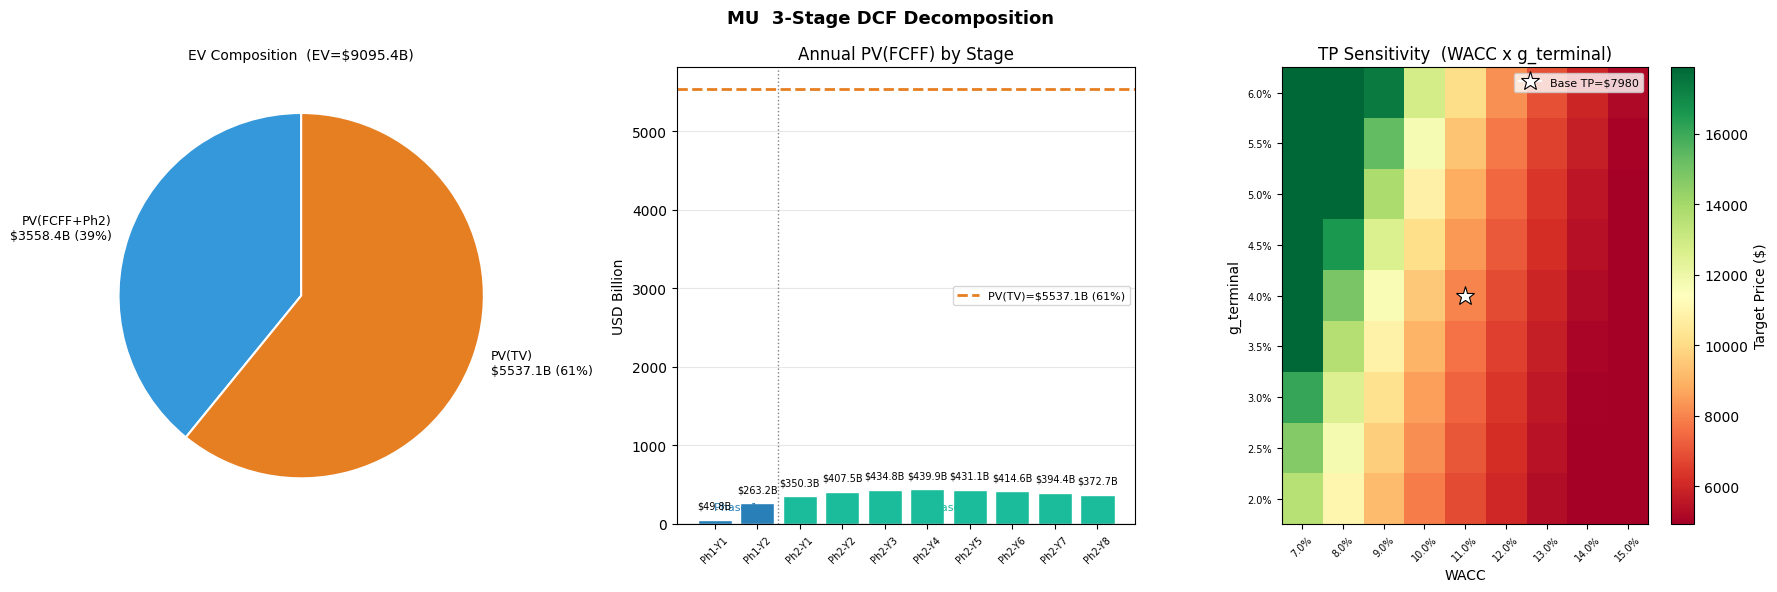

[Moat Analysis]
    ROIC (TTM)    : 31.51%
    WACC          : 11.00%
    EVA spread    : +20.50%
    Moat grade    : Some moat
    AR(1) rho     : 0.575
    Phase2 period : 8 yr


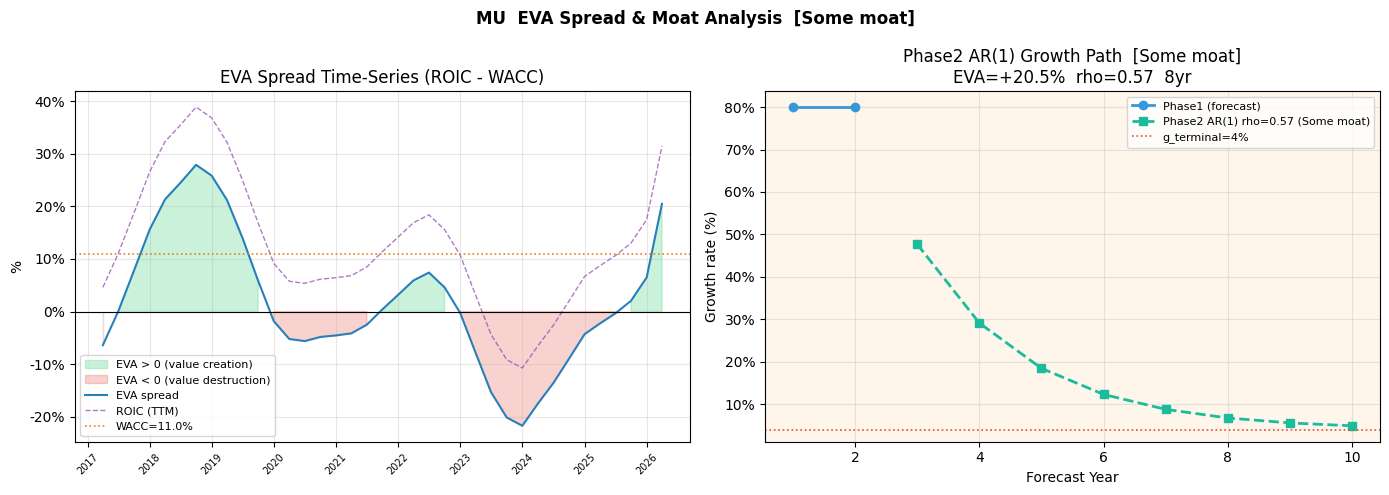

In [22]:
# ═══════════════════════════════════════════════════════════════
#  Cell 4.5 · 3-Stage DCF Decomposition & EVA Diagnostics
# ═══════════════════════════════════════════════════════════════

DIAG_TICKER = TEST_TICKER   # <- change ticker here

print(f"[Diagnostics] Running DCFModel for {DIAG_TICKER} ...")
_dm = DCFModel(ticker=DIAG_TICKER, engine=engine, verbose=True)
_dm.run()

v  = _dm.valuation
df = _dm.result_df.copy()
h  = _dm._fcff_history

wacc      = v["wacc"]
g_term    = v["g_terminal"]
ph1       = np.array(v["ph1_annual"])
ph2       = np.array(v["ph2_annual"])
g_ph2     = v["ph2_growth"]
all_ann   = np.array(v["all_annual"])
T_total   = v["t_total"]
fcff_last = v["fcff_last_annual"]
pv_fcff   = v["pv_fcff"]
tv        = v["terminal_value"]
pv_tv     = v["pv_tv"]
tv_wt     = v["tv_weight_pct"]
ev        = v["enterprise_value"]
net_debt  = v["net_debt"]
eq_val    = v["equity_value"]
shares    = v["shares"]
tp        = v["target_price"]
cp        = v["current_price"]

SEP = "=" * 66
print(f"\n{SEP}")
print(f"  {DIAG_TICKER}  3-Stage DCF Decomposition")
print(SEP)

print(f"\n[1] Discount rate")
print(f"    WACC          : {wacc*100:.4f}%")
print(f"    g_terminal    : {g_term*100:.4f}%")
print(f"    WACC - g      : {(wacc-g_term)*100:.4f}%")

print(f"\n[2] Phase 1 - Forecast FCFF (Year 1~{len(ph1)})")
cum = 0.0
for t, f in enumerate(ph1, 1):
    pv = f / (1+wacc)**t; cum += pv
    q0 = df["quarter"].iloc[(t-1)*4] if (t-1)*4 < len(df) else "?"
    q1 = df["quarter"].iloc[min(t*4-1, len(df)-1)]
    print(f"    Year {t} ({q0}~{q1})  FCFF={f/1e9:>8.3f}B  PV={pv/1e9:>8.3f}B  Cum={cum/1e9:>8.3f}B")

print(f"\n[3] Phase 2 - Growth convergence (Year {len(ph1)+1}~{len(ph1)+len(ph2)})")
for t_off, (f, g) in enumerate(zip(ph2, g_ph2), 1):
    yr = len(ph1) + t_off
    pv = f / (1+wacc)**yr; cum += pv
    print(f"    Year {yr}  g={g*100:>5.1f}%  FCFF={f/1e9:>8.3f}B  PV={pv/1e9:>8.3f}B  Cum={cum/1e9:>8.3f}B")

print(f"\n[4] Phase 3 - Terminal Value")
print(f"    Last annual FCFF : ${fcff_last/1e9:.3f}B")
print(f"    TV = {fcff_last/1e9:.3f}B x {1+g_term:.4f} / {wacc-g_term:.4f} = ${tv/1e9:.3f}B")
print(f"    PV(TV) = TV / (1+WACC)^{T_total} = ${pv_tv/1e9:.3f}B")

fcff_wt = pv_fcff / ev * 100 if ev != 0 else float("nan")
print(f"\n[5] EV Breakdown")
print(f"    PV(Phase1+2 FCFF) = ${pv_fcff/1e9:.3f}B  ({fcff_wt:.1f}%)")
print(f"    PV(TV)            = ${pv_tv/1e9:.3f}B  ({tv_wt:.1f}%)")
print(f"    Enterprise Value  = ${ev/1e9:.3f}B")

print(f"\n[6] Equity Bridge")
print(f"    EV ${ev/1e9:.3f}B  -  Net Debt ${net_debt/1e9:.3f}B  =  Equity ${eq_val/1e9:.3f}B")
tp_str = f"${tp:.2f}" if not np.isnan(tp) else "N/A"
up_str = f"{v['upside_pct']:.1f}%" if not np.isnan(v.get('upside_pct', float('nan'))) else "N/A"
print(f"    / {shares/1e6:.0f}M shares  =  TP {tp_str}  (Current ${cp:.2f}, Upside {up_str})")

print(f"\n{SEP}\n")

# ════════════════════════════════════════════════════════════════
# Visualisation  (1 x 3)
# ════════════════════════════════════════════════════════════════
_ev_positive = ev > 0 and pv_fcff > 0 and pv_tv > 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"{DIAG_TICKER}  3-Stage DCF Decomposition", fontsize=13, fontweight="bold")

# ── A: EV composition pie ────────────────────────────────────────
ax = axes[0]
if _ev_positive:
    ax.pie(
        [pv_fcff, pv_tv],
        labels=[f"PV(FCFF+Ph2)\n${pv_fcff/1e9:.1f}B ({fcff_wt:.0f}%)",
                f"PV(TV)\n${pv_tv/1e9:.1f}B ({tv_wt:.0f}%)"],
        colors=["#3498db", "#e67e22"],
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
        textprops=dict(fontsize=9),
    )
    ax.set_title(f"EV Composition  (EV=${ev/1e9:.1f}B)", fontsize=10)
else:
    ax.axis("off")
    msg  = f"EV = ${ev/1e9:.1f}B\n"
    msg += f"PV(FCFF) = ${pv_fcff/1e9:.1f}B\n"
    msg += f"PV(TV)   = ${pv_tv/1e9:.1f}B\n\n"
    msg += "Negative EV: pie chart\nnot applicable."
    ax.text(0.5, 0.5, msg, transform=ax.transAxes,
            ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#ffeeba", alpha=0.9))
    ax.set_title("EV Composition  (negative — chart skipped)", fontsize=10)

# ── B: Annual PV(FCFF) bar + PV(TV) line ────────────────────────
ax = axes[1]
yr_labels  = [f"Ph1-Y{i+1}" for i in range(len(ph1))] +              [f"Ph2-Y{i+1}" for i in range(len(ph2))]
pv_yr      = [f / (1+wacc)**(t+1) for t, f in enumerate(all_ann)]
colors_yr  = (["#2980b9"] * len(ph1)) + (["#1abc9c"] * len(ph2))

ax.bar(yr_labels, [v_ / 1e9 for v_ in pv_yr], color=colors_yr, edgecolor="white")
ax.axhline(pv_tv / 1e9, color="#e67e22", lw=2.0, ls="--",
           label=f"PV(TV)=${pv_tv/1e9:.1f}B ({tv_wt:.0f}%)")
ax.axvline(len(ph1) - 0.5, color="gray", lw=1, ls=":")

_ylim = ax.get_ylim()
_y_txt = _ylim[0] + (_ylim[1] - _ylim[0]) * 0.03
ax.text(len(ph1)/2 - 0.5, _y_txt, "Phase 1", ha="center", fontsize=8, color="#2980b9")
ax.text(len(ph1) + len(ph2)/2 - 0.5, _y_txt, "Phase 2", ha="center", fontsize=8, color="#1abc9c")

for i, val in enumerate(pv_yr):
    offset = abs(_ylim[1] - _ylim[0]) * 0.02
    va = "bottom" if val >= 0 else "top"
    y_pos = val/1e9 + (offset if val >= 0 else -offset)
    ax.text(i, y_pos, f"${val/1e9:.1f}B", ha="center", va=va, fontsize=7)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Annual PV(FCFF) by Stage")
ax.set_ylabel("USD Billion")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── C: WACC x g sensitivity heatmap ─────────────────────────────
ax = axes[2]
wacc_range = np.arange(max(wacc - 0.04, 0.04), wacc + 0.045, 0.01)
g_range    = np.arange(max(g_term - 0.02, 0.0), g_term + 0.025, 0.005)

tp_mat = np.full((len(g_range), len(wacc_range)), np.nan)
for ri, g_ in enumerate(g_range):
    for ci, w_ in enumerate(wacc_range):
        if w_ - g_ < 0.005:
            continue
        pv_f = sum(all_ann[t] / (1+w_)**(t+1) for t in range(T_total))
        tv_  = fcff_last * (1+g_) / (w_ - g_)
        ev_  = pv_f + tv_ / (1+w_)**T_total
        if shares > 0:
            tp_mat[ri, ci] = (ev_ - net_debt) / shares

_valid = tp_mat[~np.isnan(tp_mat)]
if len(_valid) > 0:
    im = ax.imshow(tp_mat, aspect="auto", cmap="RdYlGn",
                   vmin=np.nanpercentile(tp_mat, 10),
                   vmax=np.nanpercentile(tp_mat, 90),
                   origin="lower")
    plt.colorbar(im, ax=ax, label="Target Price ($)")
    ax.set_xticks(range(len(wacc_range)))
    ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_range], rotation=45, fontsize=7)
    ax.set_yticks(range(len(g_range)))
    ax.set_yticklabels([f"{g_*100:.1f}%" for g_ in g_range], fontsize=7)
    ax.set_xlabel("WACC")
    ax.set_ylabel("g_terminal")
    ax.set_title("TP Sensitivity  (WACC x g_terminal)")
    ci_cur = np.argmin(np.abs(wacc_range - wacc))
    ri_cur = np.argmin(np.abs(g_range    - g_term))
    tp_str2 = f"${tp:.0f}" if not np.isnan(tp) else "N/A"
    ax.plot(ci_cur, ri_cur, marker="*", ms=14, color="white",
            markeredgecolor="black", markeredgewidth=0.8,
            label=f"Base TP={tp_str2}")
    ax.legend(fontsize=8)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "All TP values invalid\n(negative FCFF / EV)",
            transform=ax.transAxes, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#ffeeba", alpha=0.9))
    ax.set_title("TP Sensitivity  (skipped)")

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# EVA spread time-series + Moat diagnostics
# ════════════════════════════════════════════════════════════════
eva_series = v.get("eva_series", [])
moat_label = v.get("moat_label", "N/A")
eva_spread = v.get("eva_spread", np.nan)
roic_val   = v.get("roic",       np.nan)
moat_rho   = v.get("moat_rho",   np.nan)
n_ph2      = v.get("n_phase2",   0)

print("[Moat Analysis]")
print(f"    ROIC (TTM)    : {roic_val*100:.2f}%" if not np.isnan(roic_val) else "    ROIC      : N/A")
print(f"    WACC          : {wacc*100:.2f}%")
print(f"    EVA spread    : {eva_spread*100:+.2f}%" if not np.isnan(eva_spread) else "    EVA spread : N/A")
print(f"    Moat grade    : {moat_label}")
print(f"    AR(1) rho     : {moat_rho:.3f}" if not np.isnan(moat_rho) else "    rho       : N/A")
print(f"    Phase2 period : {n_ph2} yr")

if eva_series:
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    fig2.suptitle(f"{DIAG_TICKER}  EVA Spread & Moat Analysis  [{moat_label}]",
                  fontsize=12, fontweight="bold")

    # ── EVA spread time-series ────────────────────────────────────
    ax = axes2[0]
    dates_e = [e["date"] for e in eva_series]
    spreads = [e["eva_spread"] * 100 for e in eva_series]
    roics   = [e["roic"]       * 100 for e in eva_series]

    ax.fill_between(dates_e, spreads, 0,
                    where=[s > 0 for s in spreads],
                    color="#2ecc71", alpha=0.25, label="EVA > 0 (value creation)")
    ax.fill_between(dates_e, spreads, 0,
                    where=[s <= 0 for s in spreads],
                    color="#e74c3c", alpha=0.25, label="EVA < 0 (value destruction)")
    ax.plot(dates_e, spreads, color="#2980b9", lw=1.5, label="EVA spread")
    ax.plot(dates_e, roics,   color="#8e44ad", lw=1.0, ls="--", alpha=0.7, label="ROIC (TTM)")
    ax.axhline(0,           color="black",   lw=0.8)
    ax.axhline(wacc * 100,  color="#e67e22", lw=1.2, ls=":", label=f"WACC={wacc*100:.1f}%")
    ax.set_title("EVA Spread Time-Series (ROIC - WACC)")
    ax.set_ylabel("%")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Moat grade + AR(1) growth path ───────────────────────────
    ax = axes2[1]

    # Phase 1 implied growth: Year2 FCFF / Year1 FCFF - 1
    if len(ph1) >= 2 and ph1[0] > 0:
        _g0 = float(np.clip(ph1[1] / ph1[0] - 1, -0.50, 0.80))
    else:
        _g0 = 0.10

    yrs_ph2 = list(range(3, 3 + n_ph2))

    # ★ FIX: ph2(FCFF 달러) 가 아니라 g_ph2(성장률) 를 사용해야 함
    g_ph2_arr = np.asarray(g_ph2, dtype=float)
    if len(g_ph2_arr) >= n_ph2:
        ph2_pct = [g * 100 for g in g_ph2_arr[:n_ph2]]
    else:
        ph2_pct = [_g0 * 100] * n_ph2

    ax.plot([1, 2], [_g0 * 100, _g0 * 100],
            "o-", color="#3498db", lw=2, label="Phase1 (forecast)")
    if yrs_ph2 and ph2_pct:
        ax.plot(yrs_ph2, ph2_pct, "s--", color="#1abc9c", lw=2,
                label=f"Phase2 AR(1) rho={moat_rho:.2f} ({moat_label})" if not np.isnan(moat_rho) else "Phase2")
    ax.axhline(GDP_GROWTH * 100, color="#e74c3c", lw=1.2, ls=":",
               label=f"g_terminal={GDP_GROWTH*100:.0f}%")

    moat_colors = {"Wide moat":   "#27ae60", "Narrow moat": "#2980b9",
                   "Some moat":   "#f39c12", "No moat":     "#e74c3c"}
    ax.set_facecolor(moat_colors.get(moat_label, "#95a5a6") + "15")

    eva_str = f"{eva_spread*100:+.1f}%" if not np.isnan(eva_spread) else "N/A"
    rho_str = f"{moat_rho:.2f}"         if not np.isnan(moat_rho)   else "N/A"
    ax.set_title(f"Phase2 AR(1) Growth Path  [{moat_label}]\n"
                 f"EVA={eva_str}  rho={rho_str}  {n_ph2}yr")
    ax.set_xlabel("Forecast Year")
    ax.set_ylabel("Growth rate (%)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("  [No EVA series — insufficient IS/BS data]")


## Cell 4.13 (NEW v13) · Validity Patch — 통화 가드 + 자본비용 현실화 + TV 보수화 + Sanity Guard

**v12 결과 검증에서 확인된 4가지 구조적 문제와 수정 사항**

| # | 문제 (v12) | 증상 | 수정 (v13) |
|---|---|---|---|
| 1 | **통화 불일치 (ADR)** — FMP 재무제표는 현지통화(COP/IDR/KRW/JPY…), 주가는 USD. 주식수도 현지 상장 기준 | EC upside 1,758만%, TLK 1,543만% 등 해외기업 상위 도배 | `reportedCurrency ≠ USD` → 평가 제외 (currency guard) |
| 2 | **WACC 하한 4% 절대값** — 고레버리지 기업은 D/V↑로 WACC≈Rd(1−T)≈3~4% → floor 도달 (200개 중 73개가 정확히 4.0%). ADR은 부채(현지통화)+시총(USD) 혼합으로 D/V≈1 | WACC 4%대 양산 | Rd ≥ Rf, WACC ≥ max(5%, Rf+1%) — 금리 연동 하한 |
| 3 | **TV 스프레드 1% 강제** — `g = wacc − 0.01` → TV배수 = (1+g)/(WACC−g) ≈ 103배 연간 FCFF (200개 중 91개가 spread 정확히 1%) | NWL/CVS/SIRI 등 미국기업 upside 1,000%+ | 최소 스프레드 2%, g ≤ min(GDP, **Rf**) (Damodaran: 영구성장률 ≤ 무위험수익률), TV/FCFF 배수 상한 35배 |
| 4 | **시총 괴리 검증 부재** — 산출 지분가치가 실제 시총의 수천~수십만 배여도 그대로 저장 | DISH 지분가치/시총 13만 배 | 지분가치 vs 실제 시총 배율 30배 초과(또는 1/30 미만) → 평가 제외 |

**잔여 한계 (정직한 고지)**: 고레버리지·저성장 기업(CVS 등)은 v13 이후에도 시장가 대비 낙관적일 수 있습니다. 시장은 이들에게 모델보다 높은 할인율(부도위험 프리미엄)을 요구하기 때문입니다. 통합 후보 선정 단계의 `UPSIDE_CAP=150%` 필터와 병행 사용을 권장합니다.

상수 4개(`V13_*`)로 가드 on/off 및 임계값 조정 가능. 원본 메서드는 `_compute_wacc_v11_5` / `_compute_valuation_v12` / `_run_v12` 로 보존됩니다.

**⑤ 매 실행 전체 재계산 (체크포인트 측정일 분리)**: `done_tickers.txt` → `done_tickers_{RUN_DATE}.txt` 로 분리되어 **새 측정일에 실행하면 전 종목이 다시 계산·저장**됩니다. 같은 측정일 내 재실행은 완료분을 건너뛰는 크래시 복구 용도로만 동작하며, 2일 이상 걸리는 배치는 `RUN_DATE_OVERRIDE` 로 측정일을 고정해 이어갈 수 있습니다. 아울러 동일 측정일 재저장 시 4개 컬럼만 갱신되던 upsert 를 전 컬럼 갱신으로 수정했습니다.

In [23]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.13 (NEW v13) · Validity Patch
#  ───────────────────────────────────────────────────────────────────────
#  ① 통화 가드      : 재무제표 reportedCurrency ≠ USD → 평가 제외 (ADR 차단)
#  ② 자본비용 현실화 : Rd ≥ Rf,  WACC ≥ max(5%, Rf+1%)  (기존 절대 4% floor 폐지)
#  ③ TV 보수화      : g_terminal ≤ min(GDP, Rf), 최소 스프레드 2%(기존 1%),
#                     TV/연간FCFF 배수 상한 35배 (이중 안전장치)
#  ④ Sanity Guard   : |산출 지분가치 / 실제 시총| > 30배 (또는 < 1/30) → 제외
#
#  ※ 반드시 Cell 4 ~ 4.12 실행 후 마지막에 실행하세요 (최종 패치).
#  ※ 원본 보존: _compute_wacc_v11_5 / _compute_valuation_v12 / _run_v12
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import requests

# ── v13 가드 상수 — 여기만 수정하세요 ───────────────────────────────────
V13_CURRENCY_GUARD   = True     # ① 재무제표 통화 ≠ USD → 제외
V13_SANITY_GUARD     = True     # ④ 지분가치/시총 괴리 검사
V13_SANITY_MC_RATIO  = 30.0     # ④ 허용 배율 상한 (30배 초과 또는 1/30 미만 → 제외)
V13_WACC_FLOOR_ABS   = 0.05     # ② WACC 절대 하한 (max(이 값, Rf+1%) 적용)
V13_MIN_TV_SPREAD    = 0.02     # ③ WACC − g 최소 스프레드 (기존 0.01)
V13_TV_FCFF_MULT_CAP = 35.0     # ③ TV / 마지막 연간 FCFF 배수 상한


# ════════════════════════════════════════════════════════════════════
#  ① 통화 가드 — FMP income-statement 의 reportedCurrency 활용 (추가 API 없음)
# ════════════════════════════════════════════════════════════════════
def _check_currency_v13(self):
    """재무제표 통화 확인. USD 가 아니면 ValueError → batch 에서 fail 기록.

    근거: FMP 는 ADR 의 재무제표를 현지통화로, 주가는 USD 로 반환.
          주식수(weightedAverageShsOut)도 현지 상장주 기준이라 ADR 비율과 달라
          환율 환산만으로는 TP 를 복원할 수 없음 → 제외가 가장 안전.
    """
    cur = None
    inc = getattr(self, "_inc", None)
    if inc is not None and not inc.empty and "reportedCurrency" in inc.columns:
        s = inc["reportedCurrency"].dropna().astype(str).str.upper()
        if not s.empty:
            cur = s.mode().iloc[0]
    self._reported_currency = cur or "UNKNOWN"

    if cur is None:
        if self.verbose:
            log(self.ticker, "⚠ [v13] reportedCurrency 필드 없음 → 통화 검사 생략(USD 가정)")
        return

    if V13_CURRENCY_GUARD and cur != "USD":
        raise ValueError(
            f"[{self.ticker}] v13 통화 가드: 재무제표 통화={cur}, 주가=USD(ADR) "
            f"→ TP/현재가 비교 불가로 평가 제외")
    if self.verbose:
        log(self.ticker, f"[v13] 통화 검사 통과: reportedCurrency={cur}")


# ════════════════════════════════════════════════════════════════════
#  ② compute_wacc v13 — v11.5 단일경로 유지 + Rd/WACC 하한 현실화
#     (변경점은 ★v13 주석 2곳뿐, 나머지는 Cell 4.10 v11.5 와 동일)
# ════════════════════════════════════════════════════════════════════
def compute_wacc_v13(self) -> float:
    """WACC = Re × E/V + Rd × (1-T) × D/V   (Re = Rf + β_blume × ERP)"""
    # ── ① lazy fetch 보장 ─────────────────────────────────────
    prices = getattr(self, "_monthly_prices", None)
    needs_fetch = (
        prices is None or not isinstance(prices, pd.DataFrame)
        or prices.empty or len(prices) < 12
        or self.ticker not in prices.columns or "SP500" not in prices.columns
    )
    if needs_fetch and hasattr(self, "_fetch_v10_extras"):
        if self.verbose:
            log(self.ticker, "[v13] _monthly_prices 미적재 → _fetch_v10_extras 자동 호출")
        try:
            self._fetch_v10_extras(years=10)
        except Exception as e:
            if self.verbose:
                log(self.ticker, f"⚠ [v13] fetch 실패: {e}")

    # ── ② Damodaran ERP/Rf ──────────────────────────────────
    erp_info = self._get_erp_rf()
    rf, erp = erp_info["rf"], erp_info["erp"]
    rm = rf + erp

    # ── ③ Blume β ───────────────────────────────────────────
    beta_info = self._compute_beta_blume()
    if beta_info:
        beta_raw   = beta_info["beta_raw"]
        beta_blume = beta_info["beta_blume"]
        beta_fallback = False
    else:
        beta_raw = beta_blume = 1.0
        beta_fallback = True
        if self.verbose:
            log(self.ticker, "⚠ [v13] β 회귀 실패 → β=1.0 fallback")

    # ── ④ Re — 단일 경로 ────────────────────────────────────
    re = rf + beta_blume * erp

    if self.verbose:
        log(self.ticker,
            f"[v13] Re = {rf:.4f} + {beta_blume:.4f} × {erp:.4f} = {re:.4f}  "
            f"(Damodaran {erp_info['date']})"
            f"{' ★β=1.0 fallback' if beta_fallback else ''}")

    re_smooth = self._get_re_smooth() if hasattr(self, "_get_re_smooth") else None

    tax = self.estimate_tax_rate()

    # ── discount_mode='re' 분기 ─────────────────────────────
    if self.discount_mode == "re":
        self._wacc_cache = _build_cache(
            re, rf, erp, rm, erp_info, beta_raw, beta_blume, re_smooth,
            np.nan, "n/a (re mode)", tax, np.nan, np.nan, 1.0, 0.0,
            re, re, False, beta_fallback)
        return float(re)

    # ── ⑤ Rd / 시가총액 ─────────────────────────────────────
    bs, inc = self._bs, self._inc
    rd = 0.05
    rd_source = "default 5%"
    mkt_cap = 0.0
    total_debt = 0.0

    if "totalDebt" in bs.columns and "interestExpense" in inc.columns:
        latest_bs = bs.sort_values("date").iloc[-1]
        total_debt = pd.to_numeric(latest_bs.get("totalDebt", 0), errors="coerce") or 0

        ie = pd.to_numeric(inc["interestExpense"], errors="coerce").abs()
        td_avg = pd.to_numeric(bs["totalDebt"], errors="coerce")
        td_avg = (td_avg + td_avg.shift(1)) / 2
        valid = (td_avg > 0) & ie.notna()
        if valid.sum() >= 2:
            rd_series = (ie[valid] / td_avg[valid]).clip(0, 0.15)
            rd = float(rd_series.median())
            rd_source = f"median(ie/avg_td) over {valid.sum()} quarters"

        try:
            r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                             params={"apikey": self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                mkt_cap = float(data[0].get("marketCap", 0) or 0)
        except Exception:
            pass

    # ★v13-1: Rd 하한 = Rf — 장부 이자율(변동금리·구채권 효과)이 무위험수익률보다
    #         낮으면 forward-looking 부채비용으로 부적절 → 채권자도 최소 Rf 요구
    if rd < rf:
        rd_source += f" → Rf floor {rf:.2%} 적용"
        rd = float(rf)

    V = mkt_cap + total_debt
    if V > 1e6:
        we = mkt_cap / V
        wd = total_debt / V
        wacc_raw = re * we + rd * (1 - tax) * wd
        # ★v13-2: WACC 하한 = max(5%, Rf+1%) — 기존 절대 4% floor 는
        #         고레버리지 기업의 WACC 를 Rf 이하로 떨어뜨려 TV 발산을 유발
        wacc_lo = max(V13_WACC_FLOOR_ABS, rf + 0.01)
        wacc = float(np.clip(wacc_raw, wacc_lo, 0.25))
        clipped = abs(wacc - wacc_raw) > 1e-6

        self._wacc_cache = _build_cache(
            re, rf, erp, rm, erp_info, beta_raw, beta_blume, re_smooth,
            rd, rd_source, tax, mkt_cap, total_debt, we, wd,
            wacc_raw, wacc, clipped, beta_fallback)

        if self.verbose:
            log(self.ticker,
                f"[v13] WACC={wacc:.4f}  Re={re:.4f} Rd={rd:.4f} tax={tax:.4f}  "
                f"E/V={we:.3f} D/V={wd:.3f}"
                f"{'  ★floor ' + format(wacc_lo, '.2%') if clipped and wacc_raw < wacc_lo else ''}")
        return wacc

    # ── Fallback (V 계산 불가) ──────────────────────────────
    self._wacc_cache = _build_cache(
        re, rf, erp, rm, erp_info, beta_raw, beta_blume, re_smooth,
        rd, rd_source, tax, np.nan, np.nan, 1.0, 0.0,
        re, re, False, beta_fallback)
    if self.verbose:
        log(self.ticker, f"[v13] WACC 계산 불완전 → Re fallback={re:.4f}")
    return float(re)


# ════════════════════════════════════════════════════════════════════
#  ③+④ compute_valuation v13 — TV 보수화 + Sanity Guard
#       (변경점은 ★v13 주석 4곳, 나머지는 Cell 4 v12 원본과 동일)
# ════════════════════════════════════════════════════════════════════
def compute_valuation_v13(self) -> "DCFModel":
    """3-Stage DCF Valuation (v13: TV 보수화 + 시총 괴리 가드)"""
    wacc = self.compute_wacc()
    df   = self.result_df.copy()

    # ── reinvestment_rate median ──────────────────────────────
    pos = df[df["nopat"] > 0]["reinvestment_rate"].dropna()
    reinv_med = float(self._winsorize(pos).median()) if not pos.empty else 0.3

    # ── Phase 1: 분기 FCFF → 연간 합산 ────────────────────────
    fcff_q   = df["fcff"].values
    n_q      = len(fcff_q)
    ph1_annual = []
    for yr in range(0, n_q, 4):
        ph1_annual.append(float(np.sum(fcff_q[yr: yr + 4])))
    ph1_annual = np.array(ph1_annual)
    T_ph1 = len(ph1_annual)

    # ── Phase 2: 중간 성장 (Year 3-7) ─────────────────────────
    _ph2_result  = self._estimate_phase2_growth(wacc)
    ph2_growth, _moat_lbl, _rho, _n_ph2 = _ph2_result
    ph2_annual = []
    last_fcff  = float(ph1_annual[-1])
    for g_ph2 in ph2_growth:
        last_fcff = last_fcff * (1 + g_ph2)
        ph2_annual.append(last_fcff)
    ph2_annual = np.array(ph2_annual)

    # ── Phase 3: Terminal Value ────────────────────────────────
    g_terminal = self.compute_terminal_growth(reinv_med, wacc)

    # ★v13-3: 영구성장률 상한 = min(GDP, Rf)  (Damodaran: g_terminal ≤ riskfree)
    rf_v13 = float((getattr(self, "_wacc_cache", {}) or {}).get("rf", np.nan))
    if not np.isfinite(rf_v13):
        rf_v13 = self._get_erp_rf()["rf"]
    g_terminal = float(min(g_terminal, rf_v13, self.gdp_growth))

    # ★v13-4: 최소 스프레드 2% (기존 1% → TV배수 103배 양산 차단)
    if wacc - g_terminal < V13_MIN_TV_SPREAD:
        g_terminal = max(0.0, wacc - V13_MIN_TV_SPREAD)

    fcff_last_annual = float(ph2_annual[-1])
    tv = fcff_last_annual * (1 + g_terminal) / (wacc - g_terminal)

    # ★v13-5: TV/연간FCFF 배수 상한 (이중 안전장치, 양(+) FCFF 에만 적용)
    tv_capped = False
    if fcff_last_annual > 0 and tv > V13_TV_FCFF_MULT_CAP * fcff_last_annual:
        tv = V13_TV_FCFF_MULT_CAP * fcff_last_annual
        tv_capped = True
        if self.verbose:
            log(self.ticker,
                f"[v13] TV 배수 상한 적용: {V13_TV_FCFF_MULT_CAP:.0f}× FCFF "
                f"(spread={wacc - g_terminal:.2%})")
    tv_fcff_mult = tv / fcff_last_annual if fcff_last_annual > 0 else np.nan

    # ── PV 계산 (연간 WACC, 연도별 할인) ──────────────────────
    all_annual = np.concatenate([ph1_annual, ph2_annual])
    T_total    = len(all_annual)

    pv_fcff = float(sum(
        all_annual[t] / (1 + wacc) ** (t + 1)
        for t in range(T_total)
    ))
    pv_tv = tv / (1 + wacc) ** T_total

    ev = pv_fcff + pv_tv

    # ── Net Debt ───────────────────────────────────────────────
    net_debt = 0.0
    if not self._bs.empty:
        latest = self._bs.sort_values("date").iloc[-1]
        td   = pd.to_numeric(latest.get("totalDebt", 0),   errors="coerce") or 0
        cash = pd.to_numeric(latest.get("cashAndCashEquivalents", 0), errors="coerce") or 0
        net_debt = float(td - cash)

    equity_val = ev - net_debt

    # ── Shares ─────────────────────────────────────────────────
    shares = np.nan
    if "weightedAverageShsOutDil" in self._inc.columns:
        s = pd.to_numeric(self._inc["weightedAverageShsOutDil"].iloc[-1], errors="coerce")
        if pd.notna(s) and s > 0:
            shares = float(s)
    if np.isnan(shares) and "weightedAverageShsOut" in self._inc.columns:
        s = pd.to_numeric(self._inc["weightedAverageShsOut"].iloc[-1], errors="coerce")
        if pd.notna(s) and s > 0:
            shares = float(s)

    target_price = equity_val / shares if (not np.isnan(shares) and shares > 0) else np.nan

    # ── 현재 주가 ──────────────────────────────────────────────
    current_price = np.nan
    try:
        r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=10)
        data = r.json()
        if isinstance(data, list) and data:
            current_price = float(data[0].get("price", np.nan) or np.nan)
    except Exception:
        pass

    upside = (
        ((target_price / current_price) - 1) * 100
        if (not np.isnan(target_price) and not np.isnan(current_price)
            and current_price > 0)
        else np.nan
    )

    tv_weight = pv_tv / ev * 100 if ev != 0 else np.nan

    # ★v13-6: Sanity Guard — 산출 지분가치 vs 실제 시총(USD) 괴리 검사
    mkt_cap_actual = float((getattr(self, "_wacc_cache", {}) or {}).get("mkt_cap", np.nan) or np.nan)
    mc_ratio = (equity_val / mkt_cap_actual
                if np.isfinite(mkt_cap_actual) and mkt_cap_actual > 1e6 else np.nan)
    if V13_SANITY_GUARD and np.isfinite(mc_ratio):
        if mc_ratio > V13_SANITY_MC_RATIO or 0 < mc_ratio < 1.0 / V13_SANITY_MC_RATIO:
            raise ValueError(
                f"[{self.ticker}] v13 sanity guard: 산출 지분가치 "
                f"${equity_val/1e9:,.1f}B vs 실제 시총 ${mkt_cap_actual/1e9:,.1f}B "
                f"= {mc_ratio:,.1f}배 (허용 ±{V13_SANITY_MC_RATIO:.0f}배) → 평가 제외. "
                f"입력 데이터(통화/주식수/FCFF) 점검 필요")

    self.valuation = {
        "ticker":             self.ticker,
        "wacc":               wacc,
        "g_terminal":         g_terminal,
        "reinvestment_rate":  reinv_med,
        "pv_fcff":            pv_fcff,
        "terminal_value":     tv,
        "pv_tv":              pv_tv,
        "tv_weight_pct":      tv_weight,
        "enterprise_value":   ev,
        "net_debt":           net_debt,
        "equity_value":       equity_val,
        "shares":             shares,
        "target_price":       target_price,
        "current_price":      current_price,
        "upside_pct":         upside,
        # 단계별 진단용
        "ph1_annual":         ph1_annual.tolist(),
        "ph2_annual":         ph2_annual.tolist(),
        "ph2_growth":         ph2_growth,
        "all_annual":         all_annual.tolist(),
        "t_total":            T_total,
        "fcff_last_annual":   fcff_last_annual,
        # 구버전 호환 키
        "annual_fcff":        all_annual.tolist(),
        # EVA / Moat 정보
        "moat_label":         getattr(self, "_eva_cache", {}).get("moat_label", "N/A"),
        "eva_spread":         getattr(self, "_eva_cache", {}).get("eva_spread", np.nan),
        "roic":               getattr(self, "_eva_cache", {}).get("roic", np.nan),
        "moat_rho":           getattr(self, "_eva_cache", {}).get("rho", np.nan),
        "n_phase2":           getattr(self, "_eva_cache", {}).get("n_phase2", 0),
        "eva_series":         getattr(self, "_eva_cache", {}).get("eva_series", []),
        "t_years":            T_total,
        # ★v13 진단 키 (DB 미저장 — Excel/화면 확인용)
        "tv_fcff_multiple":   tv_fcff_mult,
        "tv_capped":          tv_capped,
        "mktcap_actual":      mkt_cap_actual,
        "mktcap_ratio":       mc_ratio,
        "reported_currency":  getattr(self, "_reported_currency", "UNKNOWN"),
        "tv_spread":          wacc - g_terminal,
    }

    if self.verbose:
        log(self.ticker,
            f"3-Stage DCF [v13]  "
            f"Ph1={T_ph1}yr Ph2={len(ph2_annual)}yr TV  |  "
            f"EV=${ev/1e9:.2f}B  TP=${target_price:.2f}  "
            f"Upside={upside:.1f}%  TV비중={tv_weight:.1f}%  "
            f"TV배수={tv_fcff_mult:.0f}x  시총배율={mc_ratio:.1f}x")
    return self


# ════════════════════════════════════════════════════════════════════
#  run v13 — 통화 가드를 FCFF 계산 '이전'에 배치 (불필요 연산·API 차단)
# ════════════════════════════════════════════════════════════════════
def run_v13(self) -> "DCFModel":
    """load → currency guard → compute_fcff → compute_valuation(+sanity)"""
    self.load_sales()
    self.load_financials()
    self._check_currency_v13()      # ★v13 ①
    self.compute_fcff()
    self.compute_valuation()        # ★v13 ②③④ 내장
    return self


# ── 패치 적용 (원본 보존) ────────────────────────────────────────────────
if not hasattr(DCFModel, "_compute_wacc_v11_5"):
    DCFModel._compute_wacc_v11_5 = DCFModel.compute_wacc
if not hasattr(DCFModel, "_compute_valuation_v12"):
    DCFModel._compute_valuation_v12 = DCFModel.compute_valuation
if not hasattr(DCFModel, "_run_v12"):
    DCFModel._run_v12 = DCFModel.run

DCFModel._check_currency_v13 = _check_currency_v13
DCFModel.compute_wacc        = compute_wacc_v13
DCFModel.compute_valuation   = compute_valuation_v13
DCFModel.run                 = run_v13

print("=" * 72)
print("[v13] Validity Patch 적용 완료")
print(f"  ① 통화 가드          : {'ON' if V13_CURRENCY_GUARD else 'OFF'} (reportedCurrency ≠ USD → 제외)")
print(f"  ② 자본비용 하한       : Rd ≥ Rf,  WACC ≥ max({V13_WACC_FLOOR_ABS:.0%}, Rf+1%)")
print(f"  ③ TV 보수화          : g ≤ min(GDP, Rf), spread ≥ {V13_MIN_TV_SPREAD:.0%}, "
      f"TV ≤ {V13_TV_FCFF_MULT_CAP:.0f}×FCFF")
print(f"  ④ Sanity Guard       : {'ON' if V13_SANITY_GUARD else 'OFF'} "
      f"(지분가치/시총 ±{V13_SANITY_MC_RATIO:.0f}배 초과 → 제외)")
print("  ※ 제외 종목은 batch 에서 status='fail' + 사유(msg)로 기록됩니다")
print("=" * 72)

# ════════════════════════════════════════════════════════════════════
#  ⑤ save_to_db v13 — 같은 측정일 재실행 시 '모든' 값 컬럼을 새 결과로 갱신
#     (기존: fcff/TP/upside/EV 4개만 갱신 → 같은 날 재측정 시 WACC·g 등이
#      옛 값으로 남는 혼합 행 발생. v13: 전량 갱신 + created_at 재기록)
# ════════════════════════════════════════════════════════════════════
def save_to_db_v13(self, run_date: str = None) -> int:
    """result_df + valuation → us_fcff_dcf_valuation 저장"""
    if self.result_df is None or self.valuation is None:
        return 0
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    v = self.valuation
    df = self.result_df.copy()

    rows = []
    for _, row in df.iterrows():
        rows.append({
            "date":             run_date,
            "ticker":           self.ticker,
            "quarter":          row.get("quarter"),
            "sales_forecast":   row.get("sales_forecast"),
            "opm_forecast":     row.get("opm_forecast"),
            "ebit":             row.get("ebit"),
            "tax_rate":         row.get("tax_rate"),
            "nopat":            row.get("nopat"),
            "da":               row.get("da"),
            "capex":            row.get("capex"),
            "nwc":              row.get("nwc"),
            "delta_nwc":        row.get("delta_nwc"),
            "fcff":             row.get("fcff"),
            "roic":             row.get("roic"),
            "reinvestment_rate":v["reinvestment_rate"],
            "g_terminal":       v["g_terminal"],
            "discount_rate":    v["wacc"],
            "enterprise_value": v["enterprise_value"],
            "net_debt":         v["net_debt"],
            "equity_value":     v["equity_value"],
            "shares":           v["shares"],
            "target_price":     v["target_price"],
            "current_price":    v["current_price"],
            "upside_pct":       v["upside_pct"],
        })

    save_df = pd.DataFrame(rows)
    # NaN → None 변환
    save_df = save_df.where(pd.notnull(save_df), None)

    sql = f"""
        INSERT INTO `{TABLE_RESULT}`
        (date, ticker, quarter, sales_forecast, opm_forecast, ebit, tax_rate,
         nopat, da, capex, nwc, delta_nwc, fcff, roic, reinvestment_rate,
         g_terminal, discount_rate, enterprise_value, net_debt, equity_value,
         shares, target_price, current_price, upside_pct)
        VALUES
        (%(date)s, %(ticker)s, %(quarter)s, %(sales_forecast)s, %(opm_forecast)s,
         %(ebit)s, %(tax_rate)s, %(nopat)s, %(da)s, %(capex)s, %(nwc)s,
         %(delta_nwc)s, %(fcff)s, %(roic)s, %(reinvestment_rate)s,
         %(g_terminal)s, %(discount_rate)s, %(enterprise_value)s, %(net_debt)s,
         %(equity_value)s, %(shares)s, %(target_price)s, %(current_price)s,
         %(upside_pct)s)
        ON DUPLICATE KEY UPDATE
            sales_forecast=VALUES(sales_forecast), opm_forecast=VALUES(opm_forecast),
            ebit=VALUES(ebit), tax_rate=VALUES(tax_rate), nopat=VALUES(nopat),
            da=VALUES(da), capex=VALUES(capex), nwc=VALUES(nwc),
            delta_nwc=VALUES(delta_nwc), fcff=VALUES(fcff), roic=VALUES(roic),
            reinvestment_rate=VALUES(reinvestment_rate),
            g_terminal=VALUES(g_terminal), discount_rate=VALUES(discount_rate),
            enterprise_value=VALUES(enterprise_value), net_debt=VALUES(net_debt),
            equity_value=VALUES(equity_value), shares=VALUES(shares),
            target_price=VALUES(target_price), current_price=VALUES(current_price),
            upside_pct=VALUES(upside_pct),
            created_at=CURRENT_TIMESTAMP
    """
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.executemany(sql, save_df.to_dict("records"))
        conn.commit()
    except Exception:
        conn.rollback(); raise
    finally:
        conn.close()
    return len(rows)



if not hasattr(DCFModel, "_save_to_db_v12"):
    DCFModel._save_to_db_v12 = DCFModel.save_to_db
DCFModel.save_to_db = save_to_db_v13
print("  ⑤ save_to_db v13     : 동일 (ticker,date,quarter) 재저장 시 전 컬럼 갱신 + created_at 갱신")


[v13] Validity Patch 적용 완료
  ① 통화 가드          : ON (reportedCurrency ≠ USD → 제외)
  ② 자본비용 하한       : Rd ≥ Rf,  WACC ≥ max(5%, Rf+1%)
  ③ TV 보수화          : g ≤ min(GDP, Rf), spread ≥ 2%, TV ≤ 35×FCFF
  ④ Sanity Guard       : ON (지분가치/시총 ±30배 초과 → 제외)
  ※ 제외 종목은 batch 에서 status='fail' + 사유(msg)로 기록됩니다
  ⑤ save_to_db v13     : 동일 (ticker,date,quarter) 재저장 시 전 컬럼 갱신 + created_at 갱신


## Cell 4.14 (v13.1) · 추가 패치 — 매출 클램프 + 누락 진단 + 해외 FX

**실행 위치**: 반드시 Cell 4.13(v13 Validity Patch) **직후**, Cell 5.0(단일 실행) **직전**.

| Part | 내용 | 효과 |
|------|------|------|
| A | 매출 엔벨로프 클램프 (`load_sales` 래핑) | NVDA·MU 등 예측 폭발 → Upside 정상화 |
| B | 누락 진단 도구 `diagnose_missing_tickers` | FIT·DY 등이 어느 단계에서 빠지는지 출력 |
| C | 해외기업 FX valuation (별도 경로) | 비USD 기업을 제외 대신 환율 환산으로 평가 |

- 원본/이전 메서드는 모두 alias 로 보존 (롤백 가능).
- 토글: `CLAMP_ENABLED`, `CLAMP_MAX_YOY`(기본 0.60), `V13_FOREIGN_FX_MODE`.
- ⚠ Cell 4.13 을 다시 실행하면 `run`/`load_sales` 가 v13 로 되돌아가므로, **이 셀도 다시 실행**하세요.


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
#  FCFF DCF Valuation — v13.1 추가 패치 (3종)
#  ───────────────────────────────────────────────────────────────────────────
#  ★ 반드시 Cell 4.13 (v13 Validity Patch, Cell 26) 실행 '이후' 에 실행하세요.
#  ★ 원본/이전 메서드는 alias 로 보존됩니다 (롤백 가능).
#
#  Part A · 매출 엔벨로프 클램프  → NVDA·MU 등 예측 폭발 종목의 Upside 정상화
#  Part B · 누락 진단 도구        → FIT·DY 등이 어느 단계에서 빠지는지 정확히 출력
#  Part C · 해외기업 환율 valuation → 통화가드 대신 FX 환산으로 평가에 포함
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import requests


# ███████████████████████████████████████████████████████████████████████████
#  Part A ·  Cell 4.14a — 매출 예측 엔벨로프 클램프
#  ───────────────────────────────────────────────────────────────────────────
#  원리: _sales_forecast(예측 매출 '레벨')의 전년동기대비(YoY) 성장률을
#        상·하한으로 가둔다. 분기 시계열이라 YoY 기준이면 계절성 자동 처리.
#        · 예측분기 d 의 기준값 = 1년 전(같은 분기) 값  (actual 또는 이미 클램프된 예측)
#        · 상한 = 기준값 × (1 + MAX_YOY) ,  하한 = 기준값 × (1 + MIN_YOY)
#        · 순차 처리 → 뒤 분기는 클램프된 앞 분기를 기준으로 복리 상한 적용
#        → MU(+1,892%) 같은 폭발이 60%/년 같은 합리적 상한으로 수렴
# ███████████████████████████████████████████████████████████████████████████

# ── 클램프 상수 — 여기만 수정하세요 ────────────────────────────────────────
CLAMP_ENABLED      = True      # False 면 클램프 미적용 (원본 동작)
CLAMP_MAX_YOY      = 0.80      # 예측 매출 연간(YoY) 성장 상한 (+60%/년)
CLAMP_MIN_YOY      = -0.50     # 예측 매출 연간(YoY) 하한  (-50%/년, 붕괴 방지)
CLAMP_QOQ_FALLBACK = True      # 1년 전 기준값이 없을 때 직전값 기반 QoQ 상한 사용


def _clamp_sales_forecast_v131(self) -> int:
    """self._sales_forecast 레벨을 YoY 엔벨로프로 클램프. 반환: 클램프된 분기 수."""
    if not CLAMP_ENABLED:
        return 0
    act = getattr(self, "_sales_actual", None)
    fc  = getattr(self, "_sales_forecast", None)
    if fc is None or fc.empty:
        return 0

    # actual + forecast 결합 (YoY 조회용). calendar Q end 로 정규화돼 있다고 가정.
    parts = [s for s in (act, fc) if s is not None and not s.empty]
    combined = pd.concat(parts)
    combined = combined[~combined.index.duplicated(keep="last")].sort_index()

    up_mult, lo_mult = (1 + CLAMP_MAX_YOY), (1 + CLAMP_MIN_YOY)
    qoq_up = (1 + CLAMP_MAX_YOY) ** 0.25   # 분기 환산 상한 (fallback)
    qoq_lo = (1 + CLAMP_MIN_YOY) ** 0.25

    clamped = fc.copy()
    n_clamped = 0
    impl_before = []  # 진단용 (예측 첫 분기 YoY)

    for d in fc.index:
        v = float(combined.loc[d])
        ref_p = (d.to_period("Q") - 4).to_timestamp("Q")   # 1년 전 같은 분기
        ref = combined.loc[ref_p] if ref_p in combined.index else np.nan

        if pd.notna(ref) and float(ref) > 0:
            ref = float(ref)
            upper, lower = ref * up_mult, ref * lo_mult
            if not impl_before:
                impl_before.append((v / ref - 1) * 100)
        elif CLAMP_QOQ_FALLBACK:
            # 1년 전 값이 없으면 직전(가장 가까운 과거) 값으로 QoQ 상한
            past = combined.index[combined.index < d]
            if len(past) == 0:
                continue
            base = float(combined.loc[past[-1]])
            if base <= 0:
                continue
            upper, lower = base * qoq_up, base * qoq_lo
        else:
            continue

        nv = min(max(v, lower), upper)
        if abs(nv - v) > 1e-9:
            combined.loc[d] = nv
            clamped.loc[d] = nv
            n_clamped += 1

    self._sales_forecast = clamped

    if n_clamped > 0:
        # 진단: 클램프 전/후 마지막 예측분기 레벨 비교
        before_last = float(fc.iloc[-1]); after_last = float(clamped.iloc[-1])
        log(self.ticker,
            f"[clamp] 매출예측 {n_clamped}/{len(fc)} 분기 클램프 "
            f"(YoY 상한 {CLAMP_MAX_YOY:+.0%}) | "
            f"마지막 예측레벨 {before_last:,.0f} → {after_last:,.0f} "
            f"({(after_last/before_last-1)*100:+.1f}%)")
    self._sales_clamp_info = {"n_clamped": int(n_clamped),
                              "max_yoy": CLAMP_MAX_YOY, "min_yoy": CLAMP_MIN_YOY}
    return n_clamped


# load_sales 래핑 — 현재 load_sales(=_load_sales_v10_5) 실행 후 클램프
if not hasattr(DCFModel, "_load_sales_preclamp"):
    DCFModel._load_sales_preclamp = DCFModel.load_sales

def _load_sales_with_clamp(self) -> "DCFModel":
    self._load_sales_preclamp()
    try:
        self._clamp_sales_forecast_v131()
    except Exception as e:
        if getattr(self, "verbose", False):
            log(self.ticker, f"⚠ [clamp] 적용 실패(무시): {e}")
    return self

DCFModel._clamp_sales_forecast_v131 = _clamp_sales_forecast_v131
DCFModel.load_sales = _load_sales_with_clamp
print(f"[v13.1-A] 매출 엔벨로프 클램프 적용  "
      f"(ENABLED={CLAMP_ENABLED}, YoY 상한 {CLAMP_MAX_YOY:+.0%}, 하한 {CLAMP_MIN_YOY:+.0%})")


# ███████████████████████████████████████████████████████████████████████████
#  Part B ·  Cell 4.14b — 누락 종목 진단 도구
#  ───────────────────────────────────────────────────────────────────────────
#  process_one_ticker 는 어떤 예외든 삼키고 status='fail' 로만 기록하므로,
#  '어느 단계'에서 '왜' 실패했는지 단계별로 분리 실행해 정확히 출력한다.
# ███████████████████████████████████████████████████████████████████████████

def diagnose_missing_tickers(tickers, engine, verbose=False) -> pd.DataFrame:
    """누락 종목이 어느 단계에서 빠지는지 단계별 진단.
       예) diagnose_missing_tickers(["FIT","DY"], engine)
    """
    if isinstance(tickers, str):
        tickers = [tickers]
    out = []
    for t in tickers:
        rec = {"ticker": t, "fail_stage": "", "reason": "", "currency": "",
               "n_actual": None, "n_forecast": None, "upside_pct": None}
        try:
            m = DCFModel(ticker=t, engine=engine, verbose=verbose)
        except Exception as e:
            rec["fail_stage"] = "init"; rec["reason"] = str(e)[:160]
            out.append(rec); continue

        # ① load_sales (매출예측 테이블 존재 여부)
        try:
            m.load_sales()
            rec["n_actual"]   = len(m._sales_actual) if m._sales_actual is not None else 0
            rec["n_forecast"] = len(m._sales_forecast) if m._sales_forecast is not None else 0
        except Exception as e:
            rec["fail_stage"] = "load_sales"; rec["reason"] = str(e)[:160]
            out.append(rec); continue

        # ② load_financials (FMP 재무제표)
        try:
            m.load_financials()
        except Exception as e:
            rec["fail_stage"] = "load_financials"; rec["reason"] = str(e)[:160]
            out.append(rec); continue

        # ③ 통화 가드 (해외/ADR)
        try:
            m._check_currency_v13()
            rec["currency"] = getattr(m, "_reported_currency", "?")
        except Exception as e:
            rec["fail_stage"] = "currency_guard"
            rec["currency"]   = getattr(m, "_reported_currency", "?")
            rec["reason"]     = str(e)[:160]
            out.append(rec); continue

        # ④ compute_fcff
        try:
            m.compute_fcff()
        except Exception as e:
            rec["fail_stage"] = "compute_fcff"; rec["reason"] = str(e)[:160]
            out.append(rec); continue

        # ⑤ compute_valuation (sanity guard 포함)
        try:
            m.compute_valuation()
            rec["fail_stage"] = "OK"
            rec["upside_pct"] = m.valuation.get("upside_pct")
        except Exception as e:
            rec["fail_stage"] = "compute_valuation/sanity"; rec["reason"] = str(e)[:160]
        out.append(rec)

    df = pd.DataFrame(out)
    print("=" * 80)
    print("[누락 종목 단계별 진단]")
    print(df.to_string(index=False))
    print("=" * 80)
    print("fail_stage 해석:")
    print("  load_sales        → us_revenue_forecast_data 에 해당 ticker 매출(actual/forecast) 없음")
    print("                       (매출예측 노트북에서 누락 → 먼저 forecast 생성 필요)")
    print("  load_financials   → FMP 재무제표(IS/BS/CF) 없음/불완전")
    print("  currency_guard    → 재무제표 통화 ≠ USD (해외/ADR) → Part C 환율경로로 처리")
    print("  compute_valuation/sanity → 지분가치/시총 ±30배 초과 (입력 데이터 점검)")
    return df

print("[v13.1-B] 누락 진단 도구 등록 — diagnose_missing_tickers(['FIT','DY'], engine)")


# ███████████████████████████████████████████████████████████████████████████
#  Part C ·  Cell 4.14c — 해외기업 환율(FX) Valuation (별도 경로)
#  ───────────────────────────────────────────────────────────────────────────
#  핵심 아이디어:
#    · 재무제표는 현지통화로 '내부 정합'하므로 DCF 는 현지통화로 계산
#    · 마지막에 지분가치(현지) × FX → USD 로 환산
#    · Upside 는 '총액 기준'으로 계산: equity_value_USD / 시가총액_USD − 1
#      → ADR 비율·주식수 불일치 문제를 원천적으로 우회 (시총_USD 는 이미 정확)
#    · TP_USD = 현재가_USD × (equity_value_USD / 시총_USD)
#    · WACC 가중치도 시총을 현지통화로 환산해 부채(현지)와 통화 일치
# ███████████████████████████████████████████████████████████████████████████

V13_FOREIGN_FX_MODE = True     # True → 비USD 기업을 제외 대신 FX 환산으로 평가
V13_FOREIGN_SANITY  = 30.0     # 해외경로 sanity (USD 총액 기준 비교)


def _get_fx_to_usd(self, currency: str):
    """현지통화 1단위 = ? USD  (예: EUR→1.08, JPY→0.0067). 실패 시 None."""
    cur = (currency or "").upper().strip()
    if cur in ("", "USD", "UNKNOWN"):
        return 1.0 if cur == "USD" else None
    # 일부 표기 정규화 (pence·cents 등은 별도 주의 — 여기선 메이저만)
    pair = f"{cur}USD"
    try:
        r = requests.get(f"{FMP_BASE}/quote/{pair}",
                         params={"apikey": self.api_key}, timeout=10)
        data = r.json()
        if isinstance(data, list) and data:
            px = data[0].get("price", None)
            if px and float(px) > 0:
                return float(px)
    except Exception:
        pass
    # fallback: /fx 전체 조회
    try:
        r = requests.get(f"{FMP_BASE}/fx/{pair}",
                         params={"apikey": self.api_key}, timeout=10)
        data = r.json()
        if isinstance(data, list) and data:
            bid = data[0].get("bid") or data[0].get("price")
            if bid and float(bid) > 0:
                return float(bid)
    except Exception:
        pass
    return None


def _wacc_foreign_weights(self, fx: float) -> float:
    """v13 WACC 캐시(Re/Rd/tax/시총USD/부채현지)에서 가중치만 현지통화로 재산출."""
    self.compute_wacc()   # = compute_wacc_v13 → _wacc_cache 채움
    c = getattr(self, "_wacc_cache", {}) or {}
    re  = c.get("re", c.get("wacc"))
    rd  = c.get("rd", 0.05)
    tax = c.get("tax", 0.0)
    rf  = c.get("rf", 0.04)
    mkt_usd = c.get("mkt_cap", np.nan)
    debt_local = c.get("total_debt", 0.0) or 0.0
    if not (np.isfinite(mkt_usd) and mkt_usd > 0) or fx <= 0:
        return float(c.get("wacc", re))
    mkt_local = mkt_usd / fx                       # ★ USD 시총 → 현지통화
    V = mkt_local + debt_local
    if V <= 0:
        return float(c.get("wacc", re))
    we, wd = mkt_local / V, debt_local / V
    wacc_raw = re * we + rd * (1 - tax) * wd
    wacc_lo = max(V13_WACC_FLOOR_ABS, rf + 0.01)
    return float(np.clip(wacc_raw, wacc_lo, 0.25))


def compute_valuation_foreign(self) -> "DCFModel":
    """현지통화 DCF → FX 환산 → 총액기준 Upside (해외기업 전용)."""
    fx = getattr(self, "_fx_to_usd", None)
    if not fx or fx <= 0:
        raise ValueError(f"[{self.ticker}] FX 환율 조회 실패 → 해외 valuation 불가")

    wacc = self._wacc_foreign_weights(fx)
    df   = self.result_df.copy()

    # Phase 1: 분기 FCFF(현지통화) → 연간
    fcff_q = df["fcff"].values
    ph1 = np.array([float(np.sum(fcff_q[i:i+4])) for i in range(0, len(fcff_q), 4)])

    # Phase 2: 중간 성장
    ph2_growth, _lbl, _rho, _n = self._estimate_phase2_growth(wacc)
    last = float(ph1[-1]); ph2 = []
    for g in ph2_growth:
        last *= (1 + g); ph2.append(last)
    ph2 = np.array(ph2)

    # Phase 3: TV (v13 보수화 동일 규칙)
    pos = df[df["nopat"] > 0]["reinvestment_rate"].dropna()
    reinv = float(self._winsorize(pos).median()) if not pos.empty else 0.3
    g_t = self.compute_terminal_growth(reinv, wacc)
    rf_v = float((getattr(self, "_wacc_cache", {}) or {}).get("rf", np.nan))
    if not np.isfinite(rf_v):
        rf_v = self._get_erp_rf()["rf"]
    g_t = float(min(g_t, rf_v, self.gdp_growth))
    if wacc - g_t < V13_MIN_TV_SPREAD:
        g_t = max(0.0, wacc - V13_MIN_TV_SPREAD)
    fcff_last = float(ph2[-1])
    tv = fcff_last * (1 + g_t) / (wacc - g_t)
    if fcff_last > 0 and tv > V13_TV_FCFF_MULT_CAP * fcff_last:
        tv = V13_TV_FCFF_MULT_CAP * fcff_last

    all_annual = np.concatenate([ph1, ph2]); T = len(all_annual)
    pv_fcff = float(sum(all_annual[t] / (1 + wacc) ** (t + 1) for t in range(T)))
    pv_tv   = tv / (1 + wacc) ** T
    ev_local = pv_fcff + pv_tv                      # 현지통화

    # Net Debt (현지통화)
    net_debt_local = 0.0
    if not self._bs.empty:
        latest = self._bs.sort_values("date").iloc[-1]
        td   = pd.to_numeric(latest.get("totalDebt", 0), errors="coerce") or 0
        cash = pd.to_numeric(latest.get("cashAndCashEquivalents", 0), errors="coerce") or 0
        net_debt_local = float(td - cash)
    equity_local = ev_local - net_debt_local

    # ★ FX 환산 (현지 → USD) — 총액 기준
    equity_usd = equity_local * fx
    mkt_cap_usd = float((getattr(self, "_wacc_cache", {}) or {}).get("mkt_cap", np.nan) or np.nan)

    # 현재가(USD)
    current_price = np.nan
    try:
        r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=10)
        data = r.json()
        if isinstance(data, list) and data:
            current_price = float(data[0].get("price", np.nan) or np.nan)
    except Exception:
        pass

    # ★ 총액 기준 Upside (ADR 비율/주식수 우회)
    if np.isfinite(mkt_cap_usd) and mkt_cap_usd > 0:
        upside = (equity_usd / mkt_cap_usd - 1) * 100
        target_price = (current_price * equity_usd / mkt_cap_usd
                        if np.isfinite(current_price) else np.nan)
    else:
        upside = target_price = np.nan

    # Sanity (USD 총액 기준)
    ratio = equity_usd / mkt_cap_usd if (np.isfinite(mkt_cap_usd) and mkt_cap_usd > 0) else np.nan
    if np.isfinite(ratio) and (ratio > V13_FOREIGN_SANITY or 0 < ratio < 1/V13_FOREIGN_SANITY):
        raise ValueError(
            f"[{self.ticker}] 해외 sanity: equity_USD ${equity_usd/1e9:,.1f}B "
            f"vs 시총 ${mkt_cap_usd/1e9:,.1f}B = {ratio:,.1f}배 → 제외 (FX/주식수 점검)")

    self.valuation = {
        "ticker": self.ticker, "wacc": wacc, "g_terminal": g_t,
        "reinvestment_rate": reinv, "pv_fcff": pv_fcff, "terminal_value": tv,
        "pv_tv": pv_tv, "tv_weight_pct": pv_tv/ev_local*100 if ev_local else np.nan,
        "enterprise_value": ev_local * fx,          # USD 환산 저장
        "net_debt": net_debt_local * fx,
        "equity_value": equity_usd,
        "shares": np.nan,                           # 현지주식수 ≠ ADR → TP는 USD환산비율로
        "target_price": target_price, "current_price": current_price,
        "upside_pct": upside,
        "all_annual": all_annual.tolist(), "annual_fcff": all_annual.tolist(),
        "fcff_last_annual": fcff_last, "t_total": T, "t_years": T,
        "reported_currency": getattr(self, "_reported_currency", "?"),
        "fx_to_usd": fx, "equity_value_local": equity_local,
        "moat_label": getattr(self, "_eva_cache", {}).get("moat_label", "N/A"),
        "roic": getattr(self, "_eva_cache", {}).get("roic", np.nan),
        "tv_spread": wacc - g_t,
    }
    if self.verbose:
        log(self.ticker,
            f"[해외 v13.1] {self._reported_currency}→USD fx={fx:.5f}  "
            f"equity=현지 {equity_local/1e9:,.1f}B → USD ${equity_usd/1e9:,.1f}B  "
            f"시총 ${mkt_cap_usd/1e9:,.1f}B  TP=${target_price:,.2f}  Upside={upside:,.1f}%")
    return self


def _check_currency_v131(self):
    """v13.1: 비USD 라도 FOREIGN 모드면 제외하지 않고 _is_foreign 플래그만 설정."""
    cur = None
    inc = getattr(self, "_inc", None)
    if inc is not None and not inc.empty and "reportedCurrency" in inc.columns:
        s = inc["reportedCurrency"].dropna().astype(str).str.upper()
        if not s.empty:
            cur = s.mode().iloc[0]
    self._reported_currency = cur or "UNKNOWN"
    self._is_foreign = bool(cur and cur != "USD")

    if self._is_foreign and not V13_FOREIGN_FX_MODE:
        raise ValueError(f"[{self.ticker}] 통화 가드: {cur} ≠ USD → 제외")
    if self.verbose:
        tag = "해외(FX경로)" if self._is_foreign else "USD"
        log(self.ticker, f"[v13.1] 통화={self._reported_currency} → {tag}")


def run_v131(self) -> "DCFModel":
    """USD → v13 경로, 해외 → FX 경로 자동 분기."""
    self.load_sales()
    self.load_financials()
    self._check_currency_v131()
    self.compute_fcff()
    if getattr(self, "_is_foreign", False) and V13_FOREIGN_FX_MODE:
        self._fx_to_usd = self._get_fx_to_usd(self._reported_currency)
        self.compute_valuation_foreign()
    else:
        self.compute_valuation()       # v13 (USD 경로)
    return self


# ── 패치 적용 (원본 보존) ───────────────────────────────────────────────────
DCFModel._get_fx_to_usd          = _get_fx_to_usd
DCFModel._wacc_foreign_weights   = _wacc_foreign_weights
DCFModel.compute_valuation_foreign = compute_valuation_foreign
DCFModel._check_currency_v131    = _check_currency_v131
if not hasattr(DCFModel, "_run_v13_usd_only"):
    DCFModel._run_v13_usd_only = DCFModel.run
DCFModel.run = run_v131

print(f"[v13.1-C] 해외기업 FX valuation 적용  (FOREIGN_FX_MODE={V13_FOREIGN_FX_MODE})")
print("           · 비USD → 현지통화 DCF → FX 환산 → 총액기준 Upside")
print("           · save_to_db 시 shares=NaN(해외) → TP는 USD환산비율 기반")
print("=" * 76)
print("[v13.1] 3종 패치 적용 완료 — Part A(클램프) · B(진단) · C(해외FX)")
print("=" * 76)


[v13.1-A] 매출 엔벨로프 클램프 적용  (ENABLED=True, YoY 상한 +80%, 하한 -50%)
[v13.1-B] 누락 진단 도구 등록 — diagnose_missing_tickers(['FIT','DY'], engine)
[v13.1-C] 해외기업 FX valuation 적용  (FOREIGN_FX_MODE=True)
           · 비USD → 현지통화 DCF → FX 환산 → 총액기준 Upside
           · save_to_db 시 shares=NaN(해외) → TP는 USD환산비율 기반
[v13.1] 3종 패치 적용 완료 — Part A(클램프) · B(진단) · C(해외FX)


# ━━━━━━━━━━  PART 1-F · 해외기업 전용 모듈  ━━━━━━━━━━

위 PART 1(엔진·v13.1)을 모두 실행한 **뒤** 아래 두 셀(F1·F2)을 실행하세요.
기존 `_get_fx_to_usd` / `compute_valuation_foreign`(v13.1 Part C)을 **더 강건한 버전으로 override** 합니다.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  PART 1-F · 해외기업 전용 모듈 ①  —  강건한 FX(환율) 엔진
#  ───────────────────────────────────────────────────────────────────────────
#  ★ Cell 4.14 (v13.1) 까지 모두 실행한 '이후' 에 실행하세요.
#
#  [왜 필요한가]
#    기존 v13.1 Part C 의 _get_fx_to_usd 는 FMP /quote/{CUR}USD 한 방향만
#    시도 → JPY·TWD·KRW 처럼 FMP 가 'USDxxx' 방향으로만 호가하거나 아예
#    forex 목록에 없는 통화는 None 을 반환 → 해외기업이 통째로 제외됨.
#
#  [개선]
#    ① {CUR}USD 직접  ② USD{CUR} 역수  ③ /fx 전체목록  ④ historical close
#    ⑤ 정적 fallback 테이블(최후의 수단, 매월 수동 업데이트) 의 5단계.
#    → FX 조회 실패로 인한 누락을 사실상 0 으로.
#    ⑥ pence/cents 등 subunit(GBX·ZAc·ILA) 자동 정규화.
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import requests
import time

# ── 선택 의존성: FinanceDataReader (있으면 보조 소스로 사용) ────────────────
try:
    import FinanceDataReader as fdr
    _HAS_FDR = True
except Exception:
    _HAS_FDR = False


# ── subunit(보조통화) → 기준통화 정규화 맵 ──────────────────────────────────
#    재무제표 reportedCurrency 가 드물게 pence(GBX)·cents(ZAc) 로 올 때 대비.
#    (factor = 보조통화 1단위가 기준통화 몇 단위인지)
FX_SUBUNIT_MAP = {
    "GBX": ("GBP", 0.01), "GBP_PENCE": ("GBP", 0.01),
    "ZAC": ("ZAR", 0.01), "ILA": ("ILS", 0.01),
}

# ── 정적 fallback 환율 (1 현지통화 = ? USD) ─────────────────────────────────
#    ★ 매월 수동 업데이트 (Damodaran 상수와 동일한 운영방식).
#    ★ 라이브 FMP 조회가 우선이며, 이 표는 5단계 최후의 fallback 입니다.
_FX_STATIC_DATE = "2026-06-01"
FX_STATIC_TABLE = {
    "JPY": 0.0064, "EUR": 1.08, "GBP": 1.27, "CHF": 1.11, "CAD": 0.73,
    "AUD": 0.66, "NZD": 0.61, "HKD": 0.128, "CNY": 0.138, "TWD": 0.031,
    "KRW": 0.00073, "SGD": 0.74, "INR": 0.0117, "BRL": 0.18, "MXN": 0.052,
    "ILS": 0.27, "SEK": 0.094, "DKK": 0.145, "NOK": 0.092, "ZAR": 0.054,
    "THB": 0.028, "IDR": 0.000062, "PHP": 0.018, "MYR": 0.22, "PLN": 0.25,
    "TRY": 0.029, "RUB": 0.011, "AED": 0.272, "SAR": 0.267, "CLP": 0.0011,
    "COP": 0.00025, "ARS": 0.0011, "CZK": 0.043, "HUF": 0.0028, "RON": 0.217,
}


def _fmp_fx_quote(pair: str, api_key: str) -> float:
    """FMP /quote/{pair} → price (float) | None"""
    try:
        r = requests.get(f"{FMP_BASE}/quote/{pair}",
                         params={"apikey": api_key}, timeout=10)
        data = r.json()
        if isinstance(data, list) and data:
            px = data[0].get("price", None)
            if px and float(px) > 0:
                return float(px)
    except Exception:
        pass
    return None


def _fmp_fx_list(cur: str, api_key: str) -> float:
    """FMP /fx 전체목록에서 {cur}/USD 또는 USD/{cur} 를 찾아 USD/현지 반환 | None"""
    try:
        r = requests.get(f"{FMP_BASE}/fx", params={"apikey": api_key}, timeout=12)
        data = r.json()
        if not isinstance(data, list):
            return None
        direct = f"{cur}/USD"
        inverse = f"USD/{cur}"
        for row in data:
            tk = str(row.get("ticker", "")).upper()
            bid = row.get("bid") or row.get("price") or row.get("open")
            if not bid:
                continue
            bid = float(bid)
            if tk == direct and bid > 0:
                return bid
            if tk == inverse and bid > 0:
                return 1.0 / bid
    except Exception:
        pass
    return None


def _fmp_fx_hist(pair: str, api_key: str) -> float:
    """FMP historical-price-full/{pair} 최신 close | None"""
    try:
        r = requests.get(f"{FMP_BASE}/historical-price-full/{pair}",
                         params={"apikey": api_key, "timeseries": 5}, timeout=15)
        hist = r.json().get("historical", [])
        if hist:
            px = hist[0].get("close", None)
            if px and float(px) > 0:
                return float(px)
    except Exception:
        pass
    return None


def _fdr_fx(cur: str) -> float:
    """FinanceDataReader 보조 소스. 'USD/{cur}' 최신값 → 역수 = USD/현지 | None"""
    if not _HAS_FDR:
        return None
    for sym, invert in [(f"{cur}/USD", False), (f"USD/{cur}", True)]:
        try:
            df = fdr.DataReader(sym)
            if df is not None and not df.empty:
                px = float(df["Close"].dropna().iloc[-1])
                if px > 0:
                    return (1.0 / px) if invert else px
        except Exception:
            continue
    return None


def resolve_fx_to_usd(currency: str, api_key: str = FMP_API_KEY,
                      verbose: bool = False):
    """
    현지통화 1단위 = ? USD  (예: JPY→0.0064, EUR→1.08, TWD→0.031)
    반환: (fx_float | None, source_str)

    5단계 fallback:
      ① FMP /quote/{CUR}USD (직접)
      ② FMP /quote/USD{CUR} (역수)
      ③ FMP /fx 전체목록
      ④ FMP historical close
      ⑤ FDR 보조 → 정적 테이블
    """
    cur = (currency or "").upper().strip()
    if cur == "USD":
        return 1.0, "usd"
    if cur in ("", "UNKNOWN"):
        return None, "unknown_currency"

    # subunit 정규화 (GBX→GBP×0.01 등)
    factor = 1.0
    if cur in FX_SUBUNIT_MAP:
        base, factor = FX_SUBUNIT_MAP[cur]
        cur = base

    # ① 직접
    p = _fmp_fx_quote(f"{cur}USD", api_key)
    if p:
        return p * factor, "fmp_quote_direct"
    # ② 역수
    q = _fmp_fx_quote(f"USD{cur}", api_key)
    if q and q > 0:
        return (1.0 / q) * factor, "fmp_quote_inverse"
    # ③ /fx 목록
    f = _fmp_fx_list(cur, api_key)
    if f:
        return f * factor, "fmp_fx_list"
    # ④ historical
    h = _fmp_fx_hist(f"{cur}USD", api_key)
    if h:
        return h * factor, "fmp_historical"
    hi = _fmp_fx_hist(f"USD{cur}", api_key)
    if hi and hi > 0:
        return (1.0 / hi) * factor, "fmp_historical_inverse"
    # ⑤ FDR → 정적
    fd = _fdr_fx(cur)
    if fd:
        return fd * factor, "fdr"
    if cur in FX_STATIC_TABLE:
        if verbose:
            print(f"   ⚠ [FX] 라이브 조회 실패 → 정적 fallback 사용: {cur} "
                  f"(as of {_FX_STATIC_DATE})")
        return FX_STATIC_TABLE[cur] * factor, "static_fallback"
    return None, "fail"


def _resolve_fx(self):
    """DCFModel 인스턴스용 래퍼 — self._reported_currency 기준 FX 조회."""
    fx, src = resolve_fx_to_usd(getattr(self, "_reported_currency", "UNKNOWN"),
                                self.api_key, verbose=self.verbose)
    self._fx_source = src
    if self.verbose and fx is not None:
        log(self.ticker, f"[FX] {self._reported_currency}→USD = {fx:.6f} (src={src})")
    return fx


DCFModel._resolve_fx = _resolve_fx

print("[F1] 강건한 FX 엔진 등록 완료 — resolve_fx_to_usd() / DCFModel._resolve_fx")
print(f"     5단계 fallback (FMP 직접/역수/목록/historical/FDR/정적)")
print(f"     FDR 보조소스: {'사용 가능' if _HAS_FDR else '미설치(FMP만 사용)'}  |  "
      f"정적표 {len(FX_STATIC_TABLE)}개 통화 (as of {_FX_STATIC_DATE})")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  PART 1-F · 해외기업 전용 모듈 ②  —  통화/국가 감지 · 매출통화 정합 ·
#                                      FX Valuation(개선판) · DB 저장
#  ───────────────────────────────────────────────────────────────────────────
#  핵심 설계 (수학적 근거):
#    · 재무제표(IS/BS/CF) 와 매출예측(DB) 이 '같은 현지통화' 면 DCF 는 현지통화로
#      내부정합하게 계산된다.  equity_local × FX_spot = equity_USD,
#      그리고 연도별 FCFF_local × FX_spot = FCFF_USD 이므로
#      "현지 FCFF 를 USD WACC 로 할인 후 ×FX_spot" 은
#      "FCFF 를 전부 ×FX_spot 후 USD WACC 로 할인" 과 수학적으로 동일.
#      → FX 를 상수(flat)로 가정한 표준 단순화. (환헤지/포워드FX 무시)
#    · Upside 는 '총액(USD) 기준' : equity_USD / 시가총액_USD − 1
#      → ADR 비율·현지 주식수 불일치를 원천 우회 (시총_USD 는 이미 정확).
#
#  v13.1 Part C 대비 개선점:
#    ⓐ FX        : F1 의 5단계 강건 엔진 사용 (조회실패 누락 제거)
#    ⓑ 통화 정합 : 매출예측(DB) vs FMP revenue 통화/단위 불일치 자동 감지·보정
#    ⓒ 시총/주가 : market-cap·profile·quote 다중 fallback
#    ⓓ 메타저장  : reportedCurrency·country·fx·환산 전후값을 별도 테이블에 감사기록
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import requests

# ── 해외 valuation 가드 상수 ────────────────────────────────────────────────
FX_FORCE_SALES_CONSISTENCY = True   # ⓑ 매출 통화/단위 불일치 자동 보정
FX_SALES_TOL_LO            = 0.80   #   revenue/sales 비율이 이 범위 밖이면 보정 검토
FX_SALES_TOL_HI            = 1.25
FX_SALES_MAX_CV            = 0.25   #   비율 변동계수(CV) 가 이 값 미만일 때만 보정(일관성)
FOREIGN_ONLY_STRICT        = True   # True → USD 기업이면 예외(이 노트북은 해외 전용)
V13_FOREIGN_SANITY         = 30.0   # USD 총액 기준 sanity (equity/시총 ±30배)


# ════════════════════════════════════════════════════════════════════════════
#  ⓐ 프로파일(국가/현재가/시총) 경량 조회
# ════════════════════════════════════════════════════════════════════════════
def _fetch_profile_min(self) -> dict:
    """FMP /profile → country / price / mktCap / currency 캐시."""
    prof = getattr(self, "_profile_min", None)
    if prof is not None:
        return prof
    prof = {}
    try:
        r = requests.get(f"{FMP_BASE}/profile/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=15)
        data = r.json()
        if isinstance(data, list) and data:
            d = data[0]
            prof = {
                "country":  d.get("country"),
                "currency": d.get("currency"),
                "price":    d.get("price"),
                "mktCap":   d.get("mktCap") or d.get("marketCap"),
                "name":     d.get("companyName"),
                "exchange": d.get("exchangeShortName"),
            }
    except Exception as e:
        if self.verbose:
            log(self.ticker, f"profile 조회 실패: {e}")
    self._profile_min = prof
    return prof


def _detect_currency_country(self):
    """재무제표 reportedCurrency(권위) + profile country 로 해외 여부 판정."""
    cur = None
    inc = getattr(self, "_inc", None)
    if inc is not None and not inc.empty and "reportedCurrency" in inc.columns:
        s = inc["reportedCurrency"].dropna().astype(str).str.upper()
        if not s.empty:
            cur = s.mode().iloc[0]
    self._reported_currency = cur or "UNKNOWN"

    prof = self._fetch_profile_min()
    self._country = (prof.get("country") or "?")

    self._is_foreign = bool(cur and cur not in ("USD", "UNKNOWN"))
    if self.verbose:
        tag = f"해외(FX경로, {self._country})" if self._is_foreign else "USD"
        log(self.ticker,
            f"[F] 통화={self._reported_currency} country={self._country} → {tag}")
    return self


# ════════════════════════════════════════════════════════════════════════════
#  ⓑ 매출예측(DB) ↔ FMP revenue 통화/단위 정합
#     원리: DCF 의 마진·계수(OPM/α/β/γ)는 모두 FMP 현지재무제표에서 추정된다.
#           따라서 예측매출(DB)도 같은 현지통화·단위여야 FCFF 가 정합한다.
#           겹치는 분기에서 (FMP revenue / DB sales) 중앙값이 1 에서 크게 벗어나고
#           변동계수(CV)가 낮으면(일관된 배수) → DB 매출을 그 배수로 환산.
#           · 배수 ≈ 1000  → 단위 불일치(천 단위 등)
#           · 배수 ≈ FX    → 통화 불일치(USD↔현지)
# ════════════════════════════════════════════════════════════════════════════
def _reconcile_sales_currency(self):
    self._sales_scale = 1.0
    if not FX_FORCE_SALES_CONSISTENCY:
        return self
    act = getattr(self, "_sales_actual", None)
    inc = getattr(self, "_inc", None)
    if (act is None or act.empty or inc is None or inc.empty
            or "revenue" not in inc.columns):
        return self

    rev = inc.set_index("date")["revenue"]
    rev = pd.to_numeric(rev, errors="coerce").dropna()
    common = act.index.intersection(rev.index)
    if len(common) < 4:
        return self

    ratios = (rev.loc[common] / act.loc[common])
    ratios = ratios.replace([np.inf, -np.inf], np.nan).dropna()
    ratios = ratios[ratios > 0]
    if len(ratios) < 4:
        return self

    scale = float(ratios.median())
    cv = float(ratios.std() / ratios.mean()) if ratios.mean() != 0 else np.inf

    if FX_SALES_TOL_LO <= scale <= FX_SALES_TOL_HI:
        # 이미 동일 통화/단위 — 보정 불필요
        self._sales_scale = 1.0
        if self.verbose:
            log(self.ticker,
                f"[통화정합] DB매출 ↔ FMP revenue 비율 {scale:.3f} → 정합(보정없음)")
    elif cv < FX_SALES_MAX_CV:
        # 일관된 배수 → DB 매출을 FMP 통화/단위로 환산
        self._sales_actual = act * scale
        if getattr(self, "_sales_forecast", None) is not None:
            self._sales_forecast = self._sales_forecast * scale
        self._sales_scale = scale
        log(self.ticker,
            f"[통화정합★] DB매출을 ×{scale:,.4g} 환산 "
            f"(FMP revenue 통화/단위에 정합, CV={cv:.2f})")
    else:
        # 배수가 들쭉날쭉 → 자동보정 위험 → 경고만
        log(self.ticker,
            f"[통화정합⚠] DB매출/FMP revenue 배수 불안정 "
            f"(median={scale:,.4g}, CV={cv:.2f}) → 보정 보류, 결과 점검 필요")
    return self


# ════════════════════════════════════════════════════════════════════════════
#  ⓒ 시총(USD)/현재가(USD) 강건 조회
# ════════════════════════════════════════════════════════════════════════════
def _get_mktcap_usd(self) -> float:
    c = getattr(self, "_wacc_cache", {}) or {}
    mc = c.get("mkt_cap", np.nan)
    if np.isfinite(mc) and mc > 0:
        return float(mc)
    # fallback ① market-capitalization
    try:
        r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=10)
        data = r.json()
        if isinstance(data, list) and data:
            v = float(data[0].get("marketCap", 0) or 0)
            if v > 0:
                return v
    except Exception:
        pass
    # fallback ② profile
    prof = self._fetch_profile_min()
    v = prof.get("mktCap")
    return float(v) if (v and float(v) > 0) else np.nan


def _get_price_usd(self) -> float:
    try:
        r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=10)
        data = r.json()
        if isinstance(data, list) and data:
            px = data[0].get("price", None)
            if px and float(px) > 0:
                return float(px)
    except Exception:
        pass
    prof = self._fetch_profile_min()
    px = prof.get("price")
    return float(px) if (px and float(px) > 0) else np.nan


# ════════════════════════════════════════════════════════════════════════════
#  ⓐ WACC 가중치만 현지통화로 재산출 (v13 캐시 재사용)
# ════════════════════════════════════════════════════════════════════════════
def _wacc_foreign_weights_v2(self, fx: float) -> float:
    self.compute_wacc()   # = compute_wacc_v13 → _wacc_cache 채움 (Re/Rd/tax/시총USD/부채현지)
    c = getattr(self, "_wacc_cache", {}) or {}
    re  = c.get("re", c.get("wacc_final", c.get("wacc")))
    rd  = c.get("rd", 0.05)
    tax = c.get("tax", 0.0)
    rf  = c.get("rf", 0.04)
    mkt_usd = c.get("mkt_cap", np.nan)
    debt_local = c.get("total_debt", 0.0) or 0.0
    base_wacc = c.get("wacc_final", c.get("wacc", re))
    if not (np.isfinite(mkt_usd) and mkt_usd > 0) or fx <= 0:
        return float(base_wacc)
    mkt_local = mkt_usd / fx                       # ★ USD 시총 → 현지통화
    V = mkt_local + debt_local
    if V <= 0:
        return float(base_wacc)
    we, wd = mkt_local / V, debt_local / V
    wacc_raw = re * we + rd * (1 - tax) * wd
    wacc_lo = max(V13_WACC_FLOOR_ABS, rf + 0.01)
    return float(np.clip(wacc_raw, wacc_lo, 0.25))


# ════════════════════════════════════════════════════════════════════════════
#  해외 valuation (개선판) — 현지통화 DCF → FX 환산 → 총액기준 Upside
# ════════════════════════════════════════════════════════════════════════════
def compute_valuation_foreign_v2(self) -> "DCFModel":
    fx = getattr(self, "_fx_to_usd", None)
    if not fx or fx <= 0:
        raise ValueError(
            f"[{self.ticker}] FX({self._reported_currency}→USD) 조회 실패 "
            f"(src={getattr(self,'_fx_source','?')}) → 해외 valuation 불가")

    wacc = self._wacc_foreign_weights_v2(fx)
    df   = self.result_df.copy()

    # Phase 1: 분기 FCFF(현지) → 연간
    fcff_q = df["fcff"].values
    ph1 = np.array([float(np.sum(fcff_q[i:i+4])) for i in range(0, len(fcff_q), 4)])

    # Phase 2: 중간 성장
    ph2_growth, _lbl, _rho, _n = self._estimate_phase2_growth(wacc)
    last = float(ph1[-1]); ph2 = []
    for g in ph2_growth:
        last *= (1 + g); ph2.append(last)
    ph2 = np.array(ph2)

    # Phase 3: TV (v13 보수화 규칙 동일)
    pos = df[df["nopat"] > 0]["reinvestment_rate"].dropna()
    reinv = float(self._winsorize(pos).median()) if not pos.empty else 0.3
    g_t = self.compute_terminal_growth(reinv, wacc)
    rf_v = float((getattr(self, "_wacc_cache", {}) or {}).get("rf", np.nan))
    if not np.isfinite(rf_v):
        rf_v = self._get_erp_rf()["rf"]
    g_t = float(min(g_t, rf_v, self.gdp_growth))
    if wacc - g_t < V13_MIN_TV_SPREAD:
        g_t = max(0.0, wacc - V13_MIN_TV_SPREAD)
    fcff_last = float(ph2[-1])
    tv = fcff_last * (1 + g_t) / (wacc - g_t)
    if fcff_last > 0 and tv > V13_TV_FCFF_MULT_CAP * fcff_last:
        tv = V13_TV_FCFF_MULT_CAP * fcff_last

    all_annual = np.concatenate([ph1, ph2]); T = len(all_annual)
    pv_fcff = float(sum(all_annual[t] / (1 + wacc) ** (t + 1) for t in range(T)))
    pv_tv   = tv / (1 + wacc) ** T
    ev_local = pv_fcff + pv_tv                      # 현지통화

    # Net Debt (현지)
    net_debt_local = 0.0
    if not self._bs.empty:
        latest = self._bs.sort_values("date").iloc[-1]
        td   = pd.to_numeric(latest.get("totalDebt", 0), errors="coerce") or 0
        cash = pd.to_numeric(latest.get("cashAndCashEquivalents", 0), errors="coerce") or 0
        net_debt_local = float(td - cash)
    equity_local = ev_local - net_debt_local

    # ★ FX 환산 (현지 → USD) — 총액 기준
    equity_usd  = equity_local * fx
    mkt_cap_usd = self._get_mktcap_usd()
    current_price = self._get_price_usd()

    # ★ 총액 기준 Upside (ADR 비율/주식수 우회)
    if np.isfinite(mkt_cap_usd) and mkt_cap_usd > 0:
        ratio = equity_usd / mkt_cap_usd
        upside = (ratio - 1) * 100
        target_price = (current_price * ratio
                        if np.isfinite(current_price) else np.nan)
    else:
        ratio = np.nan; upside = target_price = np.nan

    # Sanity (USD 총액 기준)
    if np.isfinite(ratio) and (ratio > V13_FOREIGN_SANITY
                               or 0 < ratio < 1.0 / V13_FOREIGN_SANITY):
        raise ValueError(
            f"[{self.ticker}] 해외 sanity: equity_USD ${equity_usd/1e9:,.1f}B "
            f"vs 시총 ${mkt_cap_usd/1e9:,.1f}B = {ratio:,.1f}배 → 제외 "
            f"(FX/통화정합/주식수 점검)")

    self.valuation = {
        "ticker": self.ticker, "wacc": wacc, "g_terminal": g_t,
        "reinvestment_rate": reinv, "pv_fcff": pv_fcff, "terminal_value": tv,
        "pv_tv": pv_tv, "tv_weight_pct": pv_tv / ev_local * 100 if ev_local else np.nan,
        "enterprise_value": ev_local * fx,          # USD 환산 저장
        "net_debt": net_debt_local * fx,
        "equity_value": equity_usd,
        "shares": np.nan,                           # 현지주식수 ≠ ADR → TP는 총액비율 기반
        "target_price": target_price, "current_price": current_price,
        "upside_pct": upside,
        "all_annual": all_annual.tolist(), "annual_fcff": all_annual.tolist(),
        "ph1_annual": ph1.tolist(), "ph2_annual": ph2.tolist(),
        "ph2_growth": ph2_growth,
        "fcff_last_annual": fcff_last, "t_total": T, "t_years": T,
        # 해외 전용 메타
        "reported_currency": getattr(self, "_reported_currency", "?"),
        "country": getattr(self, "_country", "?"),
        "fx_to_usd": fx, "fx_source": getattr(self, "_fx_source", "?"),
        "sales_scale": getattr(self, "_sales_scale", 1.0),
        "equity_value_local": equity_local,
        "ev_local": ev_local, "net_debt_local": net_debt_local,
        "mktcap_usd": mkt_cap_usd, "equity_to_mktcap": ratio,
        "moat_label": getattr(self, "_eva_cache", {}).get("moat_label", "N/A"),
        "moat_rho": getattr(self, "_eva_cache", {}).get("rho", np.nan),
        "n_phase2": getattr(self, "_eva_cache", {}).get("n_phase2", 0),
        "roic": getattr(self, "_eva_cache", {}).get("roic", np.nan),
        "tv_spread": wacc - g_t,
    }
    if self.verbose:
        log(self.ticker,
            f"[해외 v2] {self._reported_currency}→USD fx={fx:.6f}({self._fx_source})  "
            f"equity 현지 {equity_local/1e9:,.2f}B → USD ${equity_usd/1e9:,.2f}B  "
            f"시총 ${mkt_cap_usd/1e9:,.2f}B  비율={ratio:,.2f}  "
            f"TP=${target_price:,.2f}  Upside={upside:+,.1f}%")
    return self


# ════════════════════════════════════════════════════════════════════════════
#  run (해외 전용) — 통화감지 → FX → 매출정합 → FCFF → 해외 valuation
# ════════════════════════════════════════════════════════════════════════════
def run_foreign(self) -> "DCFModel":
    self.load_sales()
    self.load_financials()
    self._detect_currency_country()
    if not self._is_foreign:
        if FOREIGN_ONLY_STRICT:
            raise ValueError(
                f"[{self.ticker}] USD 기업(통화={self._reported_currency}) "
                f"→ 해외 전용 노트북에서 제외 (미국 노트북에서 평가하세요)")
        # 비엄격 모드: 표준 USD 경로
        self.compute_fcff(); self.compute_valuation(); return self
    self._fx_to_usd = self._resolve_fx()
    self._reconcile_sales_currency()
    self.compute_fcff()
    self.compute_valuation_foreign_v2()
    return self


# ════════════════════════════════════════════════════════════════════════════
#  ⓓ DB 저장 — ① 메인 테이블(USD 환산) ② 해외 메타 테이블(감사기록)
# ════════════════════════════════════════════════════════════════════════════
FOREIGN_META_TABLE = "us_fcff_foreign_meta"

_CREATE_FOREIGN_META = f"""
CREATE TABLE IF NOT EXISTS `{FOREIGN_META_TABLE}` (
  `id`                 BIGINT      NOT NULL AUTO_INCREMENT,
  `date`               DATE        NOT NULL,
  `ticker`             VARCHAR(20) NOT NULL,
  `reported_currency`  VARCHAR(10),
  `country`            VARCHAR(10),
  `fx_to_usd`          DOUBLE,
  `fx_source`          VARCHAR(40),
  `sales_scale`        DOUBLE,
  `equity_value_local` DOUBLE,
  `equity_value_usd`   DOUBLE,
  `mktcap_usd`         DOUBLE,
  `equity_to_mktcap`   DOUBLE,
  `current_price`      DOUBLE,
  `target_price`       DOUBLE,
  `upside_pct`         DOUBLE,
  `wacc`               DOUBLE,
  `g_terminal`         DOUBLE,
  `created_at`         DATETIME    DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_fm (`ticker`, `date`),
  INDEX idx_t (`ticker`), INDEX idx_d (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""

# 메타 테이블 준비
_conn = get_conn()
try:
    with _conn.cursor() as _cur:
        _cur.execute(_CREATE_FOREIGN_META)
    _conn.commit()
    log("DB", f"해외 메타 테이블 준비: {FOREIGN_META_TABLE}")
finally:
    _conn.close()


def save_to_db_foreign(self, run_date: str = None) -> int:
    """
    ① 메인 us_fcff_dcf_valuation : 분기행의 금액컬럼을 ×FX(USD) 환산해 저장
       (미국 종목과 동일 단위로 통합 → 기존 랭킹쿼리 그대로 사용 가능)
    ② us_fcff_foreign_meta       : 통화/국가/FX/환산 전후값 감사기록
    """
    if self.result_df is None or self.valuation is None:
        return 0
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    v  = self.valuation
    fx = float(v.get("fx_to_usd", 1.0) or 1.0)
    df = self.result_df.copy()

    # 분기행 금액컬럼 → USD 환산 (비율컬럼 opm/tax/roic/reinv 는 그대로)
    money_cols = ["sales_forecast", "ebit", "nopat", "da", "capex", "nwc", "delta_nwc", "fcff"]
    for c in money_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce") * fx

    rows = []
    for _, row in df.iterrows():
        rows.append({
            "date": run_date, "ticker": self.ticker, "quarter": row.get("quarter"),
            "sales_forecast": row.get("sales_forecast"), "opm_forecast": row.get("opm_forecast"),
            "ebit": row.get("ebit"), "tax_rate": row.get("tax_rate"),
            "nopat": row.get("nopat"), "da": row.get("da"), "capex": row.get("capex"),
            "nwc": row.get("nwc"), "delta_nwc": row.get("delta_nwc"), "fcff": row.get("fcff"),
            "roic": row.get("roic"), "reinvestment_rate": v["reinvestment_rate"],
            "g_terminal": v["g_terminal"], "discount_rate": v["wacc"],
            "enterprise_value": v["enterprise_value"], "net_debt": v["net_debt"],
            "equity_value": v["equity_value"], "shares": v["shares"],
            "target_price": v["target_price"], "current_price": v["current_price"],
            "upside_pct": v["upside_pct"],
        })
    save_df = pd.DataFrame(rows).where(lambda d: pd.notnull(d), None)

    sql_main = f"""
        INSERT INTO `{TABLE_RESULT}`
        (date, ticker, quarter, sales_forecast, opm_forecast, ebit, tax_rate,
         nopat, da, capex, nwc, delta_nwc, fcff, roic, reinvestment_rate,
         g_terminal, discount_rate, enterprise_value, net_debt, equity_value,
         shares, target_price, current_price, upside_pct)
        VALUES
        (%(date)s, %(ticker)s, %(quarter)s, %(sales_forecast)s, %(opm_forecast)s,
         %(ebit)s, %(tax_rate)s, %(nopat)s, %(da)s, %(capex)s, %(nwc)s,
         %(delta_nwc)s, %(fcff)s, %(roic)s, %(reinvestment_rate)s,
         %(g_terminal)s, %(discount_rate)s, %(enterprise_value)s, %(net_debt)s,
         %(equity_value)s, %(shares)s, %(target_price)s, %(current_price)s,
         %(upside_pct)s)
        ON DUPLICATE KEY UPDATE
            sales_forecast=VALUES(sales_forecast), opm_forecast=VALUES(opm_forecast),
            ebit=VALUES(ebit), tax_rate=VALUES(tax_rate), nopat=VALUES(nopat),
            da=VALUES(da), capex=VALUES(capex), nwc=VALUES(nwc),
            delta_nwc=VALUES(delta_nwc), fcff=VALUES(fcff), roic=VALUES(roic),
            reinvestment_rate=VALUES(reinvestment_rate),
            g_terminal=VALUES(g_terminal), discount_rate=VALUES(discount_rate),
            enterprise_value=VALUES(enterprise_value), net_debt=VALUES(net_debt),
            equity_value=VALUES(equity_value), shares=VALUES(shares),
            target_price=VALUES(target_price), current_price=VALUES(current_price),
            upside_pct=VALUES(upside_pct), created_at=CURRENT_TIMESTAMP
    """

    meta = {
        "date": run_date, "ticker": self.ticker,
        "reported_currency": v.get("reported_currency"),
        "country": v.get("country"), "fx_to_usd": v.get("fx_to_usd"),
        "fx_source": v.get("fx_source"), "sales_scale": v.get("sales_scale"),
        "equity_value_local": v.get("equity_value_local"),
        "equity_value_usd": v.get("equity_value"),
        "mktcap_usd": v.get("mktcap_usd"),
        "equity_to_mktcap": v.get("equity_to_mktcap"),
        "current_price": v.get("current_price"), "target_price": v.get("target_price"),
        "upside_pct": v.get("upside_pct"), "wacc": v.get("wacc"),
        "g_terminal": v.get("g_terminal"),
    }
    meta = {k: (None if (isinstance(val, float) and np.isnan(val)) else val)
            for k, val in meta.items()}
    sql_meta = f"""
        INSERT INTO `{FOREIGN_META_TABLE}`
        (date, ticker, reported_currency, country, fx_to_usd, fx_source, sales_scale,
         equity_value_local, equity_value_usd, mktcap_usd, equity_to_mktcap,
         current_price, target_price, upside_pct, wacc, g_terminal)
        VALUES
        (%(date)s, %(ticker)s, %(reported_currency)s, %(country)s, %(fx_to_usd)s,
         %(fx_source)s, %(sales_scale)s, %(equity_value_local)s, %(equity_value_usd)s,
         %(mktcap_usd)s, %(equity_to_mktcap)s, %(current_price)s, %(target_price)s,
         %(upside_pct)s, %(wacc)s, %(g_terminal)s)
        ON DUPLICATE KEY UPDATE
            reported_currency=VALUES(reported_currency), country=VALUES(country),
            fx_to_usd=VALUES(fx_to_usd), fx_source=VALUES(fx_source),
            sales_scale=VALUES(sales_scale),
            equity_value_local=VALUES(equity_value_local),
            equity_value_usd=VALUES(equity_value_usd), mktcap_usd=VALUES(mktcap_usd),
            equity_to_mktcap=VALUES(equity_to_mktcap),
            current_price=VALUES(current_price), target_price=VALUES(target_price),
            upside_pct=VALUES(upside_pct), wacc=VALUES(wacc),
            g_terminal=VALUES(g_terminal), created_at=CURRENT_TIMESTAMP
    """

    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.executemany(sql_main, save_df.to_dict("records"))
            cur.execute(sql_meta, meta)
        conn.commit()
    except Exception:
        conn.rollback(); raise
    finally:
        conn.close()
    return len(rows)


# ── 패치 적용 (원본/v13.1 메서드는 보존) ────────────────────────────────────
DCFModel._fetch_profile_min            = _fetch_profile_min
DCFModel._detect_currency_country      = _detect_currency_country
DCFModel._reconcile_sales_currency     = _reconcile_sales_currency
DCFModel._get_mktcap_usd               = _get_mktcap_usd
DCFModel._get_price_usd                = _get_price_usd
DCFModel._wacc_foreign_weights_v2      = _wacc_foreign_weights_v2
DCFModel.compute_valuation_foreign_v2  = compute_valuation_foreign_v2
DCFModel.run_foreign                   = run_foreign
DCFModel.save_to_db_foreign            = save_to_db_foreign


# ── 해외 단일 티커 처리 래퍼 (process_one_ticker 의 해외판) ─────────────────
def process_one_foreign(ticker, engine, verbose=False, run_date=None, save_db=True):
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        m = DCFModel(ticker=ticker, engine=engine, verbose=verbose)
        m.run_foreign()
        rows = m.save_to_db_foreign(run_date) if save_db else 0
        v = m.valuation
        return {
            "status": "ok", "ticker": ticker,
            "currency": v.get("reported_currency"), "country": v.get("country"),
            "fx": v.get("fx_to_usd"), "fx_source": v.get("fx_source"),
            "sales_scale": v.get("sales_scale"),
            "target_price": v.get("target_price"), "current_price": v.get("current_price"),
            "upside_pct": v.get("upside_pct"), "equity_to_mktcap": v.get("equity_to_mktcap"),
            "wacc": v.get("wacc"), "g_terminal": v.get("g_terminal"),
            "moat_label": v.get("moat_label", ""), "rows_saved": rows,
            "msg": f"TP=${v.get('target_price', np.nan):.2f}",
        }
    except Exception as e:
        return {
            "status": "fail", "ticker": ticker, "currency": "", "country": "",
            "fx": np.nan, "fx_source": "", "sales_scale": np.nan,
            "target_price": np.nan, "current_price": np.nan, "upside_pct": np.nan,
            "equity_to_mktcap": np.nan, "wacc": np.nan, "g_terminal": np.nan,
            "moat_label": "", "rows_saved": 0, "msg": str(e)[:140],
        }
    finally:
        clear_memory()


print("=" * 76)
print("[F2] 해외 전용 valuation 모듈 적용 완료")
print("  · run_foreign()            : 통화감지→FX→매출정합→FCFF→해외valuation")
print("  · compute_valuation_foreign_v2 : 현지DCF→FX환산→총액기준 Upside")
print(f"  · 매출 통화정합           : FORCE={FX_FORCE_SALES_CONSISTENCY} "
      f"(허용 {FX_SALES_TOL_LO}~{FX_SALES_TOL_HI}배, CV<{FX_SALES_MAX_CV})")
print(f"  · 메인테이블({TABLE_RESULT}) : 금액컬럼 ×FX(USD) 환산 저장 → 미국과 통합")
print(f"  · 메타테이블({FOREIGN_META_TABLE}) : 통화/국가/FX/환산값 감사기록")
print("=" * 76)


# ━━━━━━━━━━  PART 2-F · Control Panel + 해외 유니버스  ━━━━━━━━━━

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  PART 2-F · 해외기업 Control Panel  —  여기 값만 바꾸면 됩니다
#  ───────────────────────────────────────────────────────────────────────────
#  ※ PART 1 (엔진) + PART 1-F (F1·F2) 를 먼저 실행한 뒤 이 셀을 실행하세요.
# ═══════════════════════════════════════════════════════════════════════════
import os
from datetime import datetime

# ── ① 개별 테스트 종목 (PART 3-F) ──────────────────────────────────────────
TEST_TICKER_FOREIGN = ""     # 예: "SONY"(JPY), "TSM"(TWD), "SHEL"(USD?), "ASML"

# ── ② 측정일(RUN_DATE) ─────────────────────────────────────────────────────
RUN_DATE_OVERRIDE_F = None
RUN_DATE_F = RUN_DATE_OVERRIDE_F or datetime.now().strftime("%Y-%m-%d")

# ── ③ 해외 유니버스 소스 ───────────────────────────────────────────────────
#   · BUILD_UNIVERSE=True  → US_TICKER_LIST 전체를 스캔해 비USD(해외) 자동 분류
#                            (FMP income-statement reportedCurrency, 캐시됨)
#   · BUILD_UNIVERSE=False → 아래 FOREIGN_TICKERS_MANUAL 수동 리스트 사용
BUILD_UNIVERSE = True
FOREIGN_TICKERS_MANUAL = ["SONY", "TSM", "TM", "ASML", "SAP", "SHEL",
                          "BABA", "NVO", "AZN", "HSBC"]

# 스캔 범위 (BUILD_UNIVERSE=True 일 때) — 전체는 [0:len]
UNI_START = 0
UNI_END   = len(US_TICKER_LIST)
UNI_SLEEP = 0.18                 # FMP 호출 간격(초) — Starter 레이트리밋 대비

# ── ④ 배치 범위 (PART 4-F) ─────────────────────────────────────────────────
FBATCH_START = 0
FBATCH_END   = None              # None → 해외 유니버스 전체

# ── ⑤ 체크포인트 ───────────────────────────────────────────────────────────
SKIP_DONE_F      = True
CHECKPOINT_DIR_F = "_fcff_foreign_checkpoint"
os.makedirs(CHECKPOINT_DIR_F, exist_ok=True)
DONE_PATH_F = os.path.join(CHECKPOINT_DIR_F, f"done_foreign_{RUN_DATE_F}.txt")
FAIL_PATH_F = os.path.join(CHECKPOINT_DIR_F, f"failed_foreign_{RUN_DATE_F}.txt")
UNIV_CACHE  = os.path.join(CHECKPOINT_DIR_F, "foreign_universe.csv")

# ── ⑥ 매출 클램프 (PART 1 v13.1 기본값 재확인) ─────────────────────────────
CLAMP_ENABLED = True
CLAMP_MAX_YOY = 0.80
CLAMP_MIN_YOY = -0.50

# ── ⑦ 해외 valuation 가드 재확인 ───────────────────────────────────────────
FX_FORCE_SALES_CONSISTENCY = True   # 매출 통화/단위 자동 정합
FOREIGN_ONLY_STRICT        = True   # USD 기업이면 제외(해외 전용)

print("=" * 72)
print("[PART 2-F] 해외기업 설정 적용 완료")
print(f"  테스트 종목       TEST_TICKER_FOREIGN = {TEST_TICKER_FOREIGN}")
print(f"  측정일 RUN_DATE_F = {RUN_DATE_F}")
print(f"  유니버스          BUILD_UNIVERSE={BUILD_UNIVERSE}  "
      f"(스캔범위 [{UNI_START}:{UNI_END}])")
print(f"  체크포인트        SKIP_DONE_F={SKIP_DONE_F} → {DONE_PATH_F}")
print(f"  매출 정합/클램프  consistency={FX_FORCE_SALES_CONSISTENCY}  "
      f"clamp_YoY상한={CLAMP_MAX_YOY:+.0%}")
print(f"  해외전용 strict   FOREIGN_ONLY_STRICT={FOREIGN_ONLY_STRICT}")
print("=" * 72)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  PART 2-F (계속) · 해외 유니버스 빌더
#  ───────────────────────────────────────────────────────────────────────────
#  US_TICKER_LIST 를 스캔해 '재무제표 통화 ≠ USD' 종목(해외/ADR)을 분류한다.
#  · 권위 소스 = FMP income-statement 의 reportedCurrency (모델 판정과 동일)
#  · limit=1 로 페이로드 최소화, 캐시(CSV)로 1회성 스캔.
#  · 같은 캐시에 이미 있는 티커는 재조회 스킵(증분 갱신).
# ═══════════════════════════════════════════════════════════════════════════
import os
import time
import requests
import pandas as pd


def _reported_currency_quick(ticker: str, api_key: str = FMP_API_KEY) -> str:
    """income-statement 1건 → reportedCurrency (대문자) | '' """
    url = f"{FMP_BASE}/income-statement/{ticker}"
    for attempt in range(3):
        try:
            r = requests.get(url, params={"period": "quarter", "limit": 1,
                                          "apikey": api_key}, timeout=15)
            if r.status_code == 429:
                time.sleep(1.5 + attempt); continue
            data = r.json()
            if isinstance(data, list) and data:
                cur = data[0].get("reportedCurrency")
                return str(cur).upper() if cur else ""
            return ""
        except Exception:
            time.sleep(0.4 + attempt * 0.4)
    return ""


def build_foreign_universe(tickers, api_key=FMP_API_KEY, cache_path=None,
                           sleep=0.18, verbose=True) -> pd.DataFrame:
    """
    반환: DataFrame[ticker, reported_currency, is_foreign]
    cache_path 가 있으면 기존 결과를 읽어 미조회분만 증분 스캔 후 병합 저장.
    """
    cached = pd.DataFrame(columns=["ticker", "reported_currency", "is_foreign"])
    if cache_path and os.path.exists(cache_path):
        try:
            cached = pd.read_csv(cache_path)
        except Exception:
            pass
    done = set(cached["ticker"].astype(str)) if not cached.empty else set()

    todo = [t for t in tickers if t not in done]
    total = len(todo)
    if verbose:
        print(f"[유니버스] 전체 {len(tickers):,}  캐시완료 {len(done):,}  "
              f"신규스캔 {total:,}")

    rows = []
    t0 = time.time()
    for i, t in enumerate(todo, 1):
        cur = _reported_currency_quick(t, api_key)
        is_foreign = bool(cur and cur not in ("USD", ""))
        rows.append({"ticker": t, "reported_currency": cur or "UNKNOWN",
                     "is_foreign": is_foreign})
        if verbose and (i % 50 == 0 or i == total):
            el = time.time() - t0
            print(f"  [{i:>5}/{total}] {t:<8} cur={cur or 'UNKNOWN':<6} "
                  f"foreign={is_foreign}  ({el:.0f}s)")
        time.sleep(sleep)

    new_df = pd.DataFrame(rows)
    out = (pd.concat([cached, new_df], ignore_index=True)
             .drop_duplicates("ticker", keep="last")
             .sort_values("ticker").reset_index(drop=True))

    if cache_path:
        out.to_csv(cache_path, index=False)
        if verbose:
            print(f"[유니버스] 캐시 저장: {cache_path}")

    n_foreign = int(out["is_foreign"].sum())
    if verbose:
        print(f"[유니버스] 완료 — 총 {len(out):,} 중 해외 {n_foreign:,}개")
        vc = (out[out["is_foreign"]]["reported_currency"]
              .value_counts().head(15))
        print("[통화 분포(상위)]")
        for c, n in vc.items():
            print(f"   {c:<6}: {n:>4}")
    return out


# ── 실행: 유니버스 결정 ─────────────────────────────────────────────────────
if BUILD_UNIVERSE:
    _scan_tickers = US_TICKER_LIST[UNI_START:UNI_END]
    universe_df = build_foreign_universe(
        _scan_tickers, api_key=FMP_API_KEY,
        cache_path=UNIV_CACHE, sleep=UNI_SLEEP, verbose=True)
    FOREIGN_TICKERS = universe_df[universe_df["is_foreign"]]["ticker"].tolist()
else:
    FOREIGN_TICKERS = list(FOREIGN_TICKERS_MANUAL)
    print(f"[유니버스] 수동 리스트 사용 — {len(FOREIGN_TICKERS)}개: {FOREIGN_TICKERS}")

print("=" * 72)
print(f"[해외 유니버스 확정] {len(FOREIGN_TICKERS):,}개")
print("=" * 72)


# ━━━━━━━━━━  PART 3-F · 해외 단일 종목 테스트  ━━━━━━━━━━

배치 전에 SONY·TSM 등으로 FX·통화정합·총액비율이 합리적인지 확인하세요.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  PART 3-F · 해외 단일 종목 테스트 (SONY·TSM 등 환율 검증용)
#  ───────────────────────────────────────────────────────────────────────────
#  실행 순서: run_foreign() → 상세출력 → save_to_db_foreign()
#  ★ 배치 전에 환율(FX)·통화정합·총액비율이 합리적인지 눈으로 확인하세요.
# ═══════════════════════════════════════════════════════════════════════════
from datetime import datetime

# 사전 검증 — 해외 패치 적용 여부
assert hasattr(DCFModel, "run_foreign"), \
    "F2 미적용 — PART 1-F (F1·F2) 셀을 먼저 실행하세요."
assert hasattr(DCFModel, "_resolve_fx"), \
    "F1 미적용 — 강건 FX 엔진 셀을 먼저 실행하세요."

_t = TEST_TICKER_FOREIGN
print("=" * 72)
print(f"[해외 단일 테스트] {_t}   (측정일 {RUN_DATE_F})")
print("=" * 72)

_m = DCFModel(ticker=_t, engine=engine, verbose=True)
try:
    _m.run_foreign()
    _rows = _m.save_to_db_foreign(RUN_DATE_F)
    v  = _m.valuation
    wc = getattr(_m, "_wacc_cache", {}) or {}

    print()
    print("─" * 72)
    print(f"  종목         : {_t}  ({v.get('country','?')})")
    print(f"  재무제표 통화 : {v.get('reported_currency','?')}")
    print(f"  FX(현지→USD) : {v.get('fx_to_usd', float('nan')):.6f}  "
          f"(source={v.get('fx_source','?')})")
    print(f"  매출 통화정합 : ×{v.get('sales_scale', 1.0):,.4g}  "
          f"{'(보정됨)' if abs(v.get('sales_scale',1.0)-1)>1e-6 else '(정합·보정없음)'}")
    print("─" * 72)
    print(f"  WACC(현지가중): {v['wacc']*100:.2f}%   g_terminal={v['g_terminal']*100:.2f}%")
    print(f"  Re/Rd/tax    : {wc.get('re',0)*100:.2f}% / "
          f"{wc.get('rd',0)*100:.2f}% / {wc.get('tax',0)*100:.1f}%")
    print(f"  Moat         : {v.get('moat_label','N/A')} "
          f"(ρ={v.get('moat_rho',float('nan')):.3f}, Phase2={v.get('n_phase2',0)}yr)")
    print("─" * 72)
    print(f"  지분가치(현지): {v.get('equity_value_local',float('nan'))/1e9:,.2f}B "
          f"{v.get('reported_currency','')}")
    print(f"  지분가치(USD) : ${v['equity_value']/1e9:,.2f}B")
    print(f"  시가총액(USD) : ${v.get('mktcap_usd',float('nan'))/1e9:,.2f}B")
    print(f"  지분/시총 비율: {v.get('equity_to_mktcap',float('nan')):,.3f}  "
          f"(1.0=적정, >1 저평가)")
    print("─" * 72)
    print(f"  현재가(USD)  : ${v['current_price']:,.2f}")
    print(f"  목표가(USD)  : ${v['target_price']:,.2f}")
    print(f"  Upside       : {v['upside_pct']:+.1f}%")
    print(f"  DB rows      : {_rows}  (메인+메타 저장)")
    print("─" * 72)

    # 분기 FCFF(현지통화) 미리보기
    print("\n[예측 FCFF 미리보기 — 현지통화 단위]")
    _prev = _m.result_df[["quarter", "sales_forecast", "opm_forecast",
                          "ebit", "fcff"]].head(8).copy()
    display(_prev)

except Exception as e:
    print(f"\n  ✗ FAIL: {e}")
    import traceback
    traceback.print_exc()
finally:
    clear_memory()


# ━━━━━━━━━━  PART 4-F · 해외 배치 + 랭킹  ━━━━━━━━━━

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  PART 4-F · 해외기업 배치 Valuation + 랭킹
#  ───────────────────────────────────────────────────────────────────────────
#  FOREIGN_TICKERS (PART 2-F 유니버스) 를 순회하며 run_foreign → save_to_db_foreign.
#  · 단일 종목 처리 직후 즉시 DB 저장(메모리 효율) + 체크포인트 기록.
#  · 결과는 미국과 동일 테이블(us_fcff_dcf_valuation, USD환산)에 통합 저장되고,
#    감사기록은 us_fcff_foreign_meta 에 별도 저장됩니다.
# ═══════════════════════════════════════════════════════════════════════════
import os
import time
import numpy as np
import pandas as pd

# 사전 검증
assert hasattr(DCFModel, "run_foreign") and hasattr(DCFModel, "save_to_db_foreign"), \
    "해외 패치(F2) 미적용 — PART 1-F 를 먼저 실행하세요."
assert "FOREIGN_TICKERS" in dir(), \
    "FOREIGN_TICKERS 없음 — PART 2-F(유니버스 빌더) 를 먼저 실행하세요."

_end = FBATCH_END if FBATCH_END is not None else len(FOREIGN_TICKERS)
RUN_FTICKERS = FOREIGN_TICKERS[FBATCH_START:_end]
total = len(RUN_FTICKERS)
run_date = RUN_DATE_F

# 체크포인트 로드
done_set = set()
if SKIP_DONE_F and os.path.exists(DONE_PATH_F):
    with open(DONE_PATH_F) as f:
        done_set = {l.strip() for l in f if l.strip()}

ok_cnt = skip_cnt = fail_cnt = 0
results = []
t0 = time.time()

print("=" * 72)
log("FBATCH", f"해외배치 시작 — tickers={total:,}  run_date={run_date}  "
              f"SKIP_DONE={SKIP_DONE_F}")
print("=" * 72)

for idx, ticker in enumerate(RUN_FTICKERS, 1):
    pct = idx / total * 100
    prefix = f"[{idx:>4}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE_F and ticker in done_set:
        print(f"{prefix} SKIP (checkpoint)", flush=True)
        skip_cnt += 1
        continue

    res = process_one_foreign(ticker, engine, verbose=False,
                              run_date=run_date, save_db=True)
    results.append(res)

    if res["status"] == "ok":
        tp  = res["target_price"]; up = res["upside_pct"]
        fx  = res["fx"]; cur = res["currency"]; sc = res["sales_scale"]
        tp_str = f"${tp:8.2f}" if not pd.isna(tp) else "    N/A "
        up_str = f"↑{up:+6.1f}%" if not pd.isna(up) else "         "
        sc_tag = f" ×{sc:.3g}" if (sc and abs(sc - 1) > 1e-6) else ""
        print(f"{prefix} OK  {cur:<4} fx={fx:.5f} {tp_str} {up_str}  "
              f"WACC={res['wacc']*100:5.2f}%{sc_tag}", flush=True)
        with open(DONE_PATH_F, "a") as f:
            f.write(ticker + "\n")
        ok_cnt += 1
    else:
        print(f"{prefix} FAIL  {res['msg']}", flush=True)
        with open(FAIL_PATH_F, "a") as f:
            f.write(ticker + "\n")
        fail_cnt += 1

elapsed = time.time() - t0
print("=" * 72)
log("FBATCH", f"완료: OK={ok_cnt} SKIP={skip_cnt} FAIL={fail_cnt}  "
              f"경과={elapsed:.0f}s  평균={elapsed/max(ok_cnt+fail_cnt,1):.1f}s/ticker")
print("=" * 72)

# ── 사후 진단 & 랭킹 ─────────────────────────────────────────────────────
if results:
    summary = pd.DataFrame(results)
    ok = summary[summary["status"] == "ok"].copy()

    if not ok.empty:
        # FX source 분포 (정적 fallback 과다 시 라이브 조회 점검)
        print("\n[FX source 분포]")
        for s, c in ok["fx_source"].value_counts().items():
            flag = "  ⚠ 정적표(라이브 실패)" if s == "static_fallback" else ""
            print(f"   {s:<22}: {c:>4}{flag}")

        # 통화정합 보정 발생 종목
        adj = ok[ok["sales_scale"].apply(lambda x: x and abs(x - 1) > 1e-6)]
        print(f"\n[통화정합 보정] {len(adj)}/{len(ok)} 종목에서 DB매출 환산 적용")
        if not adj.empty:
            display(adj[["ticker", "currency", "sales_scale", "upside_pct"]]
                    .sort_values("sales_scale"))

        # 상위 업사이드
        print(f"\n[해외 상위 업사이드 TOP 20]")
        top = ok.sort_values("upside_pct", ascending=False).head(20)
        display(top[["ticker", "country", "currency", "fx", "target_price",
                     "current_price", "upside_pct", "equity_to_mktcap",
                     "wacc", "moat_label"]])

        print(f"\n[해외 하위 업사이드 BOTTOM 10]")
        bot = ok.sort_values("upside_pct", ascending=True).head(10)
        display(bot[["ticker", "country", "currency", "fx", "target_price",
                     "current_price", "upside_pct", "equity_to_mktcap", "wacc"]])


### 4-F-2. 저장결과 조회 (감사용)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  PART 4-F (계속) · 저장결과 조회 (감사용)  —  us_fcff_foreign_meta
#  ───────────────────────────────────────────────────────────────────────────
#  배치 후 DB에 저장된 해외 valuation 을 측정일 기준으로 재조회한다.
#  · 메인 랭킹/필터는 기존 us_valuation_query 노트북을 그대로 사용하면 되고,
#    이 셀은 해외 전용 메타(통화·FX·환산값)를 빠르게 점검하는 용도.
# ═══════════════════════════════════════════════════════════════════════════
import pandas as pd

QUERY_DATE_F = RUN_DATE_F     # 조회할 측정일 (필요시 "2026-06-21" 등으로 변경)
TOP_N_F      = 40

conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(
            f"""SELECT ticker, country, reported_currency AS ccy, fx_to_usd AS fx,
                       fx_source, sales_scale, equity_value_usd, mktcap_usd,
                       equity_to_mktcap AS eq_mc, current_price AS px,
                       target_price AS tp, upside_pct, wacc, g_terminal
                FROM `{FOREIGN_META_TABLE}`
                WHERE date=%s
                ORDER BY upside_pct DESC
                LIMIT %s""",
            (QUERY_DATE_F, TOP_N_F)
        )
        rows = cur.fetchall()
finally:
    conn.close()

if not rows:
    print(f"[조회] {QUERY_DATE_F} 측정일 해외 결과 없음 — 배치를 먼저 실행하세요.")
else:
    qdf = pd.DataFrame(rows)
    # 표시용 단위 정리 (USD 10억 단위)
    qdf["equity_$B"] = (pd.to_numeric(qdf["equity_value_usd"], errors="coerce") / 1e9).round(2)
    qdf["mktcap_$B"] = (pd.to_numeric(qdf["mktcap_usd"], errors="coerce") / 1e9).round(2)
    show = qdf[["ticker", "country", "ccy", "fx", "fx_source", "sales_scale",
                "equity_$B", "mktcap_$B", "eq_mc", "px", "tp", "upside_pct",
                "wacc", "g_terminal"]]
    print(f"[해외 valuation 저장결과] 측정일={QUERY_DATE_F}  (상위 {len(show)}개)")
    display(show)
